# 🎯 EDA Completo — Mercado Laboral Tech en España (2026)
## DataTalent Solutions S.L. · Bootcamp IA 2026 · SomosF5 / AI4Inclusion

**Pipeline completo:** `01_data_collection` → `02_cleaning` → `03_eda` → `04_visualizations` → `05_bias_analysis` → `06_streamlit_app`

---

| Módulo | Contenido |
|--------|-----------|
| **01** | Recogida de datos — API Adzuna, scraping evaluado |
| **02** | Limpieza y preparación de 4 datasets |
| **03** | Análisis exploratorio completo (EDA) |
| **04** | Visualizaciones del mercado laboral |
| **05** | Análisis de sesgos |
| **06** | App interactiva con Streamlit |

> **Cómo usar este notebook en Google Colab:**
> 1. Sube los datasets a `data/raw/` en Google Drive o usa la celda de carga de archivos.
> 2. Ejecuta las celdas en orden (Runtime → Run all).
> 3. Los archivos limpios se generarán en `data/clean/` y `data/eda/`.

---

---
# 📦 MÓDULO 01 — Recogida de Datos (Data Collection)
---

# 01 – Recogida de Datos (Data Collection)

**Responsable**: David (Data Analyst)  
**Fecha**: Mayo 2026  
**Objetivo**: Obtener ofertas de empleo del sector datos en España para complementar los datasets estáticos proporcionados por el bootcamp.

---

## Datasets ya disponibles

El proyecto cuenta con tres fuentes de datos iniciales:

1. `tecnoempleo_spain_2026.csv` → 600 ofertas locales, salario (78 % nulos), ubicación.
2. `data_science_job_posts_2025.csv` → 944 ofertas internacionales (143 en España), skills y salario sin nulos.
3. `stackoverflow_2025_results.csv` → Encuesta de Stack Overflow para análisis demográfico y tecnológico.

Estos datasets son la base del EDA, pero necesitábamos más volumen de ofertas españolas recientes.

---

## Evaluación de fuentes externas

Se probaron varias técnicas de scraping sobre los principales portales de empleo en España. La tabla resume los resultados:

| Portal      | Método                     | Resultado                        |
|-------------|----------------------------|----------------------------------|
| InfoJobs    | requests + BeautifulSoup   | CAPTCHA                          |
| InfoJobs    | Playwright (navegador real)| Bloqueo Distil Networks          |
| Indeed      | requests + BeautifulSoup   | 403 Security Check               |
| Indeed      | Playwright visible (panel) | Cloudflare Turnstile (no superado)|
| Indeed      | Playwright + clics + pausa | Cloudflare + cierre de contexto  |
| InfoJobs API| Registro de app            | Registro cerrado temporalmente   |

**Conclusión**: Las protecciones anti‑bot de estos portales impiden el scraping ético y automatizado. La API pública de InfoJobs era la vía oficial, pero el registro de nuevas aplicaciones se encuentra cerrado.

---

## Solución final: API de Adzuna

Se identificó la API pública de [Adzuna](https://developer.adzuna.com) como alternativa viable:

- **Capa gratuita**: 1000 peticiones/mes, suficiente para el proyecto.
- **Autenticación simple**: `app_id` + `app_key` como parámetros de URL.
- **Datos devueltos**: título, empresa, ubicación, descripción completa, salario (cuando está disponible), tipo de contrato y URL original.
- **Paginación nativa**: permite recorrer hasta 5 páginas de 50 resultados cada una.
- **Sin bloqueos**: no se detectaron CAPTCHAs ni restricciones durante las pruebas.

Gracias a esta API podemos extraer cientos de ofertas españolas con su descripción completa, enriqueciendo enormemente el dataset final.

---

## Seguridad de las credenciales

Las claves de la API **nunca** se escriben en el código. Se almacenan en un archivo `.env` (ignorado por Git) y se cargan en tiempo de ejecución con `python-dotenv`.

Para que cualquier miembro del equipo pueda replicar la extracción, se ha creado un archivo `.env.example` **sin valores reales** que sirve como plantilla. Cada persona debe copiarlo a `.env` y añadir sus propias credenciales de Adzuna.

### Instrucciones para el equipo
1. Copia `.env.example` y renómbralo a `.env`.
2. Regístrate en [Adzuna Developer](https://developer.adzuna.com) y obtén tu `APP_ID` y `APP_KEY`.
3. Edita `.env` con tus claves.

---

## Guía de uso para ejecutar el scraping

Esta sección está pensada para que cualquier persona del equipo, incluso sin experiencia previa, pueda lanzar la extracción de ofertas de empleo.

### ¿Qué hace este notebook?
- Se conecta a la API pública de Adzuna, un portal de empleo.
- Busca ofertas usando palabras clave (por ejemplo, "data scientist") y ubicaciones (Madrid, Barcelona…).
- Guarda la información (título, empresa, descripción, salario…) en un archivo CSV dentro de la carpeta `data/raw/`.

### Requisitos previos

1. **Tener Python y Conda instalados** (ya lo tienes si estás en el bootcamp).
2. **Instalar las librerías necesarias**. Abre un terminal en la carpeta del proyecto y ejecuta:
   ```bash
   pip install -r requirements.txt
   ```
   Esto instalará `requests`, `pandas`, `python-dotenv` y el resto de dependencias.

3. **Obtener credenciales de Adzuna** (gratuitas):
   - Ve a [https://developer.adzuna.com/signup](https://developer.adzuna.com/signup) y crea una cuenta.
   - Dentro del panel, verás un `Application ID` y un `Application Key`. Cópialos.

4. **Crear tu archivo `.env`**:
   - En la carpeta raíz del proyecto hay un archivo llamado `.env.example`. Cópialo y renómbralo como `.env`.
   - Ábrelo con un editor de texto y reemplaza los valores de ejemplo:
     ```
     ADZUNA_APP_ID=tu_app_id_real
     ADZUNA_APP_KEY=tu_app_key_real
     ```
   - **Importante**: el archivo `.env` nunca se sube a GitHub (ya está incluido en `.gitignore`). Cada persona debe crear el suyo.

### Cómo ejecutar el scraping

Una vez configurado el entorno, simplemente ejecuta las celdas en orden:

1. **Celda de importaciones** – Carga las librerías y las claves desde `.env`.
2. **Celda de la función** – Define la lógica de extracción (no necesitas modificarla).
3. **Celda de prueba** – Realiza una búsqueda pequeña para verificar que todo funciona.
4. **Celda de búsquedas masivas** – Lanza todas las combinaciones de roles y ciudades para llenar el dataset final.

Si todo va bien, al terminar tendrás un archivo `data/raw/scraping_jobs_raw.csv` con cientos de ofertas listas para el análisis y directamente integrable con la fase de limpieza.

### Solución de problemas frecuentes

- **Error "Falta ADZUNA_APP_ID..."** → Revisa que el archivo `.env` existe y contiene las claves correctas.
- **Error 401 o 403** → Las credenciales no son válidas. Regenera las claves en el panel de Adzuna.
- **"No hay más resultados en página X"** → Es normal: la API solo devuelve una cantidad limitada de ofertas por búsqueda. Puedes probar con otras palabras clave o ciudades.
- **Límite de peticiones agotado** → La cuenta gratuita permite 1000 peticiones al mes. Si se supera, espera hasta el mes siguiente o contacta con Adzuna para ampliar el límite.

Si tienes cualquier duda, consulta al equipo en Discord.

---

## Importaciones y carga de variables

In [16]:
import os
import requests
import time
import pandas as pd
from dotenv import load_dotenv
from google.colab import userdata

# Cargar variables desde .env
load_dotenv()

APP_ID = os.getenv("ADZUNA_APP_ID")
APP_KEY = os.getenv("ADZUNA_APP_KEY")


APP_ID = userdata.get('ADZUNA_APP_ID')
APP_KEY = userdata.get('ADZUNA_APP_KEY')

if not APP_ID or not APP_KEY:
    raise ValueError("Falta ADZUNA_APP_ID o ADZUNA_APP_KEY en el archivo .env. Revisa .env.example para más información.")

# Rutas del proyecto
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DEFAULT_OUTPUT = "scraping_jobs_raw.csv"

## Función principal scrape_adzuna()

In [17]:
# 1. Nos aseguramos de tener instalada la última versión de gdown
!pip install -q --upgrade gdown

# 2. Descargamos la carpeta usando la librería de Python (evita errores de consola)
import gdown

url_carpeta = "https://drive.google.com/drive/folders/1yGtgnOYpL3Qkzyzitylsg1iRKnwoznI_"
gdown.download_folder(url=url_carpeta, quiet=False, use_cookies=False)

Retrieving folder contents


Processing file 1EJfRQQivAbJNkFu1a7yNqZ3XptzE2xGr data_science_job_posts_2025.csv
Processing file 1P7vpvCsAzB2GnvXRVrF6uNh4idqTXHUH scraping_jobs_raw.csv
Processing file 1J_6S_31i4e_S4Tbr4FVh7zZQatoC2BIF stackoverflow_2025_results.csv
Processing file 10GHWAM0cn72KkGa2S0H_-DBBR60VDnhu tecnoempleo_spain_2026.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1EJfRQQivAbJNkFu1a7yNqZ3XptzE2xGr
To: /content/raw_/data_science_job_posts_2025.csv
100%|██████████| 196k/196k [00:00<00:00, 74.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1P7vpvCsAzB2GnvXRVrF6uNh4idqTXHUH
To: /content/raw_/scraping_jobs_raw.csv
100%|██████████| 426k/426k [00:00<00:00, 3.80MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1J_6S_31i4e_S4Tbr4FVh7zZQatoC2BIF
From (redirected): https://drive.google.com/uc?id=1J_6S_31i4e_S4Tbr4FVh7zZQatoC2BIF&confirm=t&uuid=999184fc-648c-4226-86b5-7502a6dbe4a4
To: /content/raw_/stackoverflow_2025_results.csv
100%|██████████| 131M/131M [00:01<00:00, 106MB/s]
Downloading...
From: https://drive.google.com/uc?id=10GHWAM0cn72KkGa2S0H_-DBBR60VDnhu
To: /content/raw_/tecnoempleo_spain_2026.csv
100%|██████████| 105k/105k [00:00<00:00, 29.1MB/s]
Download complete

['/content/raw_/data_science_job_posts_2025.csv',
 '/content/raw_/scraping_jobs_raw.csv',
 '/content/raw_/stackoverflow_2025_results.csv',
 '/content/raw_/tecnoempleo_spain_2026.csv']

In [18]:
def build_salary(row):
    """
    Combina salario_min, salario_max y salario_moneda en una sola columna salary
    con el formato '35000€ - 45000€' para que el notebook de limpieza lo procese
    automáticamente.
    """
    moneda = row.get("salario_moneda", "")
    mins = row.get("salario_min")
    maxs = row.get("salario_max")

    if pd.notna(mins) and pd.notna(maxs):
        return f"{int(mins)}{moneda} - {int(maxs)}{moneda}"
    elif pd.notna(mins):
        return f"{int(mins)}{moneda}"
    elif pd.notna(maxs):
        return f"{int(maxs)}{moneda}"
    else:
        return None

In [19]:
def scrape_adzuna(keyword, location, output_file=DEFAULT_OUTPUT, max_pages=5):
    """
    Busca ofertas en España usando la API de Adzuna y las guarda en un CSV unificado
    listo para integrar con la limpieza de Ele.

    Parámetros
    ----------
    keyword : str
        Palabras clave para la búsqueda (ej. "data scientist").
    location : str
        Ubicación (ej. "Madrid", "Barcelona", "remoto").
    output_file : str
        Nombre del archivo CSV en data/raw/.
    max_pages : int
        Número máximo de páginas a recorrer (cada página devuelve hasta 50 resultados).

    Retorna
    -------
    pd.DataFrame con todas las ofertas únicas acumuladas.
    """
    base_url = "https://api.adzuna.com/v1/api/jobs/es/search"
    all_offers = []

    for page in range(1, max_pages + 1):
        params = {
            "app_id": APP_ID,
            "app_key": APP_KEY,
            "what": keyword,
            "where": location,
            "content-type": "application/json",
            "results_per_page": 50
        }
        resp = requests.get(f"{base_url}/{page}", params=params)

        if resp.status_code != 200:
            print(f"  [!] Error en página {page}: {resp.status_code}")
            break

        data = resp.json()
        offers = data.get("results", [])
        if not offers:
            print(f"  [i] No hay más resultados en página {page}. Finalizando.")
            break

        for job in offers:
            all_offers.append({
                "titulo": job.get("title"),
                "empresa": job.get("company", {}).get("display_name"),
                "ubicacion": job.get("location", {}).get("display_name"),
                "enlace": job.get("redirect_url"),
                "metadatos": f"{job.get('contract_type', '')} | {job.get('category', {}).get('label', '')}",
                "descripcion": job.get("description"),
                "salario_min": job.get("salary_min"),
                "salario_max": job.get("salary_max"),
                "salario_moneda": job.get("salary_currency", "EUR")
            })

        print(f"  Página {page}: {len(offers)} ofertas extraídas. Total acumulado: {len(all_offers)}")
        time.sleep(1.1)  # Respetar límite de peticiones

    if not all_offers:
        print("No se obtuvieron ofertas.")
        return pd.DataFrame()

    df_nuevas = pd.DataFrame(all_offers)

    # --- NUEVO: crear la columna salary unificada ---
    df_nuevas["salary"] = df_nuevas.apply(build_salary, axis=1)
    # Eliminar las columnas antiguas para que solo quede salary
    df_nuevas = df_nuevas.drop(columns=["salario_min", "salario_max", "salario_moneda"], errors="ignore")
    # -------------------------------------------------

    print(f"Total nuevas ofertas: {len(df_nuevas)}")

    # Gestión del archivo unificado
    raw_dir = os.path.join(PROJECT_ROOT, "data", "raw")
    os.makedirs(raw_dir, exist_ok=True)
    filepath = os.path.join(raw_dir, output_file)

    if os.path.exists(filepath):
        df_existente = pd.read_csv(filepath)
        print(f"Ofertas ya existentes en {output_file}: {len(df_existente)}")
        df_total = pd.concat([df_existente, df_nuevas], ignore_index=True)
        df_total = df_total.drop_duplicates(subset=["enlace"], keep="first")
    else:
        df_total = df_nuevas

    df_total.to_csv(filepath, index=False, encoding="utf-8")
    print(f"Total de ofertas únicas guardadas en {filepath}: {len(df_total)}")
    return df_total

## Prueba rápida

In [20]:
# Prueba con una sola búsqueda
df_test = scrape_adzuna("data scientist", "Madrid", max_pages=2)
df_test[["titulo", "empresa", "descripcion"]].head()

  Página 1: 27 ofertas extraídas. Total acumulado: 27
  [i] No hay más resultados en página 2. Finalizando.
Total nuevas ofertas: 27
Ofertas ya existentes en scraping_jobs_raw.csv: 621
Total de ofertas únicas guardadas en /data/raw/scraping_jobs_raw.csv: 621


,titulo,empresa,descripcion
0,Data Scientist,Abound,About Abound We’re redefining consumer lending...
1,Data Scientist,Encore Capital Group,The role is embedded day‑to‑day with the Spani...
2,Data Scientist,Vodafone,Build and deliver data science & gen AI soluti...
3,DATA SCIENTIST ASSOCIATE,BBVA,· · Área: DATA Inscríbete hasta: 16/02/2023 So...
4,Growth Data Scientist (Europe),Nivoda,About Nivoda Nivoda’s growth trajectory has sk...


## Búsquedas masivas

In [21]:
# Definición de roles y ciudades
roles = [
    "data scientist",
    "data engineer",
    "data analyst",
    "machine learning engineer",
    "business intelligence",
    "big data",
    "analista de datos"
]

ciudades = [
    "Madrid",
    "Barcelona",
    "Valencia",
    "Bilbao",
    "Sevilla",
    "Zaragoza",
    "Malaga",
    "remoto"
]

# Ejecutar todas las combinaciones (56 búsquedas)
for rol in roles:
    for ciudad in ciudades:
        print(f"\n{'='*50}")
        print(f"Buscando: {rol} en {ciudad}")
        scrape_adzuna(rol, ciudad, max_pages=1)  # max_pages=1 para no agotar el cupo
        print(f"Finalizado: {rol} en {ciudad}")

print("\nTodas las búsquedas completadas. Datos guardados en data/raw/scraping_jobs_raw.csv")


Buscando: data scientist en Madrid
  Página 1: 27 ofertas extraídas. Total acumulado: 27
Total nuevas ofertas: 27
Ofertas ya existentes en scraping_jobs_raw.csv: 621
Total de ofertas únicas guardadas en /data/raw/scraping_jobs_raw.csv: 621
Finalizado: data scientist en Madrid

Buscando: data scientist en Barcelona
  Página 1: 47 ofertas extraídas. Total acumulado: 47
Total nuevas ofertas: 47
Ofertas ya existentes en scraping_jobs_raw.csv: 621
Total de ofertas únicas guardadas en /data/raw/scraping_jobs_raw.csv: 621
Finalizado: data scientist en Barcelona

Buscando: data scientist en Valencia
  Página 1: 4 ofertas extraídas. Total acumulado: 4
Total nuevas ofertas: 4
Ofertas ya existentes en scraping_jobs_raw.csv: 621
Total de ofertas únicas guardadas en /data/raw/scraping_jobs_raw.csv: 622
Finalizado: data scientist en Valencia

Buscando: data scientist en Bilbao
  Página 1: 4 ofertas extraídas. Total acumulado: 4
Total nuevas ofertas: 4
Ofertas ya existentes en scraping_jobs_raw.csv:

## Lecciones aprendidas y sesgos

- **Scraping ético**: los bloqueos de Indeed e InfoJobs demuestran que las técnicas automatizadas contra portales con protecciones robustas no son viables en un contexto profesional sin autorización expresa.
- **API pública**: la vía correcta para obtener datos estructurados y sin infringir términos de uso es una API oficial.
- **Limitaciones de Adzuna**: muchas ofertas no publican salario (campos `salary_min`/`salary_max` nulos). Además, solo se ha extraído la primera página de resultados por búsqueda, por lo que podría existir un sesgo de frescura (ofertas más recientes).
- **Cobertura geográfica**: se han incluido las principales ciudades y la opción "remoto", pero localidades más pequeñas o áreas rurales quedan infrarrepresentadas.
- **Datos complementarios**: los otros datasets (Tecnoempleo, dataset internacional) compensan estas carencias al aportar skills explícitos, salario y sector industrial.

## Conclusión

Tras un exhaustivo proceso de prueba y error, la API de Adzuna se ha consolidado como la fuente de scraping principal. El dataset final (`scraping_jobs_raw.csv`) se entrega listo para la fase de limpieza de Ele, con la columna `salary` unificada y las descripciones completas.

---
# 🧹 MÓDULO 02 — Limpieza y Preparación de Datos
---

# Limpieza y preparación de datasets

Este notebook corresponde a la fase de limpieza y preparación de datos del proyecto.

El objetivo principal es dejar preparados los datasets necesarios para que el resto del equipo pueda realizar el análisis exploratorio, las visualizaciones y la interpretación de resultados.

En esta fase se trabaja con tres datasets:

- `df_jobs`: dataset de ofertas de empleo.
- `df_tecno`: dataset de ofertas tecnológicas.
- `df_stack`: dataset de Stack Overflow con información sobre tecnologías usadas y demandadas.
- `df_scraping`: dataset de ofertas de empleo conseguido mediamte scraping.

Al final del proceso se generan varios archivos limpios en la carpeta `data/clean/`.



In [22]:
import os
from pathlib import Path

# Ruta base del proyecto / Project base path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_CLEAN = PROJECT_ROOT / "data" / "clean"
SCRAPING_RAW_FILE = DATA_RAW / "scraping_jobs_raw.csv"
SCRAPING_CLEAN_FILE = DATA_CLEAN / "scraping_jobs_clean.csv"

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_CLEAN.mkdir(parents=True, exist_ok=True)

print("Carpeta actual:", Path.cwd())
print("Raiz del proyecto:", PROJECT_ROOT)
print("Carpeta raw:", DATA_RAW)
print("Carpeta clean:", DATA_CLEAN)

if SCRAPING_RAW_FILE.exists():
    scraping_size_kb = SCRAPING_RAW_FILE.stat().st_size / 1024
    print(f"Scraping raw detectado: {SCRAPING_RAW_FILE.name} ({scraping_size_kb:.1f} KB)")

    if SCRAPING_CLEAN_FILE.exists() and SCRAPING_CLEAN_FILE.stat().st_mtime < SCRAPING_RAW_FILE.stat().st_mtime:
        print("AVISO: scraping_jobs_clean.csv es anterior al raw; ejecuta este notebook para regenerarlo.")
else:
    print("Scraping raw pendiente: no existe data/raw/scraping_jobs_raw.csv")

Carpeta actual: /content
Raiz del proyecto: /content
Carpeta raw: /content/data/raw
Carpeta clean: /content/data/clean
Scraping raw pendiente: no existe data/raw/scraping_jobs_raw.csv


In [23]:
print("Archivos en data/raw:")
for file in DATA_RAW.iterdir():
    print(file.name)

Archivos en data/raw:


## 1. Imports y configuración inicial

En esta sección se importan las librerías necesarias para trabajar con los datos.

También se configuran algunas opciones de visualización de pandas para poder ver más columnas y filas en el notebook.

Además, se crea la carpeta `data/clean/`, donde se guardarán los datasets limpios generados durante el proceso.

In [24]:
import pandas as pd
import numpy as np
import os
import re
import ast

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_CLEAN.mkdir(parents=True, exist_ok=True)

## 2. Funciones generales de limpieza

Antes de limpiar cada dataset, se definen funciones reutilizables. Estas funciones permiten:

- Normalizar los nombres de las columnas a un formato común en inglés y `snake_case`.
- Aplicar diccionarios de equivalencias para que una misma variable tenga el mismo nombre en todos los datasets.
- Limpiar valores de texto vacíos o no informativos.
- Reutilizar la misma lógica en los datasets de ofertas, scraping y Stack Overflow.

In [25]:
def normalize_column_names(df):
    """
    ES: Normaliza nombres de columnas a snake_case básico.
    EN: Normalizes column names to basic snake_case.
    """
    df = df.copy()

    normalized_columns = []

    for column in df.columns:
        column_name = str(column).strip().lower()

        # Quitar acentos y caracteres especiales / Remove accents and special characters
        accent_map = str.maketrans("áéíóúüñ", "aeiouun")
        column_name = column_name.translate(accent_map)
        column_name = re.sub(r"[^a-z0-9]+", "_", column_name)
        column_name = re.sub(r"_+", "_", column_name).strip("_")

        normalized_columns.append(column_name)

    df.columns = normalized_columns

    return df


def apply_column_mapping(df, column_mapping):
    """
    ES: Renombra columnas usando un diccionario de equivalencias.
    EN: Renames columns using a column-equivalence dictionary.
    """
    df = df.copy()

    existing_mapping = {
        source_column: target_column
        for source_column, target_column in column_mapping.items()
        if source_column in df.columns
    }

    return df.rename(columns=existing_mapping)


def add_missing_columns(df, required_columns):
    """
    ES: Añade columnas necesarias que no existan en el dataset.
    EN: Adds required columns that are missing from the dataset.
    """
    df = df.copy()

    for column in required_columns:
        if column not in df.columns:
            df[column] = np.nan

    return df


def clean_text(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "" or value.lower() in ["nan", "none", "null"]:
        return np.nan

    return value


def clean_text_columns(df):
    df = df.copy()

    text_columns = df.select_dtypes(include=["object", "string"]).columns

    for column in text_columns:
        df[column] = df[column].apply(clean_text)

    return df


job_standard_columns = [
    "job_title",
    "company",
    "location",
    "salary",
    "job_type",
    "post_date",
    "link",
    "skills",
    "industry",
    "seniority_level",
    "source_dataset"
]

tecno_column_mapping = {
    "titulo": "job_title",
    "empresa": "company",
    "salario": "salary",
    "ubicacion": "location",
    "tipo_de_trabajo": "job_type",
    "fecha_de_publicacion": "post_date",
    "enlace": "link"
}

stack_technology_column_mapping = {
    "ResponseId": "response_id",
    "LanguageHaveWorkedWith": "language_have_worked_with",
    "LanguageWantToWorkWith": "language_want_to_work_with",
    "DatabaseHaveWorkedWith": "database_have_worked_with",
    "DatabaseWantToWorkWith": "database_want_to_work_with",
    "PlatformHaveWorkedWith": "platform_have_worked_with",
    "PlatformWantToWorkWith": "platform_want_to_work_with",
    "WebframeHaveWorkedWith": "web_framework_have_worked_with",
    "WebframeWantToWorkWith": "web_framework_want_to_work_with",
    "DevEnvsHaveWorkedWith": "development_environment_have_worked_with",
    "DevEnvsWantToWorkWith": "development_environment_want_to_work_with",
    "AIModelsHaveWorkedWith": "ai_model_have_worked_with",
    "AIModelsWantToWorkWith": "ai_model_want_to_work_with"
}


## 3. Plantilla y dataset para nuevos datos de scraping

Antes de cargar y unificar las fuentes principales, se define la estructura estándar que deben seguir los datos obtenidos mediante scraping.

El objetivo es que cualquier nuevo dataset de ofertas pueda adaptarse al mismo formato que `jobs_all_clean.csv`. Si existe un archivo `data/raw/scraping_jobs_raw.csv`, el notebook lo carga, normaliza sus columnas y genera `data/clean/scraping_jobs_clean.csv`. Si todavía no existe, se crea un dataset vacío con las columnas esperadas para dejar preparado el flujo de trabajo.

| Columna esperada | Descripción |
|---|---|
| `job_title` | Título del puesto u oferta de empleo. |
| `company` | Nombre de la empresa. |
| `location` | Ubicación de la oferta. |
| `salary` | Salario publicado, si está disponible. |
| `job_type` | Tipo de trabajo: remoto, híbrido, presencial, jornada completa, etc. |
| `post_date` | Fecha de publicación de la oferta. |
| `link` | Enlace a la oferta original. |
| `skills` | Habilidades o tecnologías mencionadas en la oferta. |
| `industry` | Industria o sector de la empresa, si está disponible. |
| `seniority_level` | Nivel de experiencia requerido, si aparece. |
| `source_dataset` | Fuente de procedencia del dato. |


In [26]:
# ============================================================
# PLANTILLA Y DATASET PARA NUEVOS DATOS DE SCRAPING / TEMPLATE AND DATASET FOR NEW SCRAPING DATA
# ============================================================

scraping_template_columns = [
    "job_title",
    "company",
    "location",
    "salary",
    "job_type",
    "post_date",
    "link",
    "skills",
    "industry",
    "seniority_level",
    "source_dataset"
]

# Alias habituales de columnas de scraping / Common scraping column aliases
scraping_column_aliases = {
    "title": "job_title",
    "titulo": "job_title",
    "puesto": "job_title",
    "job": "job_title",
    "empresa": "company",
    "compania": "company",
    "ubicacion": "location",
    "ciudad": "location",
    "localizacion": "location",
    "salario": "salary",
    "tipo_de_trabajo": "job_type",
    "modalidad": "job_type",
    "fecha": "post_date",
    "fecha_de_publicacion": "post_date",
    "url": "link",
    "enlace": "link",
    "habilidades": "skills",
    "tecnologias": "skills",
    "sector": "industry",
    "industria": "industry",
    "seniority": "seniority_level",
    "nivel_experiencia": "seniority_level",
    "fuente": "source_dataset",
    "origen": "source_dataset"
}

scraping_template = pd.DataFrame(columns=scraping_template_columns)
scraping_template.to_csv(DATA_CLEAN / "/content/raw_/scraping_jobs_raw.csv", index=False)

scraping_raw_file = SCRAPING_RAW_FILE

if scraping_raw_file.exists():
    # Cargar datos de scraping recibidos / Load received scraping data
    scraping_jobs_raw = pd.read_csv(scraping_raw_file)
    scraping_jobs_clean = scraping_jobs_raw.copy()

    # Normalizar y mapear nombres de columnas / Normalize and map column names
    scraping_jobs_clean = normalize_column_names(scraping_jobs_clean)
    scraping_jobs_clean = scraping_jobs_clean.rename(
        columns={
            col: scraping_column_aliases.get(col, col)
            for col in scraping_jobs_clean.columns
        }
    )

    # Asegurar estructura estándar / Ensure standard structure
    for col in scraping_template_columns:
        if col not in scraping_jobs_clean.columns:
            scraping_jobs_clean[col] = np.nan

    scraping_jobs_clean = scraping_jobs_clean[scraping_template_columns]
    scraping_jobs_clean = clean_text_columns(scraping_jobs_clean)
    scraping_jobs_clean["source_dataset"] = scraping_jobs_clean["source_dataset"].fillna("scraping")

    # Eliminar filas vacías y duplicados / Remove empty rows and duplicates
    scraping_main_columns = ["job_title", "company", "location", "salary", "job_type", "post_date", "link"]
    scraping_jobs_clean = scraping_jobs_clean.dropna(how="all", subset=scraping_main_columns)
    scraping_jobs_clean = scraping_jobs_clean.drop_duplicates()

    print("Archivo de scraping cargado:", scraping_raw_file.name)
    print("Filas raw de scraping:", len(scraping_jobs_raw))
else:
    # Crear dataset vacío si todavía no hay scraping / Create empty dataset if scraping data is not available yet
    scraping_jobs_raw = pd.DataFrame(columns=scraping_template_columns)
    scraping_jobs_clean = pd.DataFrame(columns=scraping_template_columns)

    print("No se encontró data/raw/scraping_jobs_raw.csv; se crea scraping_jobs_clean vacío.")

scraping_jobs_clean.to_csv(DATA_CLEAN / "scraping_jobs_clean.csv", index=False)

print("Plantilla scraping_jobs_template.csv guardada correctamente en data/clean/.")
print("Dataset scraping_jobs_clean.csv preparado correctamente en data/clean/.")
print("Tamaño de scraping_jobs_clean:", scraping_jobs_clean.shape)

No se encontró data/raw/scraping_jobs_raw.csv; se crea scraping_jobs_clean vacío.
Plantilla scraping_jobs_template.csv guardada correctamente en data/clean/.
Dataset scraping_jobs_clean.csv preparado correctamente en data/clean/.
Tamaño de scraping_jobs_clean: (0, 11)


## 4. Carga de datasets

En esta sección se cargan los cuatro datasets principales del proyecto.

Los datasets utilizados son:

| Dataset | Descripción |
|---|---|
| `df_jobs` | Contiene ofertas de empleo con información como puesto, empresa, ubicación, salario, industria y habilidades. |
| `df_tecno` | Contiene ofertas tecnológicas con información sobre título, empresa, salario, ubicación, tipo de trabajo, fecha y enlace. |
| `df_stack` | Contiene respuestas de una encuesta tecnológica, incluyendo tecnologías usadas, tecnologías deseadas y datos sobre perfiles profesionales. |
| `df_scraping` | Contiene ofertas de empleo conseguidas mediante scraping. |




In [27]:
import pandas as pd
import numpy as np
# Cargamos los CSV / Load the CSV files
pd.set_option("display.max_columns", None)

df_jobs = pd.read_csv(DATA_RAW / "/content/raw_/data_science_job_posts_2025.csv")
df_tecno = pd.read_csv(DATA_RAW / "/content/raw_/tecnoempleo_spain_2026.csv")
df_stack = pd.read_csv(DATA_RAW / "/content/raw_/stackoverflow_2025_results.csv")
df_scraping = pd.read_csv(DATA_RAW / "/content/raw_/scraping_jobs_raw.csv")

print("Data Science Jobs:", df_jobs.shape)
print("TecnoEmpleo España:", df_tecno.shape)
print("Stack Overflow:", df_stack.shape)
print("Scraping Jobs:", df_scraping.shape)

/tmp/ipykernel_2090/1508841714.py:8: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stack = pd.read_csv(DATA_RAW / "/content/raw_/stackoverflow_2025_results.csv")


Data Science Jobs: (944, 13)
TecnoEmpleo España: (600, 7)
Stack Overflow: (49191, 172)
Scraping Jobs: (0, 11)


## 5. Comprobación inicial de los datasets

Antes de aplicar la limpieza, se realiza una comprobación inicial de cada dataset.

En esta revisión se observa:

- El tamaño del dataset.
- Las primeras filas.
- Los nombres de las columnas.
- Los tipos de datos.
- La presencia de valores nulos.
- La existencia de duplicados.

Esta comprobación permite entender el estado inicial de los datos antes de modificarlos:

### 5.1 Resumen inicial de dimensiones y calidad

Antes de limpiar cada fuente por separado, se crea un resumen comparativo de los datasets crudos. Esta tabla permite ver de forma rápida cuántas filas y columnas tiene cada dataset, si hay duplicados exactos y qué porcentaje de celdas contiene valores nulos.

In [28]:
# Crear diccionario de datasets crudos / Create raw dataset dictionary
raw_datasets = {
    "df_jobs": df_jobs,
    "df_tecno": df_tecno,
    "df_stack": df_stack,
    "df_scraping": df_scraping
}

# Resumen inicial de dimensiones y calidad / Initial summary of shape and quality
initial_dataset_summary = []

for dataset_name, dataframe in raw_datasets.items():
    total_cells = dataframe.shape[0] * dataframe.shape[1]
    missing_cells = dataframe.isna().sum().sum()

    initial_dataset_summary.append({
        "dataset": dataset_name,
        "rows": dataframe.shape[0],
        "columns": dataframe.shape[1],
        "duplicated_rows": dataframe.duplicated().sum(),
        "missing_cells": missing_cells,
        "missing_cells_pct": round((missing_cells / total_cells) * 100, 2) if total_cells > 0 else 0
    })

initial_dataset_summary = pd.DataFrame(initial_dataset_summary)
display(initial_dataset_summary)

,dataset,rows,columns,duplicated_rows,missing_cells,missing_cells_pct
0,df_jobs,944,13,0,383,3.12
1,df_tecno,600,7,0,865,20.60
2,df_stack,49191,172,0,4437549,52.45
3,df_scraping,0,11,0,0,0.00


### 5.2 Primeras filas de cada dataset

Se muestran las primeras filas para revisar visualmente el formato de cada fuente: nombres de columnas, estructura del contenido y posibles diferencias entre datasets antes de aplicar la limpieza.

In [29]:
# Primeras filas de cada dataset / First rows of each dataset
for dataset_name, dataframe in raw_datasets.items():
    print(f"\n{dataset_name}")
    print("-" * len(dataset_name))
    display(dataframe.head(3))


df_jobs
-------


,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."



df_tecno
--------


,Titulo,Empresa,Salario,Ubicacion,Tipo de trabajo,Fecha de publicacion,Enlace
0,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,NEXYRA,24.000€ - 36.000€,Alicante,Híbrido,03/04/2026,https://www.tecnoempleo.com/analista-programad...
1,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,OKDIARIO,NaN,Madrid,Presencial,03/04/2026,https://www.tecnoempleo.com/tecnico-sistemas-s...
2,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,EXDESIS,NaN,Barcelona,Híbrido,03/04/2026,https://www.tecnoempleo.com/senior-data-visual...



df_stack
--------


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,JobSatPoints_15_TEXT,AIThreat,NewRole,ToolCountWork,ToolCountPersonal,Country,Currency,CompTotal,LanguageChoice,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,LanguagesHaveEntry,LanguagesWantEntry,DatabaseChoice,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,DatabaseHaveEntry,DatabaseWantEntry,PlatformChoice,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,PlatformHaveEntry,PlatformWantEntry,WebframeChoice,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,WebframeHaveEntry,WebframeWantEntry,DevEnvsChoice,DevEnvsHaveWorkedWith,DevEnvsWantToWorkWith,DevEnvsAdmired,DevEnvHaveEntry,DevEnvWantEntry,SOTagsHaveWorkedWith,SOTagsWantToWorkWith,SOTagsAdmired,SOTagsHaveEntry,SOTagsWant Entry,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackHaveEntry,OfficeStackWantEntry,CommPlatformHaveWorkedWith,CommPlatformWantToWorkWith,CommPlatformAdmired,CommPlatformHaveEntr,CommPlatformWantEntr,AIModelsChoice,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,4.0,9.0,5.0,10.0,12.0,11.0,2.0,6.0,7.0,13.0,14.0,15.0,8.0,NaN,I'm not sure,I have neither consider or transitioned into a...,7.0,3.0,Ukraine,EUR European Euro,52800.0,Yes,Bash/Shell (all shells);Dart;SQL,Dart,Dart,NaN,NaN,Yes,Cloud Firestore;PostgreSQL,NaN,NaN,NaN,NaN,Yes,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,Yes,Android Studio;Notepad++;Visual Studio;Visual ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Windows;MacOS;Android,Windows;MacOS;Android;iOS;iPadOS,Confluence;GitHub;GitLab;Jira;Markdo


df_scraping
-----------


,job_title,company,location,salary,job_type,post_date,link,skills,industry,seniority_level,source_dataset


### 5.3 Revisión inicial de columnas y tipos de datos

En esta revisión se comprueba cómo interpreta pandas cada columna antes de la limpieza. Esto ayuda a detectar diferencias de idioma, formatos de nombres y columnas con muchos valores faltantes.

In [30]:
# Revision de columnas, tipos y nulos / Review columns, dtypes and missing values
initial_columns_review = []

for dataset_name, dataframe in raw_datasets.items():
    for column in dataframe.columns:
        initial_columns_review.append({
            "dataset": dataset_name,
            "column": column,
            "dtype": str(dataframe[column].dtype),
            "non_null_values": dataframe[column].notna().sum(),
            "missing_values": dataframe[column].isna().sum(),
            "missing_pct": round(dataframe[column].isna().mean() * 100, 2)
        })

initial_columns_review = pd.DataFrame(initial_columns_review)

# Mostrar primero las columnas con m?s nulos / Show columns with more missing values first
display(
    initial_columns_review
    .sort_values(["dataset", "missing_pct"], ascending=[True, False])
    .reset_index(drop=True)
)

,dataset,column,dtype,non_null_values,missing_values,missing_pct
0,df_jobs,status,object,688,256,27.12
1,df_jobs,seniority_level,object,884,60,6.36
2,df_jobs,ownership,object,897,47,4.98
3,df_jobs,revenue,object,929,15,1.59
4,df_jobs,job_title,object,941,3,0.32
...,...,...,...,...,...,...
198,df_tecno,Ubicacion,object,419,181,30.17
199,df_tecno,Titulo,object,600,0,0.00
200,df_tecno,Empresa,object,600,0,0.00
201,df_tecno,Fecha de publicacion,object,600,0,0.00


### 5.4 Conclusión de la comprobación inicial

La revisión inicial confirma que las fuentes tienen estructuras diferentes. `df_jobs` ya contiene nombres de columnas en inglés, `df_tecno` trae columnas en español y `df_stack` mantiene nombres originales en formato CamelCase. Por eso, en las siguientes secciones se normalizan columnas, se limpian textos y se crea una estructura común para poder analizar los datos con continuidad.

## 6. Limpieza de `df_jobs`

En esta sección se limpia el dataset de ofertas de empleo. Las acciones realizadas son:

1. Crear una copia del dataset original para no modificarlo directamente.
2. Normalizar los nombres de columnas a inglés y `snake_case`.
3. Limpiar los textos de las columnas categóricas.
4. Añadir las columnas estándar que no existan para facilitar la unificación posterior.
5. Eliminar duplicados exactos.

In [31]:
# Comprobación inicial de df_jobs / Initial df_jobs check
print("Tamaño de df_jobs:", df_jobs.shape)
df_jobs.head()


Tamaño de df_jobs: (944, 13)


,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


In [32]:
df_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB


In [33]:
df_jobs_clean = df_jobs.copy()

# Normalizar nombres de columnas / Normalize column names
df_jobs_clean = normalize_column_names(df_jobs_clean)

# Asegurar columnas comunes para ofertas / Ensure common job-posting columns
df_jobs_clean = add_missing_columns(df_jobs_clean, job_standard_columns)
df_jobs_clean["source_dataset"] = "df_jobs"

# Limpiar columnas de texto / Clean text columns
df_jobs_clean = clean_text_columns(df_jobs_clean)

# Eliminar duplicados / Remove duplicates
duplicate_jobs = df_jobs_clean.duplicated().sum()
print(f"Duplicados encontrados en df_jobs: {duplicate_jobs}")

df_jobs_clean = df_jobs_clean.drop_duplicates()

print("Tamaño original:", df_jobs.shape)
print("Tamaño limpio:", df_jobs_clean.shape)

print(df_jobs_clean.columns.tolist())
df_jobs_clean.head()


Duplicados encontrados en df_jobs: 0
Tamaño original: (944, 13)
Tamaño limpio: (944, 16)
['job_title', 'seniority_level', 'status', 'company', 'location', 'post_date', 'headquarter', 'industry', 'ownership', 'company_size', 'revenue', 'salary', 'skills', 'job_type', 'link', 'source_dataset']


,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills,job_type,link,source_dataset
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea...",NaN,NaN,df_jobs
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn...",NaN,NaN,df_jobs
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac...",NaN,NaN,df_jobs
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']",NaN,NaN,df_jobs
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[],NaN,NaN,df_jobs


## 7. Limpieza de `df_tecno`

En esta sección se limpia el dataset de ofertas tecnológicas. Además de eliminar duplicados y limpiar textos, se traducen y unifican los nombres de columnas para que coincidan con los del resto de datasets de ofertas:

- `titulo` pasa a `job_title`.
- `empresa` pasa a `company`.
- `salario` pasa a `salary`.
- `ubicacion` pasa a `location`.
- `tipo_de_trabajo` pasa a `job_type`.
- `fecha_de_publicacion` pasa a `post_date`.
- `enlace` pasa a `link`.

In [34]:
# Comprobación inicial de df_tecno / Initial df_tecno check
print("Tamaño de df_tecno:", df_tecno.shape)
df_tecno.head()

Tamaño de df_tecno: (600, 7)


,Titulo,Empresa,Salario,Ubicacion,Tipo de trabajo,Fecha de publicacion,Enlace
0,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,NEXYRA,24.000€ - 36.000€,Alicante,Híbrido,03/04/2026,https://www.tecnoempleo.com/analista-programad...
1,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,OKDIARIO,NaN,Madrid,Presencial,03/04/2026,https://www.tecnoempleo.com/tecnico-sistemas-s...
2,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,EXDESIS,NaN,Barcelona,Híbrido,03/04/2026,https://www.tecnoempleo.com/senior-data-visual...
3,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,Social You,45.000€ - 54.000€,Barcelona,Híbrido,03/04/2026,https://www.tecnoempleo.com/senior-fullstack-e...
4,Software Development Engineer,Airbus,NaN,Madrid,NaN,04/04/2026,https://www.tecnoempleo.com/software-developme...


In [35]:
df_tecno.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Titulo                600 non-null    object
 1   Empresa               600 non-null    object
 2   Salario               129 non-null    object
 3   Ubicacion             419 non-null    object
 4   Tipo de trabajo       387 non-null    object
 5   Fecha de publicacion  600 non-null    object
 6   Enlace                600 non-null    object
dtypes: object(7)
memory usage: 32.9+ KB


In [36]:
# ============================================================
# LIMPIEZA DE df_tecno / df_tecno CLEANING
# ============================================================

df_tecno_clean = df_tecno.copy()

# 1. Normalizar nombres de columnas / Normalize column names
df_tecno_clean = normalize_column_names(df_tecno_clean)

# 2. Traducir columnas al estándar común / Translate columns to the common standard
df_tecno_clean = apply_column_mapping(df_tecno_clean, tecno_column_mapping)
df_tecno_clean = add_missing_columns(df_tecno_clean, job_standard_columns)
df_tecno_clean["source_dataset"] = "df_tecno"

# 3. Mantener primero las columnas comunes y después posibles columnas extra / Keep common columns first and then extra columns
tecno_extra_columns = [column for column in df_tecno_clean.columns if column not in job_standard_columns]
df_tecno_clean = df_tecno_clean[job_standard_columns + tecno_extra_columns]

# 4. Limpiar columnas de texto / Clean text columns
df_tecno_clean = clean_text_columns(df_tecno_clean)

# 5. Eliminar duplicados / Remove duplicates
duplicate_tecno = df_tecno_clean.duplicated().sum()
print(f"Duplicados encontrados en df_tecno: {duplicate_tecno}")

df_tecno_clean = df_tecno_clean.drop_duplicates()

# 6. Revisar tamaño final / Review final size
print("Tamaño original:", df_tecno.shape)
print("Tamaño limpio:", df_tecno_clean.shape)

# 7. Ver columnas y primeras filas / View columns and first rows
print(df_tecno_clean.columns.tolist())
df_tecno_clean.head()


Duplicados encontrados en df_tecno: 0
Tamaño original: (600, 7)
Tamaño limpio: (600, 11)
['job_title', 'company', 'location', 'salary', 'job_type', 'post_date', 'link', 'skills', 'industry', 'seniority_level', 'source_dataset']


,job_title,company,location,salary,job_type,post_date,link,skills,industry,seniority_level,source_dataset
0,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,NEXYRA,Alicante,24.000€ - 36.000€,Híbrido,03/04/2026,https://www.tecnoempleo.com/analista-programad...,NaN,NaN,NaN,df_tecno
1,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,OKDIARIO,Madrid,NaN,Presencial,03/04/2026,https://www.tecnoempleo.com/tecnico-sistemas-s...,NaN,NaN,NaN,df_tecno
2,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,EXDESIS,Barcelona,NaN,Híbrido,03/04/2026,https://www.tecnoempleo.com/senior-data-visual...,NaN,NaN,NaN,df_tecno
3,Urgente\t\t\t\t\t\t\t\t\t\t\n\r\n\t\t\t\t\t\t\...,Social You,Barcelona,45.000€ - 54.000€,Híbrido,03/04/2026,https://www.tecnoempleo.com/senior-fullstack-e...,NaN,NaN,NaN,df_tecno
4,Software Development Engineer,Airbus,Madrid,NaN,NaN,04/04/2026,https://www.tecnoempleo.com/software-developme...,NaN,NaN,NaN,df_tecno


## 8. Limpieza de `df_stack`

El dataset `df_stack` contiene muchas columnas, pero para el objetivo del proyecto no es necesario utilizarlas todas. Como el análisis se centra en identificar tecnologías usadas y tecnologías deseadas, se seleccionan únicamente las columnas relacionadas con lenguajes, bases de datos, plataformas, frameworks, entornos de desarrollo y herramientas de IA.

Después de la selección, los nombres se unifican a inglés en `snake_case` para evitar mezclar formatos como `ResponseId`, `LanguageHaveWorkedWith` o columnas con espacios.

In [37]:
# Comprobación inicial de df_stack / Initial df_stack check
print("Tamaño de df_stack:", df_stack.shape)
df_stack.head()

Tamaño de df_stack: (49191, 172)


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,JobSatPoints_15_TEXT,AIThreat,NewRole,ToolCountWork,ToolCountPersonal,Country,Currency,CompTotal,LanguageChoice,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,LanguagesHaveEntry,LanguagesWantEntry,DatabaseChoice,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,DatabaseHaveEntry,DatabaseWantEntry,PlatformChoice,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,PlatformHaveEntry,PlatformWantEntry,WebframeChoice,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,WebframeHaveEntry,WebframeWantEntry,DevEnvsChoice,DevEnvsHaveWorkedWith,DevEnvsWantToWorkWith,DevEnvsAdmired,DevEnvHaveEntry,DevEnvWantEntry,SOTagsHaveWorkedWith,SOTagsWantToWorkWith,SOTagsAdmired,SOTagsHaveEntry,SOTagsWant Entry,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackHaveEntry,OfficeStackWantEntry,CommPlatformHaveWorkedWith,CommPlatformWantToWorkWith,CommPlatformAdmired,CommPlatformHaveEntr,CommPlatformWantEntr,AIModelsChoice,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,4.0,9.0,5.0,10.0,12.0,11.0,2.0,6.0,7.0,13.0,14.0,15.0,8.0,NaN,I'm not sure,I have neither consider or transitioned into a...,7.0,3.0,Ukraine,EUR European Euro,52800.0,Yes,Bash/Shell (all shells);Dart;SQL,Dart,Dart,NaN,NaN,Yes,Cloud Firestore;PostgreSQL,NaN,NaN,NaN,NaN,Yes,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,Yes,Android Studio;Notepad++;Visual Studio;Visual ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Windows;MacOS;Android,Windows;MacOS;Android;iOS;iPadOS,Confluence;GitHub;GitLab;Jira;Markdo

In [38]:
df_stack.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


### 8.1 Selección de columnas tecnológicas

En esta parte se seleccionan solo las columnas necesarias para el análisis tecnológico.

Las columnas seleccionadas siguen principalmente dos patrones:

| Tipo de columna | Significado |
|---|---|
| `HaveWorkedWith` | Tecnologías que las personas encuestadas ya han usado. |
| `WantToWorkWith` | Tecnologías que las personas encuestadas quieren usar o aprender. |

Esta selección permite reducir el dataset original y centrarse solo en la información relevante para el análisis.

In [39]:
# ============================================================
# LIMPIEZA DE df_stack - SELECCIÓN DE COLUMNAS TECNOLÓGICAS / df_stack CLEANING - TECHNOLOGY COLUMN SELECTION
# ============================================================

stack_technology_source_columns = list(stack_technology_column_mapping.keys())

# Nos quedamos solo con las columnas que existen realmente / Keep only columns that actually exist
stack_technology_source_columns = [column for column in stack_technology_source_columns if column in df_stack.columns]

df_stack_tech = df_stack[stack_technology_source_columns].copy()

# Renombrar columnas al estándar del proyecto / Rename columns to the project standard
df_stack_tech = apply_column_mapping(df_stack_tech, stack_technology_column_mapping)

print("Columnas seleccionadas:")
print(df_stack_tech.columns.tolist())

print("\nTamaño original de df_stack:", df_stack.shape)
print("Tamaño reducido de df_stack_tech:", df_stack_tech.shape)

df_stack_tech.head()


Columnas seleccionadas:
['response_id', 'language_have_worked_with', 'language_want_to_work_with', 'database_have_worked_with', 'database_want_to_work_with', 'platform_have_worked_with', 'platform_want_to_work_with', 'web_framework_have_worked_with', 'web_framework_want_to_work_with', 'development_environment_have_worked_with', 'development_environment_want_to_work_with', 'ai_model_have_worked_with', 'ai_model_want_to_work_with']

Tamaño original de df_stack: (49191, 172)
Tamaño reducido de df_stack_tech: (49191, 13)


,response_id,language_have_worked_with,language_want_to_work_with,database_have_worked_with,database_want_to_work_with,platform_have_worked_with,platform_want_to_work_with,web_framework_have_worked_with,web_framework_want_to_work_with,development_environment_have_worked_with,development_environment_want_to_work_with,ai_model_have_worked_with,ai_model_want_to_work_with
0,1,Bash/Shell (all shells);Dart;SQL,Dart,Cloud Firestore;PostgreSQL,NaN,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,NaN,NaN,Android Studio;Notepad++;Visual Studio;Visual ...,NaN,openAI GPT (chatbot models);openAI Image gener...,NaN
1,2,Java,Java;Python;Swift,Dynamodb;MongoDB,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot,Spring Boot,IntelliJ IDEA;PyCharm;Visual Studio Code;Xcode,IntelliJ IDEA;PyCharm;Visual Studio Code;Xcode,openAI GPT (chatbot models),openAI GPT (chatbot models)
2,3,Dart;HTML/CSS;JavaScript;TypeScript,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Firebase Realtime Database;MongoDB,Datadog;Firebase;npm;pnpm,Amazon Web Services (AWS);Firebase;npm;pnpm;Vite,Next.js;Node.js;React,Next.js;Node.js;React,Visual Studio Code,Visual Studio Code;Windsurf,Gemini (Flash general purpose models);openAI G...,Gemini (Flash general purpose models);Gemini (...
3,4,Java;Kotlin;SQL,Java;Kotlin,NaN,NaN,Amazon Web Services (AWS);Google Cloud,Amazon Web Services (AWS);Google Cloud,Spring Boot,Spring Boot,NaN,NaN,NaN,NaN
4,5,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,C#;Java;JavaScript;Python;SQL;TypeScript,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Elasticsearch;Oracle;PostgreSQL,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Amazon Web Services (AWS);APT;Docker;Maven (bu...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery,Angular;ASP.NET Core;Flask,Eclipse;IntelliJ IDEA;Jupyter Notebook/Jupyter...,IntelliJ IDEA;Jupyter Notebook/JupyterLab;Note...,openAI GPT (chatbot models),openAI GPT (chatbot models)


In [40]:
# Nulos en columnas tecnológicas seleccionadas / Missing values in selected technology columns
nulos_stack_tech = (
    df_stack_tech
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

nulos_stack_tech

,0
ai_model_want_to_work_with,37346
ai_model_have_worked_with,32910
web_framework_want_to_work_with,31552
platform_want_to_work_with,29776
database_want_to_work_with,29458
development_environment_want_to_work_with,28577
web_framework_have_worked_with,26199
platform_have_worked_with,24933
database_have_worked_with,23641
development_environment_have_worked_with,23172


In [41]:
# Porcentaje de nulos / Missing-value percentage
pct_nulos_stack_tech = (
    df_stack_tech
    .isnull()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

pct_nulos_stack_tech

,0
ai_model_want_to_work_with,75.92
ai_model_have_worked_with,66.90
web_framework_want_to_work_with,64.14
platform_want_to_work_with,60.53
database_want_to_work_with,59.88
development_environment_want_to_work_with,58.09
web_framework_have_worked_with,53.26
platform_have_worked_with,50.69
database_have_worked_with,48.06
development_environment_have_worked_with,47.11


In [42]:
# Reemplazar strings vacíos por NaN / Replace empty strings with NaN
df_stack_tech = df_stack_tech.replace("", np.nan)

df_stack_tech.head()

,response_id,language_have_worked_with,language_want_to_work_with,database_have_worked_with,database_want_to_work_with,platform_have_worked_with,platform_want_to_work_with,web_framework_have_worked_with,web_framework_want_to_work_with,development_environment_have_worked_with,development_environment_want_to_work_with,ai_model_have_worked_with,ai_model_want_to_work_with
0,1,Bash/Shell (all shells);Dart;SQL,Dart,Cloud Firestore;PostgreSQL,NaN,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,NaN,NaN,Android Studio;Notepad++;Visual Studio;Visual ...,NaN,openAI GPT (chatbot models);openAI Image gener...,NaN
1,2,Java,Java;Python;Swift,Dynamodb;MongoDB,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot,Spring Boot,IntelliJ IDEA;PyCharm;Visual Studio Code;Xcode,IntelliJ IDEA;PyCharm;Visual Studio Code;Xcode,openAI GPT (chatbot models),openAI GPT (chatbot models)
2,3,Dart;HTML/CSS;JavaScript;TypeScript,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Firebase Realtime Database;MongoDB,Datadog;Firebase;npm;pnpm,Amazon Web Services (AWS);Firebase;npm;pnpm;Vite,Next.js;Node.js;React,Next.js;Node.js;React,Visual Studio Code,Visual Studio Code;Windsurf,Gemini (Flash general purpose models);openAI G...,Gemini (Flash general purpose models);Gemini (...
3,4,Java;Kotlin;SQL,Java;Kotlin,NaN,NaN,Amazon Web Services (AWS);Google Cloud,Amazon Web Services (AWS);Google Cloud,Spring Boot,Spring Boot,NaN,NaN,NaN,NaN
4,5,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,C#;Java;JavaScript;Python;SQL;TypeScript,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Elasticsearch;Oracle;PostgreSQL,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Amazon Web Services (AWS);APT;Docker;Maven (bu...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery,Angular;ASP.NET Core;Flask,Eclipse;IntelliJ IDEA;Jupyter Notebook/Jupyter...,IntelliJ IDEA;Jupyter Notebook/JupyterLab;Note...,openAI GPT (chatbot models),openAI GPT (chatbot models)


### 8.2 Transformación de tecnologías a formato largo

En el dataset original, muchas tecnologías aparecen juntas dentro de una misma celda, separadas por punto y coma. Por ejemplo:

`Python;SQL;JavaScript`

Para poder hacer rankings y comparaciones, se transforma esa información a formato largo: una fila por persona, tecnología, categoría y tipo de interés. También se estandariza el identificador como `response_id`.

In [43]:
# ============================================================
# FUNCIÓN PARA SEPARAR TECNOLOGÍAS / FUNCTION TO SPLIT TECHNOLOGIES
# ============================================================

def clean_and_explode_technologies(df, column, category, interest_type):
    """
    ES: Convierte una columna donde hay varias tecnologías separadas por ;
    en una tabla con una tecnología por fila.

    EN: Converts a column with multiple technologies separated by ;
    into a table with one technology per row.
    """

    df_temp = df[["response_id", column]].dropna().copy()

    df_temp[column] = (
        df_temp[column]
        .astype(str)
        .str.split(";")
    )

    df_temp = df_temp.explode(column)

    df_temp[column] = (
        df_temp[column]
        .astype(str)
        .str.strip()
    )

    df_temp = df_temp[df_temp[column] != ""]

    df_temp = df_temp.rename(columns={column: "technology"})

    df_temp["category"] = category
    df_temp["type"] = interest_type

    return df_temp


### 8.3 Creación del dataset limpio de tecnologías

Después de separar las tecnologías, se crea un dataset limpio llamado `df_tech_clean`. Este dataset contiene cuatro columnas principales:

- `response_id`: identificador de la respuesta.
- `technology`: tecnología mencionada.
- `category`: tipo de tecnología en inglés.
- `type`: indica si la tecnología aparece como `used` o `wanted`.

Este formato facilita el análisis posterior y mantiene nombres de columnas homogéneos en todos los archivos limpios.

In [44]:
# ============================================================
# CREACIÓN DEL DATASET LIMPIO DE TECNOLOGÍAS / CREATION OF THE CLEAN TECHNOLOGIES DATASET
# ============================================================

technology_tables = []

technology_column_metadata = {
    "language_have_worked_with": ("language", "used"),
    "language_want_to_work_with": ("language", "wanted"),

    "database_have_worked_with": ("database", "used"),
    "database_want_to_work_with": ("database", "wanted"),

    "platform_have_worked_with": ("platform_cloud", "used"),
    "platform_want_to_work_with": ("platform_cloud", "wanted"),

    "web_framework_have_worked_with": ("web_framework", "used"),
    "web_framework_want_to_work_with": ("web_framework", "wanted"),

    "development_environment_have_worked_with": ("development_environment", "used"),
    "development_environment_want_to_work_with": ("development_environment", "wanted"),

    "ai_model_have_worked_with": ("ai_model_tool", "used"),
    "ai_model_want_to_work_with": ("ai_model_tool", "wanted")
}

for column, (category, interest_type) in technology_column_metadata.items():
    if column in df_stack_tech.columns:
        technology_table = clean_and_explode_technologies(
            df_stack_tech,
            column,
            category,
            interest_type
        )
        technology_tables.append(technology_table)

df_tech_clean = pd.concat(technology_tables, ignore_index=True)

print("Tamaño del dataset limpio de tecnologías:", df_tech_clean.shape)

df_tech_clean.head(20)


Tamaño del dataset limpio de tecnologías: (1176875, 4)


,response_id,technology,category,type
0,1,Bash/Shell (all shells),language,used
1,1,Dart,language,used
2,1,SQL,language,used
3,2,Java,language,used
4,3,Dart,language,used
5,3,HTML/CSS,language,used
6,3,JavaScript,language,used
7,3,TypeScript,language,used
8,4,Java,language,used
9,4,Kotlin,language,used


In [45]:
# Comprobaciones del dataset limpio de tecnologías / Checks for the clean technologies dataset

print("Tamaño:", df_tech_clean.shape)

print("\nValores por tipo:")
print(df_tech_clean["type"].value_counts())

print("\nValores por categoría:")
print(df_tech_clean["category"].value_counts())

print("\nPrimeras tecnologías:")
print(df_tech_clean["technology"].value_counts().head(20))

Tamaño: (1176875, 4)

Valores por tipo:
type
used      696085
wanted    480790
Name: count, dtype: int64

Valores por categoría:
category
language                   334363
platform_cloud             284352
development_environment    157687
database                   155719
web_framework              147237
ai_model_tool               97517
Name: count, dtype: int64

Primeras tecnologías:
technology
Visual Studio Code             32594
JavaScript                     31586
Python                         30829
HTML/CSS                       30359
SQL                            29890
Docker                         29657
PostgreSQL                     26392
Bash/Shell (all shells)        24165
TypeScript                     23958
openAI GPT (chatbot models)    21752
npm                            20411
Node.js                        18350
Amazon Web Services (AWS)      17721
React                          17620
SQLite                         16983
MySQL                          15701
C#    

## 9. Creación de rankings de tecnologías

A partir del dataset limpio `df_tech_clean`, se crean rankings de tecnologías. Estos rankings agrupan los datos por:

- Categoría tecnológica.
- Tipo de interés (`used` o `wanted`).
- Tecnología concreta.

El objetivo es identificar qué tecnologías aparecen con más frecuencia en Stack Overflow y preparar comparaciones posteriores con las skills demandadas en ofertas de empleo.

In [46]:
# ============================================================
# CREACIÓN DE RANKINGS DE TECNOLOGÍAS / CREATION OF TECHNOLOGY RANKINGS
# ============================================================

ranking_tecnologias = (
    df_tech_clean
    .groupby(["category", "type", "technology"])
    .size()
    .reset_index(name="count")
    .sort_values(["category", "type", "count"], ascending=[True, True, False])
)

print("Tamaño del ranking:", ranking_tecnologias.shape)

ranking_tecnologias.head(30)

Tamaño del ranking: (372, 4)


,category,type,technology,count
14,ai_model_tool,used,openAI GPT (chatbot models),13424
2,ai_model_tool,used,Anthropic: Claude Sonnet,7063
6,ai_model_tool,used,Gemini (Flash general purpose models),5823
16,ai_model_tool,used,openAI Reasoning models,5716
15,ai_model_tool,used,openAI Image generating models,4395
7,ai_model_tool,used,Gemini (Pro Reasoning models),4221
4,ai_model_tool,used,DeepSeek (R- Reasoning models),3848
8,ai_model_tool,used,Meta Llama (all models),2941
5,ai_model_tool,used,DeepSeek (V- General purpose models),2363
13,ai_model_tool,used,X Grok models,1839


In [47]:
# Ver top 10 por categoría y tipo / View top 10 by category and type
for categoria in ranking_tecnologias["category"].unique():
    for tipo in ranking_tecnologias["type"].unique():
        print(f"\n{categoria.upper()} - {tipo.upper()}")
        display(
            ranking_tecnologias[
                (ranking_tecnologias["category"] == categoria) &
                (ranking_tecnologias["type"] == tipo)
            ].head(10)
        )


AI_MODEL_TOOL - USED


,category,type,technology,count
14,ai_model_tool,used,openAI GPT (chatbot models),13424
2,ai_model_tool,used,Anthropic: Claude Sonnet,7063
6,ai_model_tool,used,Gemini (Flash general purpose models),5823
16,ai_model_tool,used,openAI Reasoning models,5716
15,ai_model_tool,used,openAI Image generating models,4395
7,ai_model_tool,used,Gemini (Pro Reasoning models),4221
4,ai_model_tool,used,DeepSeek (R- Reasoning models),3848
8,ai_model_tool,used,Meta Llama (all models),2941
5,ai_model_tool,used,DeepSeek (V- General purpose models),2363
13,ai_model_tool,used,X Grok models,1839



AI_MODEL_TOOL - WANTED


,category,type,technology,count
31,ai_model_tool,wanted,openAI GPT (chatbot models),8328
19,ai_model_tool,wanted,Anthropic: Claude Sonnet,5428
33,ai_model_tool,wanted,openAI Reasoning models,4213
23,ai_model_tool,wanted,Gemini (Flash general purpose models),3865
24,ai_model_tool,wanted,Gemini (Pro Reasoning models),3670
32,ai_model_tool,wanted,openAI Image generating models,3031
21,ai_model_tool,wanted,DeepSeek (R- Reasoning models),2750
25,ai_model_tool,wanted,Meta Llama (all models),2004
22,ai_model_tool,wanted,DeepSeek (V- General purpose models),1832
30,ai_model_tool,wanted,X Grok models,1429



DATABASE - USED


...

,category,type,technology,count
284,platform_cloud,wanted,Docker,12243
275,platform_cloud,wanted,Amazon Web Services (AWS),7103
291,platform_cloud,wanted,Kubernetes,6772
314,platform_cloud,wanted,npm,6505
301,platform_cloud,wanted,Pip,4743
310,platform_cloud,wanted,Vite,4458
295,platform_cloud,wanted,Microsoft Azure,4089
286,platform_cloud,wanted,Google Cloud,3995
280,platform_cloud,wanted,Cloudflare,3844
308,platform_cloud,wanted,Terraform,3817



WEB_FRAMEWORK - USED


,category,type,technology,count
333,web_framework,used,Node.js,11544
336,web_framework,used,React,10596
343,web_framework,used,jQuery,5541
332,web_framework,used,Next.js,4933
326,web_framework,used,Express,4710
317,web_framework,used,ASP.NET Core,4664
318,web_framework,used,Angular,4319
341,web_framework,used,Vue.js,4162
327,web_framework,used,FastAPI,3504
338,web_framework,used,Spring Boot,3481



WEB_FRAMEWORK - WANTED


,category,type,technology,count
364,web_framework,wanted,React,7024
361,web_framework,wanted,Node.js,6806
369,web_framework,wanted,Vue.js,3516
360,web_framework,wanted,Next.js,3427
345,web_framework,wanted,ASP.NET Core,3361
355,web_framework,wanted,FastAPI,2922
346,web_framework,wanted,Angular,2858
354,web_framework,wanted,Express,2621
367,web_framework,wanted,Svelte,2542
366,web_framework,wanted,Spring Boot,2511


In [48]:
# ============================================================
# SEPARAR RANKINGS DE USADAS Y DEMANDADAS / SPLIT USED AND WANTED RANKINGS
# ============================================================

ranking_used = ranking_tecnologias[ranking_tecnologias["type"] == "used"].copy()
ranking_wanted = ranking_tecnologias[ranking_tecnologias["type"] == "wanted"].copy()

print("Ranking de tecnologías usadas:", ranking_used.shape)
print("Ranking de tecnologías demandadas:", ranking_wanted.shape)


Ranking de tecnologías usadas: (186, 4)
Ranking de tecnologías demandadas: (186, 4)


## 10. Guardado de archivos limpios

En esta sección se guardan los datasets resultantes de la limpieza en la carpeta `data/clean/`.

Los archivos generados son:

| Archivo | Descripción |
|---|---|
| `jobs_clean.csv` | Dataset limpio de ofertas de empleo. |
| `tecno_jobs_clean.csv` | Dataset limpio de ofertas tecnológicas. |
| `scraping_jobs_clean.csv` | Dataset limpio de ofertas obtenidas mediante scraping, si existe archivo raw. |
| `job_skills_long.csv` | Dataset en formato largo con una skill por oferta. |
| `stack_tech_columns_clean.csv` | Dataset reducido de Stack Overflow con columnas tecnológicas. |
| `technologies_clean_long_format.csv` | Dataset limpio en formato largo, con una tecnología por fila. |
| `technology_rankings.csv` | Ranking completo de tecnologías. |
| `technology_rankings_used.csv` | Ranking de tecnologías usadas. |
| `technology_rankings_wanted.csv` | Ranking de tecnologías demandadas. |

Estos archivos quedan preparados para que el resto del equipo pueda utilizarlos en el análisis exploratorio y en la visualización de datos.

In [49]:
# ============================================================
# GUARDAR ARCHIVOS LIMPIOS / SAVE CLEAN FILES
# ============================================================

DATA_CLEAN.mkdir(parents=True, exist_ok=True)

df_jobs_clean.to_csv(DATA_CLEAN / "jobs_clean.csv", index=False)
df_tecno_clean.to_csv(DATA_CLEAN / "tecno_jobs_clean.csv", index=False)

df_stack_tech.to_csv(DATA_CLEAN / "stack_tech_columns_clean.csv", index=False)
df_tech_clean.to_csv(DATA_CLEAN / "technologies_clean_long_format.csv", index=False)

ranking_tecnologias.to_csv(DATA_CLEAN / "technology_rankings.csv", index=False)
ranking_used.to_csv(DATA_CLEAN / "technology_rankings_used.csv", index=False)
ranking_wanted.to_csv(DATA_CLEAN / "technology_rankings_wanted.csv", index=False)

print("Archivos guardados correctamente en data/clean/")


Archivos guardados correctamente en data/clean/


In [50]:
os.listdir(DATA_CLEAN)

['technologies_clean_long_format.csv',
 'technology_rankings_wanted.csv',
 'stack_tech_columns_clean.csv',
 'scraping_jobs_clean.csv',
 'tecno_jobs_clean.csv',
 'technology_rankings_used.csv',
 'scraping_jobs_template.csv',
 'jobs_clean.csv',
 'technology_rankings.csv']

## 11. Unificación de datasets de ofertas de empleo

Después de limpiar los datasets principales de ofertas, se construye un dataset unificado con nombres de columnas comunes en inglés. Esta tabla será la base más cómoda para el EDA porque permite comparar ofertas de distintas fuentes sin tener que recordar equivalencias como `titulo`/`job_title` o `salario`/`salary`.

Las columnas estándar son:

- `job_id`
- `job_title`
- `company`
- `location`
- `salary`
- `job_type`
- `post_date`
- `link`
- `skills`
- `industry`
- `seniority_level`
- `source_dataset`

Se mantiene `source_dataset` para saber de qué fuente procede cada oferta.

In [51]:
# ============================================================
# UNIFICACIÓN DE DATASETS DE OFERTAS DE EMPLEO / JOB POSTING DATASET UNIFICATION
# ============================================================

# Creamos una versión estandarizada de df_jobs_clean / Create a standardized version of df_jobs_clean
jobs_1 = df_jobs_clean.copy()
jobs_1 = add_missing_columns(jobs_1, job_standard_columns)
jobs_1 = jobs_1[job_standard_columns]
jobs_1["source_dataset"] = "df_jobs"

# Creamos una versión estandarizada de df_tecno_clean / Create a standardized version of df_tecno_clean
jobs_2 = df_tecno_clean.copy()
jobs_2 = add_missing_columns(jobs_2, job_standard_columns)
jobs_2 = jobs_2[job_standard_columns]
jobs_2["source_dataset"] = "df_tecno"

# Preparamos datos de scraping si existen / Prepare scraping data if available
jobs_3 = scraping_jobs_clean.copy()
jobs_3 = add_missing_columns(jobs_3, job_standard_columns)
jobs_3 = jobs_3[job_standard_columns]
jobs_3["source_dataset"] = jobs_3["source_dataset"].fillna("scraping")

# Unimos los datasets de ofertas / Combine the job posting datasets
jobs_all_clean = pd.concat([jobs_1, jobs_2, jobs_3], ignore_index=True)

# Eliminamos filas completamente vacías en las columnas principales / Remove fully empty rows in the main columns
main_columns = ["job_title", "company", "location", "salary", "job_type", "post_date", "link"]

jobs_all_clean = jobs_all_clean.dropna(
    how="all",
    subset=main_columns
)

# Eliminamos duplicados exactos / Remove exact duplicates
duplicate_jobs_all = jobs_all_clean.duplicated().sum()
print(f"Duplicados encontrados en jobs_all_clean: {duplicate_jobs_all}")

jobs_all_clean = jobs_all_clean.drop_duplicates()

# Crear identificador interno estable / Create a stable internal identifier
jobs_all_clean = jobs_all_clean.reset_index(drop=True)
jobs_all_clean.insert(0, "job_id", [f"job_{idx + 1:05d}" for idx in range(len(jobs_all_clean))])

# Comprobación final / Final check
print("Tamaño de df_jobs_clean:", df_jobs_clean.shape)
print("Tamaño de df_tecno_clean:", df_tecno_clean.shape)
print("Tamaño de scraping_jobs_clean:", scraping_jobs_clean.shape)
print("Tamaño de jobs_all_clean:", jobs_all_clean.shape)

scraping_rows_integrated = (
    jobs_all_clean["source_dataset"].eq("scraping")
    .sum()
    if "source_dataset" in jobs_all_clean.columns
    else 0
)
print("Filas de scraping integradas en jobs_all_clean:", scraping_rows_integrated)

if scraping_raw_file.exists() and len(scraping_jobs_clean) > 0 and scraping_rows_integrated == 0:
    print("AVISO: existe scraping raw, pero no ha entrado ninguna fila de scraping en jobs_all_clean.")

jobs_all_clean.head()

Duplicados encontrados en jobs_all_clean: 2
Tamaño de df_jobs_clean: (944, 16)
Tamaño de df_tecno_clean: (600, 11)
Tamaño de scraping_jobs_clean: (0, 11)
Tamaño de jobs_all_clean: (1542, 12)
Filas de scraping integradas en jobs_all_clean: 0


,job_id,job_title,company,location,salary,job_type,post_date,link,skills,industry,seniority_level,source_dataset
0,job_00001,data scientist,company_003,"Grapevine, TX . Hybrid","€100,472 - €200,938",NaN,17 days ago,NaN,"['spark', 'r', 'python', 'scala', 'machine lea...",Retail,senior,df_jobs
1,job_00002,data scientist,company_005,"Fort Worth, TX . Hybrid","€118,733",NaN,15 days ago,NaN,"['spark', 'r', 'python', 'sql', 'machine learn...",Manufacturing,lead,df_jobs
2,job_00003,data scientist,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...","€94,987 - €159,559",NaN,a month ago,NaN,"['aws', 'git', 'python', 'docker', 'sql', 'mac...",Technology,senior,df_jobs
3,job_00004,data scientist,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...","€112,797 - €194,402",NaN,8 days ago,NaN,"['sql', 'r', 'python']",Technology,senior,df_jobs
4,job_00005,data scientist,company_009,On-site,"€114,172 - €228,337",NaN,3 days ago,NaN,[],Finance,NaN,df_jobs


In [52]:
# Guardar dataset unificado de ofertas / Save unified job postings dataset
jobs_all_clean.to_csv(DATA_CLEAN / "jobs_all_clean.csv", index=False)

print("Archivo jobs_all_clean.csv guardado correctamente en data/clean/")

Archivo jobs_all_clean.csv guardado correctamente en data/clean/


## 12. Normalización de skills de ofertas

Para facilitar rankings, comparaciones y futuros análisis como el Skill Gap Analyzer, se transforma la columna `skills` del dataset unificado en un formato largo.

El resultado es `job_skills_long.csv`, donde cada fila representa una skill asociada a una oferta concreta mediante `job_id`.


In [53]:
# ============================================================
# NORMALIZACIÓN DE SKILLS DE OFERTAS / JOB SKILLS NORMALIZATION
# ============================================================

def split_skills_value(value):
    """
    ES: Convierte una celda de skills en una lista limpia de habilidades.
    EN: Converts a skills cell into a clean list of skills.
    """

    if pd.isna(value):
        return []

    if isinstance(value, list):
        raw_items = value
    else:
        text = str(value).strip()

        if text == "" or text.lower() in ["nan", "none", "null", "[]"]:
            return []

        try:
            parsed = ast.literal_eval(text)
            raw_items = parsed if isinstance(parsed, list) else [text]
        except (ValueError, SyntaxError):
            raw_items = re.split(r"[;,|]", text)

    clean_items = []

    for item in raw_items:
        skill = clean_text(item)

        if pd.isna(skill):
            continue

        skill = re.sub(r"\s+", " ", str(skill).lower().strip())

        if skill and skill not in clean_items:
            clean_items.append(skill)

    return clean_items


job_skills_long = jobs_all_clean[["job_id", "job_title", "source_dataset", "skills"]].copy()
job_skills_long["skill"] = job_skills_long["skills"].apply(split_skills_value)
job_skills_long = job_skills_long.explode("skill")
job_skills_long = job_skills_long.dropna(subset=["skill"])
job_skills_long = job_skills_long[job_skills_long["skill"] != ""]
job_skills_long = job_skills_long[["job_id", "job_title", "source_dataset", "skill"]]
job_skills_long = job_skills_long.drop_duplicates().reset_index(drop=True)

job_skills_long.to_csv(DATA_CLEAN / "job_skills_long.csv", index=False)

print("Dataset job_skills_long.csv guardado correctamente en data/clean/.")
print("Tamaño de job_skills_long:", job_skills_long.shape)
job_skills_long.head(20)


Dataset job_skills_long.csv guardado correctamente en data/clean/.
Tamaño de job_skills_long: (4176, 4)


,job_id,job_title,source_dataset,skill
0,job_00001,data scientist,df_jobs,spark
1,job_00001,data scientist,df_jobs,r
2,job_00001,data scientist,df_jobs,python
3,job_00001,data scientist,df_jobs,scala
4,job_00001,data scientist,df_jobs,machine learning
5,job_00001,data scientist,df_jobs,tensorflow
6,job_00002,data scientist,df_jobs,spark
7,job_00002,data scientist,df_jobs,r
8,job_00002,data scientist,df_jobs,python
9,job_00002,data scientist,df_jobs,sql


In [54]:
os.listdir(DATA_CLEAN)

['technologies_clean_long_format.csv',
 'technology_rankings_wanted.csv',
 'stack_tech_columns_clean.csv',
 'scraping_jobs_clean.csv',
 'jobs_all_clean.csv',
 'tecno_jobs_clean.csv',
 'technology_rankings_used.csv',
 'scraping_jobs_template.csv',
 'job_skills_long.csv',
 'jobs_clean.csv',
 'technology_rankings.csv']

## 13. Limpieza extra de salarios

En esta sección se realiza una limpieza básica de las columnas relacionadas con salarios.

Los salarios pueden aparecer en distintos formatos: texto, rangos, símbolos de moneda, valores vacíos o información no numérica.  
Por este motivo, se crea una función para extraer valores numéricos aproximados y generar columnas auxiliares que faciliten el análisis posterior.

Esta limpieza no pretende calcular salarios exactos en todos los casos, sino dejar una versión más estructurada y comparable de la información salarial disponible.

In [55]:
# ============================================================
# LIMPIEZA EXTRA DE SALARIOS - VERSIÓN MEJORADA / EXTRA SALARY CLEANING - IMPROVED VERSION
# ============================================================

def clean_salary_to_number(valor):
    """
    ES: Extrae un salario numérico aproximado.
    EN: Extracts an approximate numeric salary.

    Casos soportados / Supported cases:
    - "$50,000 - $70,000"      -> 60000
    - "€30K - €40K"            -> 35000
    - "30k-45k"                -> 37500
    - "50000"                  -> 50000
    - "From 60,000 per year"   -> 60000
    - "Not specified"          -> NaN

    ES: Si encuentra varios valores, devuelve la media.
    EN: If several values are found, returns their mean.
    ES: Si encuentra un solo valor, devuelve ese valor.
    EN: If one value is found, returns that value.
    """

    if pd.isna(valor):
        return np.nan

    texto = str(valor).lower().strip()

    valores_invalidos = [
        "",
        "nan",
        "none",
        "null",
        "not specified",
        "not provided",
        "unknown",
        "sin especificar",
        "no especificado",
        "not disclosed",
        "competitive",
        "competitive salary"
    ]

    if texto in valores_invalidos:
        return np.nan

    # Normalizar separadores / Normalize separators
    texto = texto.replace(",", "")
    texto = texto.replace("€", "")
    texto = texto.replace("$", "")
    texto = texto.replace("£", "")
    texto = texto.replace("usd", "")
    texto = texto.replace("eur", "")
    texto = texto.replace("gbp", "")

    # Buscar números con posible decimal y posible K / Search for numbers with optional decimals and optional K
    # Ejemplos que captura: 30k, 45.5k, 50000 / Examples captured: 30k, 45.5k, 50000
    coincidencias = re.findall(r"\d+(?:\.\d+)?\s*k?|\d+(?:\.\d+)?", texto)

    if len(coincidencias) == 0:
        return np.nan

    numeros = []

    for item in coincidencias:
        item = item.strip()

        if "k" in item:
            numero = float(item.replace("k", "").strip()) * 1000
        else:
            numero = float(item)

        numeros.append(numero)

    if len(numeros) == 0:
        return np.nan

    return np.mean(numeros)

In [56]:
# Aplicar limpieza de salarios al dataset unificado de ofertas / Apply salary cleaning to the unified job postings dataset

if "salary" in jobs_all_clean.columns:
    jobs_all_clean["salary_clean"] = jobs_all_clean["salary"].apply(clean_salary_to_number)

    print("Columna salary_clean creada correctamente.")
    print(jobs_all_clean[["salary", "salary_clean"]].head(20))
else:
    print("No existe la columna salary en jobs_all_clean.")

Columna salary_clean creada correctamente.
                 salary  salary_clean
0   €100,472 - €200,938      150705.0
1              €118,733      118733.0
2    €94,987 - €159,559      127273.0
3   €112,797 - €194,402      153599.5
4   €114,172 - €228,337      171254.5
5   €196,371 - €251,170      223770.5
6     €51,330 - €70,144       60737.0
7   €121,480 - €132,440      126960.0
8              €207,331      207331.0
9              €219,201      219201.0
10              €96,815       96815.0
11    €62,697 - €89,293       75995.0
12   €99,464 - €165,954      132709.0
13  €112,343 - €117,823      115083.0
14  €127,867 - €150,700      139283.5
15             €134,266      134266.0
16              €52,746       52746.0
17  €126,956 - €198,196      162576.0
18  €185,412 - €228,338      206875.0
19              €80,123       80123.0


In [57]:
# Resumen de salary_clean / salary_clean summary

if "salary_clean" in jobs_all_clean.columns:
    print("Valores no nulos en salary_clean:", jobs_all_clean["salary_clean"].notnull().sum())
    print("Valores nulos en salary_clean:", jobs_all_clean["salary_clean"].isnull().sum())

    display(jobs_all_clean["salary_clean"].describe())

Valores no nulos en salary_clean: 1071
Valores nulos en salary_clean: 471


,salary_clean
count,1.071000e+03
mean,1.161210e+05
std,1.282466e+05
min,1.700000e+01
25%,4.143050e+04
50%,1.193995e+05
75%,1.657745e+05
max,2.739979e+06


In [58]:
# Guardar jobs_all_clean actualizado con salary_clean / Save jobs_all_clean updated with salary_clean

jobs_all_clean.to_csv(DATA_CLEAN / "jobs_all_clean.csv", index=False)

print("jobs_all_clean.csv actualizado con la columna salary_clean.")

jobs_all_clean.csv actualizado con la columna salary_clean.


## 14. Limpieza extra de ubicaciones y ciudades

En esta sección se realiza una limpieza básica de la columna `location` del dataset unificado de ofertas de empleo.

Las ubicaciones pueden aparecer en distintos formatos, por ejemplo:

- `Madrid, Spain`
- `Barcelona`
- `Remote`
- `Hybrid - Madrid`
- `Spain`
- valores vacíos o no especificados

El objetivo es crear columnas auxiliares que faciliten el análisis posterior:

| Columna | Descripción |
|---|---|
| `location_clean` | Ubicación normalizada en texto limpio. |
| `city_clean` | Ciudad principal extraída de la ubicación. |
| `is_remote` | Indica si la oferta parece ser remota. |

Esta limpieza es aproximada, pero permite mejorar el análisis de distribución geográfica de las ofertas.

In [59]:
# ============================================================
# LIMPIEZA EXTRA DE UBICACIONES / CIUDADES / EXTRA LOCATION / CITY CLEANING
# ============================================================

def clean_location(valor):
    """
    ES: Limpia una ubicación:
    - elimina espacios extra
    - convierte valores vacíos o no informativos en NaN
    - normaliza algunos textos comunes

    EN: Cleans a location:
    - removes extra spaces
    - converts empty or non-informative values into NaN
    - normalizes some common text values
    """

    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip()

    valores_invalidos = [
        "",
        "nan",
        "none",
        "null",
        "not specified",
        "not provided",
        "unknown",
        "sin especificar",
        "no especificado"
    ]

    if texto.lower() in valores_invalidos:
        return np.nan

    # Eliminar espacios repetidos / Remove repeated spaces
    texto = re.sub(r"\s+", " ", texto)

    return texto


def extract_city(valor):
    """
    ES: Extrae una ciudad aproximada desde una ubicación.
    EN: Extracts an approximate city from a location.

    Ejemplos / Examples:
    - "Madrid, Spain" -> "Madrid"
    - "Barcelona, Catalonia, Spain" -> "Barcelona"
    - "Hybrid - Madrid" -> "Madrid"
    - "Remote" -> "Remote"
    """

    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip()

    # Detectar remoto / Detect remote work
    if "remote" in texto.lower() or "remoto" in texto.lower():
        return "Remote"

    # Quitar prefijos comunes / Remove common prefixes
    texto = re.sub(r"(?i)^hybrid\s*[-:]\s*", "", texto)
    texto = re.sub(r"(?i)^híbrido\s*[-:]\s*", "", texto)
    texto = re.sub(r"(?i)^onsite\s*[-:]\s*", "", texto)
    texto = re.sub(r"(?i)^presencial\s*[-:]\s*", "", texto)

    # Si hay comas, nos quedamos con la primera parte / If there are commas, keep the first part
    if "," in texto:
        ciudad = texto.split(",")[0].strip()
    else:
        ciudad = texto.strip()

    if ciudad == "":
        return np.nan

    return ciudad


def detect_remote(valor):
    """
    ES: Detecta si una ubicación parece indicar trabajo remoto.
    EN: Detects whether a location seems to indicate remote work.
    """

    if pd.isna(valor):
        return False

    texto = str(valor).lower()

    palabras_remoto = [
        "remote",
        "remoto",
        "work from home",
        "wfh",
        "home office"
    ]

    return any(palabra in texto for palabra in palabras_remoto)

In [60]:
# Aplicar limpieza de ubicaciones al dataset unificado de ofertas / Apply location cleaning to the unified job postings dataset

if "location" in jobs_all_clean.columns:
    jobs_all_clean["location_clean"] = jobs_all_clean["location"].apply(clean_location)
    jobs_all_clean["city_clean"] = jobs_all_clean["location_clean"].apply(extract_city)
    jobs_all_clean["is_remote"] = jobs_all_clean["location_clean"].apply(detect_remote)

    print("Columnas location_clean, city_clean e is_remote creadas correctamente.")
    display(jobs_all_clean[["location", "location_clean", "city_clean", "is_remote"]].head(30))
else:
    print("No existe la columna location en jobs_all_clean.")

Columnas location_clean, city_clean e is_remote creadas correctamente.


,location,location_clean,city_clean,is_remote
0,"Grapevine, TX . Hybrid","Grapevine, TX . Hybrid",Grapevine,False
1,"Fort Worth, TX . Hybrid","Fort Worth, TX . Hybrid",Fort Worth,False
2,"Austin, TX . Toronto, Ontario, Canada . Kirkla...","Austin, TX . Toronto, Ontario, Canada . Kirkla...",Austin,False
3,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...","Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",Chicago,False
4,On-site,On-site,On-site,False
5,"New York, NY","New York, NY",New York,False
6,"Berkeley, CA","Berkeley, CA",Berkeley,False
7,"Menlo Park, CA","Menlo Park, CA",Menlo Park,False
8,Fully Remote,Fully Remote,Remote,True
9,On-site,On-site,On-site,False


In [61]:
# Comprobación de ubicaciones limpias / Clean location check

if "city_clean" in jobs_all_clean.columns:
    print("Top 20 ciudades / ubicaciones limpias:")
    display(jobs_all_clean["city_clean"].value_counts(dropna=False).head(20))

if "is_remote" in jobs_all_clean.columns:
    print("\nDistribución de ofertas remotas:")
    display(jobs_all_clean["is_remote"].value_counts())

Top 20 ciudades / ubicaciones limpias:


,count
city_clean,
Madrid,242
NaN,183
Barcelona,108
Remote,79
Bengaluru,67
New York,50
San Francisco,42
Mountain View,29
United States,23



Distribución de ofertas remotas:


,count
is_remote,
False,1463
True,79


In [62]:
# Guardar jobs_all_clean actualizado con columnas de ubicación / Save jobs_all_clean updated with location columns

jobs_all_clean.to_csv(DATA_CLEAN / "jobs_all_clean.csv", index=False)

print("jobs_all_clean.csv actualizado con columnas de ubicación limpias.")

jobs_all_clean.csv actualizado con columnas de ubicación limpias.


## 15. Detección inicial de outliers

En esta sección se realiza una detección inicial de posibles valores atípicos en las columnas numéricas generadas durante la limpieza.

El análisis se centra principalmente en `salary_clean`, ya que es la variable numérica más relevante dentro del dataset unificado de ofertas de empleo.

Para detectar posibles outliers se utiliza el método del rango intercuartílico, también conocido como método IQR.

Este método calcula:

- Q1: primer cuartil.
- Q3: tercer cuartil.
- IQR: rango intercuartílico.
- Límite inferior: Q1 - 1.5 × IQR.
- Límite superior: Q3 + 1.5 × IQR.

Los valores que quedan fuera de estos límites se marcan como posibles outliers.

Esta detección no elimina automáticamente los datos, solo crea una columna auxiliar para identificar posibles valores extremos y facilitar el análisis posterior.

In [63]:
# ============================================================
# DETECCIÓN INICIAL DE OUTLIERS / INITIAL OUTLIER DETECTION
# ============================================================

def detect_iqr_outliers(df, columna):
    """
    ES: Detecta outliers en una columna numérica usando el método IQR.
    EN: Detects outliers in a numeric column using the IQR method.

    Devuelve / Returns:
    - DataFrame con una nueva columna booleana: nombre_columna_outlier / DataFrame with a new boolean column: column_name_outlier
    - Diccionario con Q1, Q3, IQR y límites / Dictionary with Q1, Q3, IQR, and limits
    """

    df = df.copy()

    if columna not in df.columns:
        print(f"La columna {columna} no existe en el DataFrame.")
        return df, None

    serie = df[columna].dropna()

    if serie.empty:
        print(f"La columna {columna} no tiene valores válidos.")
        return df, None

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    columna_outlier = f"{columna}_outlier"

    df[columna_outlier] = (
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    )

    resumen = {
        "columna": columna,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_outliers": df[columna_outlier].sum(),
        "pct_outliers": round(df[columna_outlier].mean() * 100, 2)
    }

    return df, resumen



In [64]:
# Aplicar detección de outliers sobre salary_clean / Apply outlier detection to salary_clean

jobs_all_clean, resumen_outliers_salary = detect_iqr_outliers(
    jobs_all_clean,
    "salary_clean"
)

resumen_outliers_salary

{'columna': 'salary_clean',
 'q1': np.float64(41430.5),
 'q3': np.float64(165774.5),
 'iqr': np.float64(124344.0),
 'limite_inferior': np.float64(-145085.5),
 'limite_superior': np.float64(352290.5),
 'n_outliers': np.int64(3),
 'pct_outliers': np.float64(0.19)}

In [65]:
# Ver posibles outliers salariales / View possible salary outliers

if "salary_clean_outlier" in jobs_all_clean.columns:
    outliers_salary = jobs_all_clean[
        jobs_all_clean["salary_clean_outlier"] == True
    ].copy()

    print("Número de posibles outliers salariales:", outliers_salary.shape[0])

    display(
        outliers_salary[
            ["job_title", "company", "location", "salary", "salary_clean", "source_dataset"]
        ].head(20)
    )

Número de posibles outliers salariales: 3


,job_title,company,location,salary,salary_clean,source_dataset
108,data scientist,company_209,"Bengaluru, Karnataka, India","€639,348",639348.0,df_jobs
536,data scientist,company_967,Greater Bengaluru Area . Hybrid,"€2,739,979",2739979.0,df_jobs
702,data scientist,company_967,Greater Hyderabad Area,"€2,283,322",2283322.0,df_jobs


In [66]:
# Guardar jobs_all_clean actualizado con columna de outliers / Save jobs_all_clean updated with outlier column

jobs_all_clean.to_csv(DATA_CLEAN / "jobs_all_clean.csv", index=False)

print("jobs_all_clean.csv actualizado con detección inicial de outliers.")

jobs_all_clean.csv actualizado con detección inicial de outliers.


## 16. Validaciones finales y diccionario de datasets

Antes de cerrar la limpieza, se ejecutan comprobaciones automáticas mínimas y se genera un diccionario de archivos limpios. Estas validaciones sirven para comprobar que:

- Las columnas estándar de ofertas existen en el dataset unificado.
- Los datasets limpios usan nombres en inglés y `snake_case`.
- Los identificadores son consistentes.
- Los archivos esperados se han generado correctamente.

In [67]:
# ============================================================
# VALIDACIONES FINALES Y DICCIONARIO DE DATASETS / FINAL VALIDATIONS AND DATASET DICTIONARY
# ============================================================

validation_results = []


def add_validation(check_name, passed, detail):
    validation_results.append({
        "check": check_name,
        "passed": bool(passed),
        "detail": detail
    })


def is_snake_case(column):
    """
    ES: Comprueba si una columna está en snake_case básico.
    EN: Checks whether a column follows basic snake_case.
    """
    return bool(re.fullmatch(r"[a-z][a-z0-9_]*", column))


required_jobs_columns = ["job_id"] + job_standard_columns

missing_jobs_columns = [column for column in required_jobs_columns if column not in jobs_all_clean.columns]
add_validation(
    "jobs_all_clean_required_columns",
    len(missing_jobs_columns) == 0,
    f"Columnas faltantes / Missing columns: {missing_jobs_columns}"
)

add_validation(
    "jobs_all_clean_not_empty",
    len(jobs_all_clean) > 0,
    f"Filas / Rows: {len(jobs_all_clean)}"
)

add_validation(
    "job_id_unique",
    jobs_all_clean["job_id"].is_unique if "job_id" in jobs_all_clean.columns else False,
    "job_id es único / job_id is unique"
)

add_validation(
    "tecno_columns_standardized",
    set(job_standard_columns).issubset(df_tecno_clean.columns),
    f"Columnas de tecno_jobs_clean / tecno_jobs_clean columns: {df_tecno_clean.columns.tolist()}"
)

add_validation(
    "stack_columns_snake_case",
    all(is_snake_case(column) for column in df_stack_tech.columns),
    f"Columnas de stack_tech_columns_clean / stack_tech_columns_clean columns: {df_stack_tech.columns.tolist()}"
)

add_validation(
    "technologies_response_id_standardized",
    "response_id" in df_tech_clean.columns,
    f"Columnas de df_tech_clean / df_tech_clean columns: {df_tech_clean.columns.tolist()}"
)

add_validation(
    "salary_clean_numeric",
    pd.api.types.is_numeric_dtype(jobs_all_clean["salary_clean"]) if "salary_clean" in jobs_all_clean.columns else False,
    "salary_clean debe ser numérica / salary_clean should be numeric"
)

add_validation(
    "is_remote_boolean",
    jobs_all_clean["is_remote"].dropna().isin([True, False]).all() if "is_remote" in jobs_all_clean.columns else False,
    "is_remote debe contener booleanos / is_remote should contain booleans"
)

add_validation(
    "job_skills_long_has_expected_columns",
    set(["job_id", "job_title", "source_dataset", "skill"]).issubset(job_skills_long.columns),
    f"Columnas / Columns: {job_skills_long.columns.tolist()}"
)

scraping_raw_rows = len(scraping_jobs_raw) if scraping_raw_file.exists() else 0
scraping_integrated_rows = (
    jobs_all_clean["source_dataset"].eq("scraping")
    .sum()
    if "source_dataset" in jobs_all_clean.columns
    else 0
)
add_validation(
    "scraping_raw_integrated_when_available",
    scraping_raw_rows == 0 or scraping_integrated_rows > 0,
    f"Filas raw scraping / Integrated scraping rows: {scraping_raw_rows} / {scraping_integrated_rows}"
)

expected_clean_files = [
    "jobs_clean.csv",
    "tecno_jobs_clean.csv",
    "scraping_jobs_clean.csv",
    "jobs_all_clean.csv",
    "job_skills_long.csv",
    "stack_tech_columns_clean.csv",
    "technologies_clean_long_format.csv",
    "technology_rankings.csv",
    "technology_rankings_used.csv",
    "technology_rankings_wanted.csv",
]

missing_files = [file for file in expected_clean_files if not (DATA_CLEAN / file).exists()]
add_validation(
    "expected_clean_files_exist",
    len(missing_files) == 0,
    f"Archivos faltantes / Missing files: {missing_files}"
)

validation_summary = pd.DataFrame(validation_results)

clean_datasets_dictionary = pd.DataFrame([
    {
        "file": "jobs_clean.csv",
        "rows": len(df_jobs_clean),
        "main_columns": "job_title, company, location, salary, skills, source_dataset",
        "intended_use": "Ofertas de empleo originales limpias / Clean original job postings"
    },
    {
        "file": "tecno_jobs_clean.csv",
        "rows": len(df_tecno_clean),
        "main_columns": "job_title, company, location, salary, job_type, post_date, link",
        "intended_use": "Ofertas tecnológicas de TecnoEmpleo con columnas estándar / TecnoEmpleo jobs with standard columns"
    },
    {
        "file": "scraping_jobs_clean.csv",
        "rows": len(scraping_jobs_clean),
        "main_columns": ", ".join(job_standard_columns),
        "intended_use": "Nuevas ofertas de scraping adaptadas a la estructura común / New scraped jobs adapted to the common structure"
    },
    {
        "file": "jobs_all_clean.csv",
        "rows": len(jobs_all_clean),
        "main_columns": "job_id, job_title, company, location, salary_clean, city_clean, is_remote",
        "intended_use": "Dataset unificado para EDA de ofertas / Unified dataset for job posting EDA"
    },
    {
        "file": "job_skills_long.csv",
        "rows": len(job_skills_long),
        "main_columns": "job_id, job_title, source_dataset, skill",
        "intended_use": "Análisis de skills en ofertas y Skill Gap Analyzer / Job-skill analysis and Skill Gap Analyzer"
    },
    {
        "file": "stack_tech_columns_clean.csv",
        "rows": len(df_stack_tech),
        "main_columns": "response_id y columnas tecnológicas en snake_case / response_id and snake_case technology columns",
        "intended_use": "Base reducida de Stack Overflow / Reduced Stack Overflow base"
    },
    {
        "file": "technologies_clean_long_format.csv",
        "rows": len(df_tech_clean),
        "main_columns": "response_id, technology, category, type",
        "intended_use": "Análisis de tecnologías usadas y demandadas / Used and wanted technology analysis"
    },
    {
        "file": "technology_rankings.csv",
        "rows": len(ranking_tecnologias),
        "main_columns": "category, type, technology, count",
        "intended_use": "Ranking completo de tecnologías / Full technology ranking"
    },
])

clean_datasets_dictionary.to_csv(DATA_CLEAN / "clean_datasets_dictionary.csv", index=False)
validation_summary.to_csv(DATA_CLEAN / "cleaning_validation_summary.csv", index=False)

print("Validaciones finales:")
display(validation_summary)

print("Diccionario de datasets limpios:")
display(clean_datasets_dictionary)

Validaciones finales:


,check,passed,detail
0,jobs_all_clean_required_columns,True,Columnas faltantes / Missing columns: []
1,jobs_all_clean_not_empty,True,Filas / Rows: 1542
2,job_id_unique,True,job_id es único / job_id is unique
3,tecno_columns_standardized,True,Columnas de tecno_jobs_clean / tecno_jobs_clea...
4,stack_columns_snake_case,True,Columnas de stack_tech_columns_clean / stack_t...
5,technologies_response_id_standardized,True,Columnas de df_tech_clean / df_tech_clean colu...
6,salary_clean_numeric,True,salary_clean debe ser numérica / salary_clean ...
7,is_remote_boolean,True,is_remote debe contener booleanos / is_remote ...
8,job_skills_long_has_expected_columns,True,"Columnas / Columns: ['job_id', 'job_title', 's..."
9,scraping_raw_integrated_when_available,True,Filas raw scraping / Integrated scraping rows:...


Diccionario de datasets limpios:


,file,rows,main_columns,intended_use
0,jobs_clean.csv,944,"job_title, company, location, salary, skills, ...",Ofertas de empleo originales limpias / Clean o...
1,tecno_jobs_clean.csv,600,"job_title, company, location, salary, job_type...",Ofertas tecnológicas de TecnoEmpleo con column...
2,scraping_jobs_clean.csv,0,"job_title, company, location, salary, job_type...",Nuevas ofertas de scraping adaptadas a la estr...
3,jobs_all_clean.csv,1542,"job_id, job_title, company, location, salary_c...",Dataset unificado para EDA de ofertas / Unifie...
4,job_skills_long.csv,4176,"job_id, job_title, source_dataset, skill",Análisis de skills en ofertas y Skill Gap Anal...
5,stack_tech_columns_clean.csv,49191,response_id y columnas tecnológicas en snake_c...,Base reducida de Stack Overflow / Reduced Stac...
6,technologies_clean_long_format.csv,1176875,"response_id, technology, category, type",Análisis de tecnologías usadas y demandadas / ...
7,technology_rankings.csv,372,"category, type, technology, count",Ranking completo de tecnologías / Full technol...


## 17. Comprobación final de archivos generados

En esta sección se comprueba que todos los archivos limpios se han generado correctamente en la carpeta `data/clean/`.

También se revisa el tamaño de los principales datasets resultantes para confirmar que el proceso de limpieza, transformación y guardado se ha ejecutado correctamente.

In [68]:
# ============================================================
# COMPROBACIÓN FINAL DE ARCHIVOS GENERADOS / FINAL CHECK OF GENERATED FILES
# ============================================================

archivos_generados = os.listdir(DATA_CLEAN)

print("Archivos generados en data/clean/:")

for archivo in archivos_generados:
    print("-", archivo)

Archivos generados en data/clean/:
- technologies_clean_long_format.csv
- technology_rankings_wanted.csv
- stack_tech_columns_clean.csv
- scraping_jobs_clean.csv
- jobs_all_clean.csv
- tecno_jobs_clean.csv
- clean_datasets_dictionary.csv
- technology_rankings_used.csv
- scraping_jobs_template.csv
- cleaning_validation_summary.csv
- job_skills_long.csv
- jobs_clean.csv
- technology_rankings.csv


In [69]:
# ============================================================
# COMPROBACIÓN DE TAMAÑOS FINALES / FINAL SIZE CHECKS
# ============================================================

print("Tamaños finales de los datasets limpios:\n")

print("jobs_clean:", df_jobs_clean.shape)
print("tecno_jobs_clean:", df_tecno_clean.shape)
print("jobs_all_clean:", jobs_all_clean.shape)
print("scraping_jobs_clean:", scraping_jobs_clean.shape)
print("stack_tech_columns_clean:", df_stack_tech.shape)
print("technologies_clean_long_format:", df_tech_clean.shape)
print("technology_rankings:", ranking_tecnologias.shape)
print("technology_rankings_used:", ranking_used.shape)
print("technology_rankings_wanted:", ranking_wanted.shape)

Tamaños finales de los datasets limpios:

jobs_clean: (944, 16)
tecno_jobs_clean: (600, 11)
jobs_all_clean: (1542, 17)
scraping_jobs_clean: (0, 11)
stack_tech_columns_clean: (49191, 13)
technologies_clean_long_format: (1176875, 4)
technology_rankings: (372, 4)
technology_rankings_used: (186, 4)
technology_rankings_wanted: (186, 4)


In [70]:
# Comprobación rápida de lectura del CSV final unificado / Quick read check of the final unified CSV

jobs_all_check = pd.read_csv(DATA_CLEAN / "jobs_all_clean.csv")

print("Archivo jobs_all_clean.csv leído correctamente.")
print("Tamaño:", jobs_all_check.shape)

jobs_all_check.head()

Archivo jobs_all_clean.csv leído correctamente.
Tamaño: (1542, 17)


,job_id,job_title,company,location,salary,job_type,post_date,link,skills,industry,seniority_level,source_dataset,salary_clean,location_clean,city_clean,is_remote,salary_clean_outlier
0,job_00001,data scientist,company_003,"Grapevine, TX . Hybrid","€100,472 - €200,938",NaN,17 days ago,NaN,"['spark', 'r', 'python', 'scala', 'machine lea...",Retail,senior,df_jobs,150705.0,"Grapevine, TX . Hybrid",Grapevine,False,False
1,job_00002,data scientist,company_005,"Fort Worth, TX . Hybrid","€118,733",NaN,15 days ago,NaN,"['spark', 'r', 'python', 'sql', 'machine learn...",Manufacturing,lead,df_jobs,118733.0,"Fort Worth, TX . Hybrid",Fort Worth,False,False
2,job_00003,data scientist,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...","€94,987 - €159,559",NaN,a month ago,NaN,"['aws', 'git', 'python', 'docker', 'sql', 'mac...",Technology,senior,df_jobs,127273.0,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",Austin,False,False
3,job_00004,data scientist,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...","€112,797 - €194,402",NaN,8 days ago,NaN,"['sql', 'r', 'python']",Technology,senior,df_jobs,153599.5,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",Chicago,False,False
4,job_00005,data scientist,company_009,On-site,"€114,172 - €228,337",NaN,3 days ago,NaN,[],Finance,NaN,df_jobs,171254.5,On-site,On-site,False,False


## 18. Limitaciones de los datos

Antes de interpretar los resultados, es importante tener en cuenta varias limitaciones:

- Stack Overflow representa respuestas de profesionales y no equivale directamente al mercado laboral español.
- Las ofertas de TecnoEmpleo no siempre incluyen skills estructuradas, por lo que `job_skills_long.csv` depende principalmente de las fuentes que sí contienen esa columna.
- Los salarios pueden estar publicados como rangos, textos o valores incompletos; `salary_clean` es una aproximación para análisis exploratorio.
- La detección de remoto y ciudad es aproximada y puede requerir revisión manual en casos ambiguos.
- No existe una clave común fiable entre ofertas de empleo y respuestas de Stack Overflow, por lo que las comparaciones entre demanda y disponibilidad profesional deben interpretarse como indicadores agregados.


## 19. Conclusión

En este notebook se ha realizado la limpieza y preparación de los tres datasets principales del proyecto.

El proceso ha incluido:

- Normalización de nombres de columnas.
- Limpieza básica de textos.
- Eliminación de duplicados.
- Revisión y tratamiento inicial de valores nulos.
- Selección de columnas relevantes para el análisis.
- Transformación del dataset tecnológico a formato largo.
- Creación de rankings de tecnologías usadas y demandadas.
- Unificación de los datasets de ofertas de empleo compatibles.
- Preparación de un dataset limpio para nuevos datos de scraping.
- Limpieza básica de salarios.
- Limpieza básica de ubicaciones y ciudades.
- Detección inicial de posibles outliers salariales.
- Guardado de archivos limpios para el resto del equipo.

Como resultado, se han generado datasets limpios en la carpeta `data/clean/`, preparados para continuar con las siguientes fases del proyecto: análisis exploratorio, visualización de datos y extracción de conclusiones.

Los archivos principales generados son:

| Archivo | Finalidad |
|---|---|
| `jobs_clean.csv` | Dataset limpio de ofertas de empleo. |
| `tecno_jobs_clean.csv` | Dataset limpio de ofertas tecnológicas. |
| `jobs_all_clean.csv` | Dataset unificado de ofertas de empleo, incluyendo columnas auxiliares como `salary_clean`, `location_clean`, `city_clean`, `is_remote` y `salary_clean_outlier`. |
| `job_skills_long.csv` | Dataset en formato largo que conecta cada oferta con sus skills mediante `job_id`. |
| `stack_tech_columns_clean.csv` | Dataset reducido con columnas tecnológicas de Stack Overflow. |
| `technologies_clean_long_format.csv` | Dataset en formato largo con una tecnología por fila. |
| `technology_rankings.csv` | Ranking completo de tecnologías usadas y demandadas. |
| `technology_rankings_used.csv` | Ranking de tecnologías usadas. |
| `technology_rankings_wanted.csv` | Ranking de tecnologías demandadas. |
| `scraping_jobs_clean.csv` | Plantilla de columnas para integrar futuros datos obtenidos mediante scraping. |
| `clean_datasets_dictionary.csv` | Diccionario de archivos limpios, filas, columnas principales y uso recomendado. |
| `cleaning_validation_summary.csv` | Resultado de las comprobaciones automáticas finales. |
| `scraping_jobs_clean.csv` | Dataset de scraping adaptado a la estructura común de ofertas de empleo. |

El dataset `jobs_all_clean.csv` queda preparado para analizar ofertas laborales de forma conjunta, incluyendo las ofertas nuevas de scraping cuando estén disponibles. Los archivos relacionados con tecnologías permiten estudiar qué herramientas son más usadas y cuáles son más demandadas por los profesionales.

No se ha realizado un modelo relacional completo ni un `JOIN` entre todos los datasets, ya que no existe una clave común fiable entre ellos. La unificación realizada ha sido una concatenación vertical con `pandas`, aplicada únicamente a los datasets de ofertas de empleo porque comparten la misma unidad de análisis: una fila representa una oferta.

---
# 🔍 MÓDULO 03 — Análisis Exploratorio de Datos (EDA)
---

# 03 - Análisis Exploratorio de Datos (EDA)

Este notebook contiene el análisis exploratorio de los datasets limpios generados en `02_cleaning.ipynb`.

El objetivo es entender la estructura de los datos, revisar la calidad de las variables principales e identificar primeros patrones sobre roles, empresas, ubicaciones, modalidad de trabajo, salarios, skills y tecnologías.

El EDA se plantea como una fase de diagnóstico: no busca cerrar conclusiones definitivas, sino dejar una base clara para las visualizaciones y el análisis posterior.

## 1. Objetivo

En este notebook se trabajará principalmente con `jobs_all_clean.csv`, porque es el dataset unificado de ofertas generado en la fase de limpieza.

También se usarán datasets auxiliares para contrastar información:

- `jobs_clean.csv`: ofertas originales relacionadas con datos.
- `tecno_jobs_clean.csv`: ofertas tecnológicas de TecnoEmpleo con columnas ya unificadas.
- `job_skills_long.csv`: skills de ofertas en formato largo.
- `technology_rankings.csv`: rankings de tecnologías procedentes de Stack Overflow.

Las preguntas principales son:

- ¿Qué tamaño y estructura tienen los datasets limpios?
- ¿Qué columnas tienen más valores nulos?
- ¿Qué roles, empresas y ubicaciones aparecen con mayor frecuencia?
- ¿Qué modalidades de trabajo predominan?
- ¿Cuánta información salarial hay y cómo se distribuye?
- ¿Qué skills y tecnologías destacan en las fuentes disponibles?

## 2. Imports y configuración inicial

Se importan las librerías necesarias, se configuran opciones de visualización y se definen las rutas del proyecto.

Las variables, funciones y estructuras del código se nombran en inglés para mantener consistencia con el cleaning. Los comentarios del código incluyen español e inglés.

In [71]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configurar pandas y graficos / Configure pandas and plots
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", palette="Set2")

# Definir rutas del proyecto / Define project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_CLEAN = PROJECT_ROOT / "data" / "clean"

print("Raiz del proyecto:", PROJECT_ROOT)
print("Carpeta de datos limpios:", DATA_CLEAN)

Raiz del proyecto: /content
Carpeta de datos limpios: /content/data/clean


## 3. Carga de datasets limpios

Se cargan los archivos generados por el notebook de cleaning. Si alguna ruta falla, conviene ejecutar primero `02_cleaning.ipynb` para regenerar los CSV limpios.

In [72]:
# Cargar datasets limpios / Load clean datasets
jobs_clean = pd.read_csv(DATA_CLEAN / "jobs_clean.csv")
tecno_jobs_clean = pd.read_csv(DATA_CLEAN / "tecno_jobs_clean.csv")
jobs_all_clean = pd.read_csv(DATA_CLEAN / "jobs_all_clean.csv")
job_skills_long = pd.read_csv(DATA_CLEAN / "job_skills_long.csv")
stack_tech_columns_clean = pd.read_csv(DATA_CLEAN / "stack_tech_columns_clean.csv")
technologies_clean_long_format = pd.read_csv(DATA_CLEAN / "technologies_clean_long_format.csv")
technology_rankings = pd.read_csv(DATA_CLEAN / "technology_rankings.csv")
technology_rankings_used = pd.read_csv(DATA_CLEAN / "technology_rankings_used.csv")
technology_rankings_wanted = pd.read_csv(DATA_CLEAN / "technology_rankings_wanted.csv")
cleaning_validation_summary = pd.read_csv(DATA_CLEAN / "cleaning_validation_summary.csv")
clean_datasets_dictionary = pd.read_csv(DATA_CLEAN / "clean_datasets_dictionary.csv")

# Crear copia de trabajo para EDA / Create working copy for EDA
jobs_eda = jobs_all_clean.copy()

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


## 4. Funciones auxiliares para el EDA

Estas funciones permiten reutilizar comprobaciones habituales: resumen de columnas, valores nulos, tablas de frecuencia y gráficos básicos.

In [73]:
def build_dataset_summary(datasets):
    """
    ES: Crea un resumen con filas, columnas y nombres de variables.
    EN: Builds a summary with rows, columns and variable names.
    """
    summary_rows = []

    for dataset_name, dataframe in datasets.items():
        summary_rows.append({
            "dataset": dataset_name,
            "rows": dataframe.shape[0],
            "columns": dataframe.shape[1],
            "column_names": ", ".join(dataframe.columns)
        })

    return pd.DataFrame(summary_rows)


def build_missing_summary(dataframe):
    """
    ES: Calcula valores nulos por columna.
    EN: Calculates missing values by column.
    """
    missing_summary = pd.DataFrame({
        "column": dataframe.columns,
        "missing_values": dataframe.isna().sum().values,
        "missing_pct": dataframe.isna().mean().mul(100).round(2).values,
        "dtype": dataframe.dtypes.astype(str).values
    })

    return missing_summary.sort_values("missing_pct", ascending=False).reset_index(drop=True)


def show_top_values(dataframe, column, top_n=15):
    """
    ES: Muestra los valores mas frecuentes de una columna.
    EN: Shows the most frequent values in a column.
    """
    if column not in dataframe.columns:
        print(f"La columna {column} no existe en el dataset.")
        return pd.DataFrame()

    top_values = (
        dataframe[column]
        .dropna()
        .astype(str)
        .value_counts()
        .head(top_n)
        .rename_axis(column)
        .reset_index(name="count")
    )

    display(top_values)
    return top_values


def plot_top_values(dataframe, column, title, top_n=15, figsize=(10, 5)):
    """
    ES: Grafica los valores mas frecuentes de una columna.
    EN: Plots the most frequent values in a column.
    """
    if column not in dataframe.columns:
        print(f"La columna {column} no existe en el dataset.")
        return

    plot_data = (
        dataframe[column]
        .dropna()
        .astype(str)
        .value_counts()
        .head(top_n)
        .sort_values(ascending=True)
    )

    if plot_data.empty:
        print(f"No hay datos suficientes para graficar {column}.")
        return

    plt.figure(figsize=figsize)
    sns.barplot(x=plot_data.values, y=plot_data.index, orient="h")
    plt.title(title)
    plt.xlabel("Numero de registros")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()


def normalize_text_value(value):
    """
    ES: Normaliza texto para comparaciones simples.
    EN: Normalizes text for simple comparisons.
    """
    if pd.isna(value):
        return np.nan

    return " ".join(str(value).lower().strip().split())


def clean_location_for_eda(value):
    """
    ES: Limpia ubicaciones cuando el CSV no trae columnas derivadas del cleaning.
    EN: Cleans locations when the CSV does not include cleaning-derived columns.
    """
    if pd.isna(value):
        return np.nan

    text = str(value).strip()
    invalid_values = {
        "",
        "nan",
        "none",
        "null",
        "not specified",
        "not provided",
        "unknown",
        "sin especificar",
        "no especificado",
    }

    if text.lower() in invalid_values:
        return np.nan

    return " ".join(text.split())


def extract_city_for_eda(value):
    """
    ES: Extrae una ciudad aproximada desde location_clean.
    EN: Extracts an approximate city from location_clean.
    """
    if pd.isna(value):
        return np.nan

    text = str(value).strip()
    lower_text = text.lower()

    if "remote" in lower_text or "remoto" in lower_text:
        return "Remote"

    for prefix in ["hybrid -", "hybrid:", "hibrido -", "hibrido:", "onsite -", "onsite:", "presencial -", "presencial:"]:
        if lower_text.startswith(prefix):
            text = text[len(prefix):].strip()
            break

    city = text.split(",")[0].strip() if "," in text else text.strip()
    return city if city else np.nan


def detect_remote_for_eda(row):
    """
    ES: Detecta remoto combinando is_remote existente, job_type y location.
    EN: Detects remote using existing is_remote, job_type and location.
    """
    existing_value = row.get("is_remote", np.nan)

    if isinstance(existing_value, bool):
        return existing_value

    if pd.notna(existing_value):
        normalized = str(existing_value).strip().lower()
        if normalized in {"true", "1", "yes", "si"}:
            return True
        if normalized in {"false", "0", "no"}:
            return False

    combined_text = " ".join([
        str(row.get("job_type", "")),
        str(row.get("location", "")),
        str(row.get("location_clean", "")),
    ]).lower()

    return any(token in combined_text for token in ["remote", "remoto", "work from home", "wfh", "home office"])


def ensure_location_columns(dataframe):
    """
    ES: Garantiza columnas de ubicacion/modalidad aunque jobs_all_clean venga de una ejecucion parcial.
    EN: Ensures location/modality columns even if jobs_all_clean comes from a partial run.
    """
    dataframe = dataframe.copy()

    if "location_clean" not in dataframe.columns:
        dataframe["location_clean"] = dataframe["location"].apply(clean_location_for_eda) if "location" in dataframe.columns else np.nan

    if "city_clean" not in dataframe.columns:
        dataframe["city_clean"] = dataframe["location_clean"].apply(extract_city_for_eda)

    if "is_remote" not in dataframe.columns:
        dataframe["is_remote"] = dataframe.apply(detect_remote_for_eda, axis=1)
    else:
        dataframe["is_remote"] = dataframe.apply(detect_remote_for_eda, axis=1).astype(bool)

    return dataframe

## 5. Revisión de estructura

Antes de analizar patrones, se revisa el tamaño de cada archivo limpio y se comprueba que los nombres de columnas ya están unificados respecto al cleaning.

In [74]:
# Asegurar columnas derivadas de ubicacion antes de revisar estructura / Ensure derived location columns before structure review
jobs_eda = ensure_location_columns(jobs_eda)
jobs_all_clean = jobs_eda.copy()

datasets = {
    "jobs_clean": jobs_clean,
    "tecno_jobs_clean": tecno_jobs_clean,
    "jobs_all_clean": jobs_all_clean,
    "job_skills_long": job_skills_long,
    "stack_tech_columns_clean": stack_tech_columns_clean,
    "technologies_clean_long_format": technologies_clean_long_format,
    "technology_rankings": technology_rankings,
    "technology_rankings_used": technology_rankings_used,
    "technology_rankings_wanted": technology_rankings_wanted
}

# Resumir datasets disponibles / Summarize available datasets
dataset_summary = build_dataset_summary(datasets)
display(dataset_summary)

,dataset,rows,columns,column_names
0,jobs_clean,944,16,"job_title, seniority_level, status, company, l..."
1,tecno_jobs_clean,600,11,"job_title, company, location, salary, job_type..."
2,jobs_all_clean,1542,17,"job_id, job_title, company, location, salary, ..."
3,job_skills_long,4176,4,"job_id, job_title, source_dataset, skill"
4,stack_tech_columns_clean,49191,13,"response_id, language_have_worked_with, langua..."
5,technologies_clean_long_format,1176875,4,"response_id, technology, category, type"
6,technology_rankings,372,4,"category, type, technology, count"
7,technology_rankings_used,186,4,"category, type, technology, count"
8,technology_rankings_wanted,186,4,"category, type, technology, count"


In [75]:
# Revisar validaciones del cleaning / Review cleaning validations
display(cleaning_validation_summary)

validation_summary_eda = cleaning_validation_summary.copy()

# Si jobs_all_clean procede de una ejecucion parcial, el EDA reconstruye estas columnas en memoria.
# If jobs_all_clean comes from a partial run, EDA rebuilds these columns in memory.
local_is_remote_ok = (
    "is_remote" in jobs_eda.columns
    and jobs_eda["is_remote"].dropna().isin([True, False]).all()
)

if "check" in validation_summary_eda.columns and local_is_remote_ok:
    validation_summary_eda.loc[
        validation_summary_eda["check"].eq("is_remote_boolean"),
        "passed"
    ] = True
    validation_summary_eda.loc[
        validation_summary_eda["check"].eq("is_remote_boolean"),
        "detail"
    ] = "Validacion reconstruida en EDA: is_remote contiene booleanos / Rebuilt in EDA: is_remote contains booleans"

affected_checks = validation_summary_eda[validation_summary_eda["passed"] == False]

if affected_checks.empty:
    print("Todas las validaciones del cleaning estan correctas para este EDA.")
else:
    print("Hay validaciones del cleaning que requieren revision:")
    display(affected_checks)

,check,passed,detail
0,jobs_all_clean_required_columns,True,Columnas faltantes / Missing columns: []
1,jobs_all_clean_not_empty,True,Filas / Rows: 1542
2,job_id_unique,True,job_id es único / job_id is unique
3,tecno_columns_standardized,True,Columnas de tecno_jobs_clean / tecno_jobs_clea...
4,stack_columns_snake_case,True,Columnas de stack_tech_columns_clean / stack_t...
5,technologies_response_id_standardized,True,Columnas de df_tech_clean / df_tech_clean colu...
6,salary_clean_numeric,True,salary_clean debe ser numérica / salary_clean ...
7,is_remote_boolean,True,is_remote debe contener booleanos / is_remote ...
8,job_skills_long_has_expected_columns,True,"Columnas / Columns: ['job_id', 'job_title', 's..."
9,scraping_raw_integrated_when_available,True,Filas raw scraping / Integrated scraping rows:...


Todas las validaciones del cleaning estan correctas para este EDA.


## 6. Dataset principal para el análisis

`jobs_all_clean.csv` será el dataset principal del EDA porque une las fuentes de ofertas bajo una misma estructura. Primero se revisan sus columnas, tipos de datos y primeras filas.

In [76]:
# Vista inicial del dataset principal / Initial view of the main dataset
print("Dimension de jobs_all_clean:", jobs_eda.shape)
print("Columnas:")
print(jobs_eda.columns.tolist())

display(jobs_eda.head())

Dimension de jobs_all_clean: (1542, 17)
Columnas:
['job_id', 'job_title', 'company', 'location', 'salary', 'job_type', 'post_date', 'link', 'skills', 'industry', 'seniority_level', 'source_dataset', 'salary_clean', 'location_clean', 'city_clean', 'is_remote', 'salary_clean_outlier']


,job_id,job_title,company,location,salary,job_type,post_date,link,skills,industry,seniority_level,source_dataset,salary_clean,location_clean,city_clean,is_remote,salary_clean_outlier
0,job_00001,data scientist,company_003,"Grapevine, TX . Hybrid","€100,472 - €200,938",NaN,17 days ago,NaN,"['spark', 'r', 'python', 'scala', 'machine lea...",Retail,senior,df_jobs,150705.0,"Grapevine, TX . Hybrid",Grapevine,False,False
1,job_00002,data scientist,company_005,"Fort Worth, TX . Hybrid","€118,733",NaN,15 days ago,NaN,"['spark', 'r', 'python', 'sql', 'machine learn...",Manufacturing,lead,df_jobs,118733.0,"Fort Worth, TX . Hybrid",Fort Worth,False,False
2,job_00003,data scientist,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...","€94,987 - €159,559",NaN,a month ago,NaN,"['aws', 'git', 'python', 'docker', 'sql', 'mac...",Technology,senior,df_jobs,127273.0,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",Austin,False,False
3,job_00004,data scientist,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...","€112,797 - €194,402",NaN,8 days ago,NaN,"['sql', 'r', 'python']",Technology,senior,df_jobs,153599.5,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",Chicago,False,False
4,job_00005,data scientist,company_009,On-site,"€114,172 - €228,337",NaN,3 days ago,NaN,[],Finance,NaN,df_jobs,171254.5,On-site,On-site,False,False


In [77]:
# Tipos de datos del dataset principal / Data types of the main dataset
jobs_dtypes = (
    jobs_eda
    .dtypes
    .astype(str)
    .reset_index()
    .rename(columns={"index": "column", 0: "dtype"})
)

display(jobs_dtypes)

,column,dtype
0,job_id,object
1,job_title,object
2,company,object
3,location,object
4,salary,object
5,job_type,object
6,post_date,object
7,link,object
8,skills,object
9,industry,object


## 7. Valores nulos

Se analizan los valores nulos del dataset unificado. Esto ayuda a saber qué variables son más fiables para el análisis y cuáles deben tratarse con cautela.

In [78]:
# Resumen de nulos del dataset principal / Missing-value summary for the main dataset
missing_jobs = build_missing_summary(jobs_eda)
display(missing_jobs)

,column,missing_values,missing_pct,dtype
0,job_type,1155,74.90,object
1,link,942,61.09,object
2,seniority_level,660,42.80,object
3,industry,600,38.91,object
4,skills,600,38.91,object
5,salary,471,30.54,object
6,salary_clean,471,30.54,float64
7,city_clean,183,11.87,object
8,location,183,11.87,object
9,location_clean,183,11.87,object


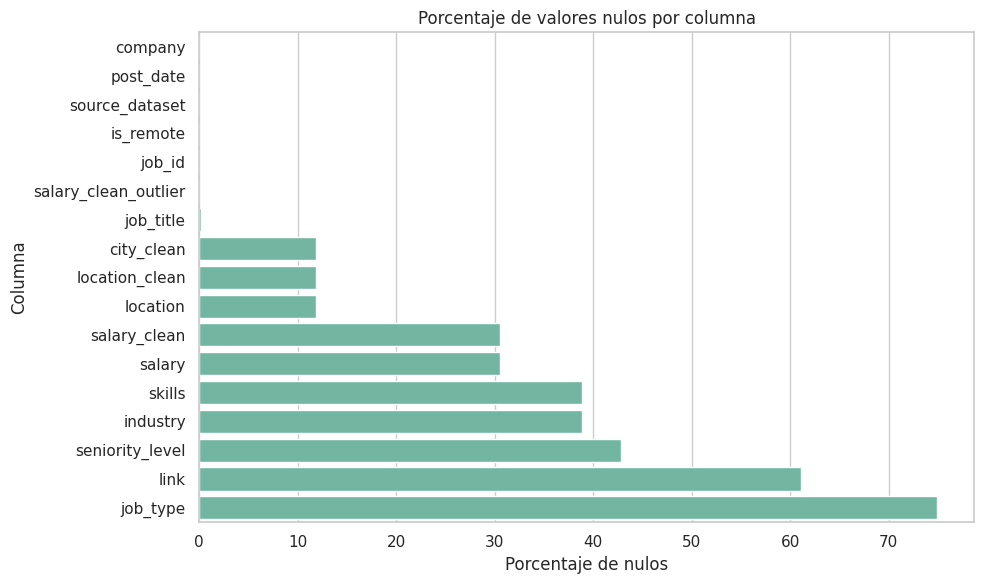

In [79]:
# Graficar porcentaje de nulos / Plot missing-value percentage
plot_data = missing_jobs.sort_values("missing_pct", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x="missing_pct", y="column")
plt.title("Porcentaje de valores nulos por columna")
plt.xlabel("Porcentaje de nulos")
plt.ylabel("Columna")
plt.tight_layout()
plt.show()

## 8. Cobertura por fuente

Se revisa cuántas ofertas aporta cada fuente. Esta comprobación es importante porque una fuente con muchas más filas puede dominar los resultados agregados.

,source_dataset,job_count,job_pct
0,df_jobs,942,61.09
1,df_tecno,600,38.91


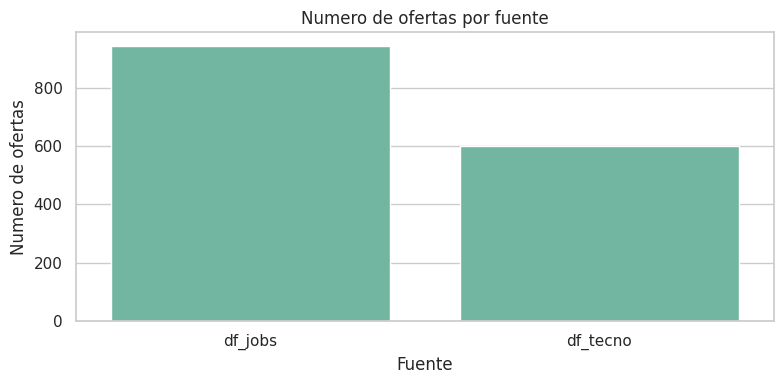

In [80]:
# Distribucion por fuente / Source distribution
source_distribution = (
    jobs_eda["source_dataset"]
    .value_counts(dropna=False)
    .rename_axis("source_dataset")
    .reset_index(name="job_count")
)

source_distribution["job_pct"] = (
    source_distribution["job_count"] / source_distribution["job_count"].sum() * 100
).round(2)

display(source_distribution)

plt.figure(figsize=(8, 4))
sns.barplot(data=source_distribution, x="source_dataset", y="job_count")
plt.title("Numero de ofertas por fuente")
plt.xlabel("Fuente")
plt.ylabel("Numero de ofertas")
plt.tight_layout()
plt.show()

## 9. Análisis de puestos

Se revisan los puestos más frecuentes y se crea una clasificación aproximada por familias de rol. Esta clasificación no sustituye a una taxonomía profesional completa, pero ayuda a leer tendencias generales.

,job_title,count
0,data scientist,856
1,machine learning engineer,78
2,data engineer,4
3,Electromecánico/a,4
4,Project Manager,4
5,Analista Programador/a .NET,3
6,Programador/a Cobol,2
7,Programador/a PLC,2
8,Software Development Engineer,2
9,Programador Java,2


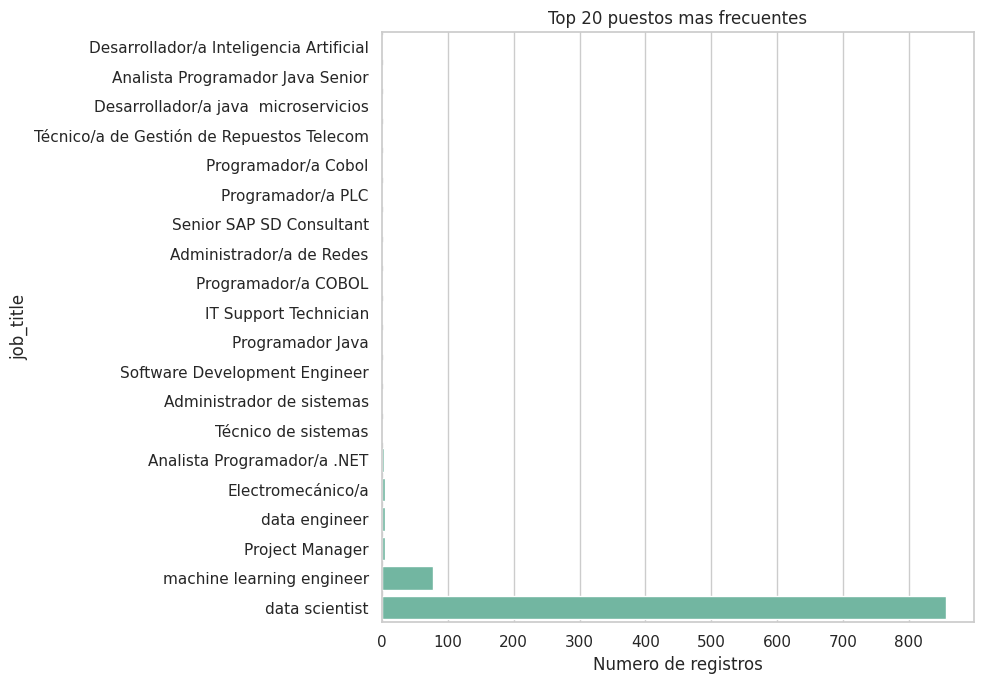

In [81]:
# Puestos mas frecuentes / Most frequent job titles
top_job_titles = show_top_values(jobs_eda, "job_title", top_n=20)
plot_top_values(jobs_eda, "job_title", "Top 20 puestos mas frecuentes", top_n=20, figsize=(10, 7))

,job_family,job_count,job_pct
0,data_science_ai,942,61.09
1,other,228,14.79
2,software_development,203,13.16
3,management_architecture,55,3.57
4,systems_cloud_devops,49,3.18
5,data_analysis_bi,20,1.30
6,cybersecurity,17,1.10
7,data_engineering,16,1.04
8,qa_testing,9,0.58
9,unknown,3,0.19


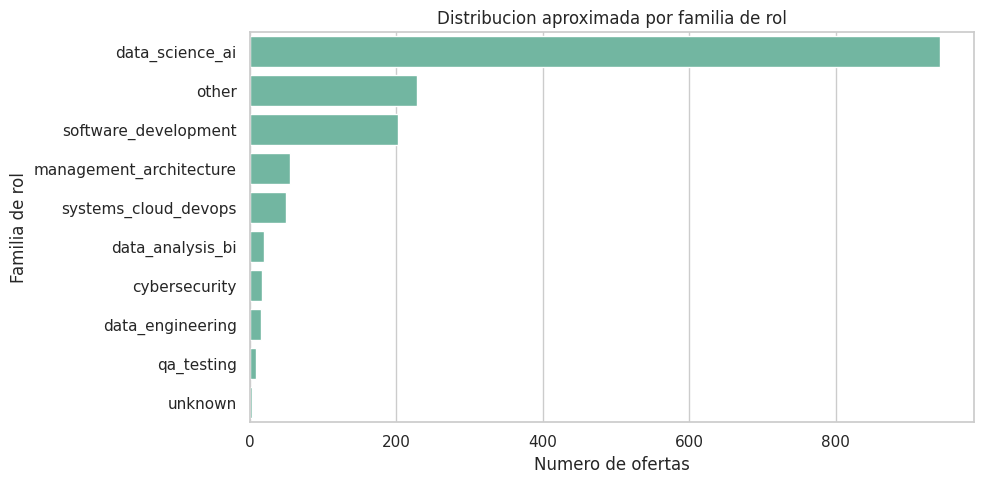

In [82]:
def classify_job_family(job_title):
    """
    ES: Clasifica un puesto en familias generales usando palabras clave.
    EN: Classifies a job title into broad families using keywords.
    """
    title = normalize_text_value(job_title)

    if pd.isna(title):
        return "unknown"

    if any(keyword in title for keyword in ["data scientist", "machine learning", "ml engineer", "ai engineer", "inteligencia artificial"]):
        return "data_science_ai"
    if any(keyword in title for keyword in ["data analyst", "analyst", "business intelligence", "bi ", "power bi", "qlik", "tableau"]):
        return "data_analysis_bi"
    if any(keyword in title for keyword in ["data engineer", "big data", "etl", "analytics engineer"]):
        return "data_engineering"
    if any(keyword in title for keyword in ["developer", "programador", "desarrollador", "software", "frontend", "backend", "fullstack", "java", ".net", "python engineer"]):
        return "software_development"
    if any(keyword in title for keyword in ["qa", "tester", "testing", "quality"]):
        return "qa_testing"
    if any(keyword in title for keyword in ["devops", "sistemas", "system", "cloud", "infrastructure", "network"]):
        return "systems_cloud_devops"
    if any(keyword in title for keyword in ["security", "cyber", "ciberseguridad"]):
        return "cybersecurity"
    if any(keyword in title for keyword in ["lead", "manager", "jefe", "project", "arquitecto", "architect"]):
        return "management_architecture"

    return "other"


# Crear familia de rol para el EDA / Create job family for EDA
jobs_eda["job_family"] = jobs_eda["job_title"].apply(classify_job_family)

job_family_distribution = (
    jobs_eda["job_family"]
    .value_counts()
    .rename_axis("job_family")
    .reset_index(name="job_count")
)

job_family_distribution["job_pct"] = (
    job_family_distribution["job_count"] / job_family_distribution["job_count"].sum() * 100
).round(2)

display(job_family_distribution)

plt.figure(figsize=(10, 5))
sns.barplot(data=job_family_distribution, x="job_count", y="job_family")
plt.title("Distribucion aproximada por familia de rol")
plt.xlabel("Numero de ofertas")
plt.ylabel("Familia de rol")
plt.tight_layout()
plt.show()

## 10. Empresas

Se revisan las empresas con más ofertas publicadas. Si pocas empresas concentran muchas ofertas, las conclusiones pueden reflejar más las necesidades de esas empresas que las del mercado completo.

,company,count
0,Michael Page,66
1,Serem,42
2,Page Personnel,40
3,HAYS,40
4,Baoss,36
5,company_134,30
6,GMV,26
7,Randstad ES,25
8,UST,25
9,company_003,24


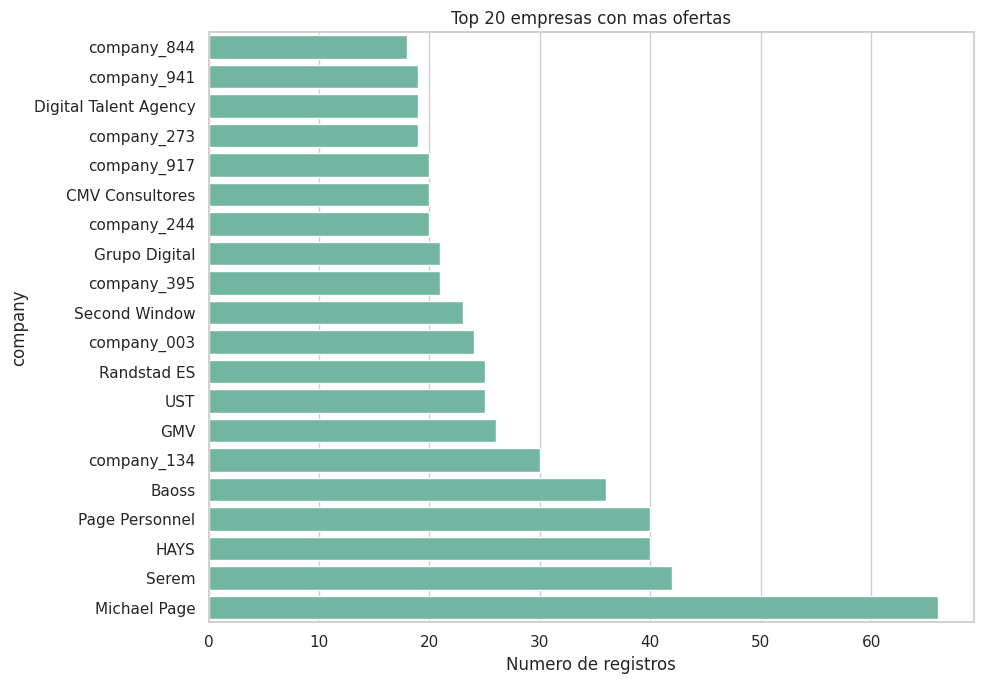

In [83]:
# Empresas mas frecuentes / Most frequent companies
top_companies = show_top_values(jobs_eda, "company", top_n=20)
plot_top_values(jobs_eda, "company", "Top 20 empresas con mas ofertas", top_n=20, figsize=(10, 7))

In [84]:
# Concentracion de ofertas por empresa / Job concentration by company
company_counts = jobs_eda["company"].dropna().value_counts()
company_concentration = pd.DataFrame({
    "metric": ["companies", "top_5_jobs", "top_10_jobs", "top_20_jobs"],
    "value": [
        company_counts.shape[0],
        company_counts.head(5).sum(),
        company_counts.head(10).sum(),
        company_counts.head(20).sum()
    ]
})

company_concentration["pct_of_known_company_jobs"] = [
    np.nan,
    round(company_counts.head(5).sum() / company_counts.sum() * 100, 2),
    round(company_counts.head(10).sum() / company_counts.sum() * 100, 2),
    round(company_counts.head(20).sum() / company_counts.sum() * 100, 2)
]

display(company_concentration)

,metric,value,pct_of_known_company_jobs
0,companies,489,NaN
1,top_5_jobs,224,14.53
2,top_10_jobs,354,22.96
3,top_20_jobs,554,35.93


## 11. Ubicación y modalidad de trabajo

Se analizan ubicaciones limpias, ciudades aproximadas y trabajo remoto. Estas variables proceden de la limpieza extra realizada en `02_cleaning.ipynb`.

,city_clean,count
0,Madrid,242
1,Barcelona,108
2,Remote,79
3,Bengaluru,67
4,New York,50
5,San Francisco,42
6,Mountain View,29
7,United States,23
8,Málaga,22
9,Seattle,19


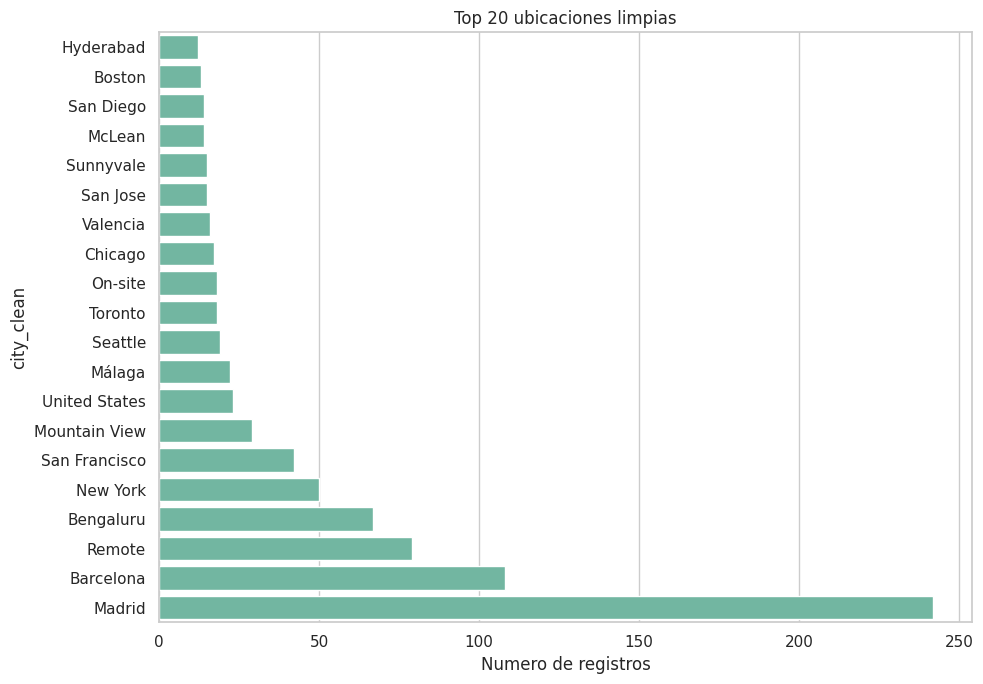

In [85]:
# Ciudades mas frecuentes / Most frequent cities
top_cities = show_top_values(jobs_eda, "city_clean", top_n=20)
plot_top_values(jobs_eda, "city_clean", "Top 20 ubicaciones limpias", top_n=20, figsize=(10, 7))

,is_remote,job_count,job_pct
0,False,1463,94.88
1,True,79,5.12


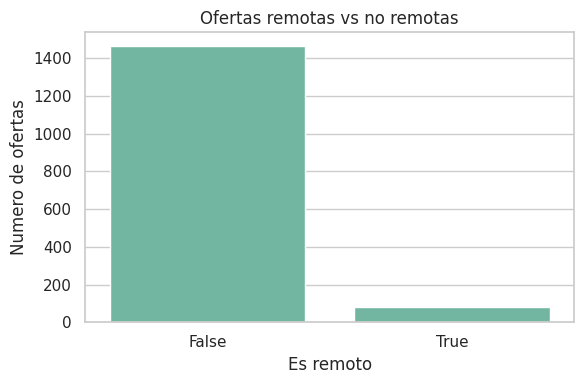

In [86]:
# Distribucion de trabajo remoto / Remote-work distribution
if "is_remote" not in jobs_eda.columns:
    jobs_eda = ensure_location_columns(jobs_eda)

remote_distribution = (
    jobs_eda["is_remote"]
    .astype(bool)
    .value_counts(dropna=False)
    .rename_axis("is_remote")
    .reset_index(name="job_count")
)

remote_distribution["job_pct"] = (
    remote_distribution["job_count"] / remote_distribution["job_count"].sum() * 100
).round(2)

display(remote_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(data=remote_distribution, x="is_remote", y="job_count")
plt.title("Ofertas remotas vs no remotas")
plt.xlabel("Es remoto")
plt.ylabel("Numero de ofertas")
plt.tight_layout()
plt.show()

,work_modality,job_count,job_pct
0,unknown,976,63.29
1,remote,208,13.49
2,hybrid,207,13.42
3,onsite,151,9.79


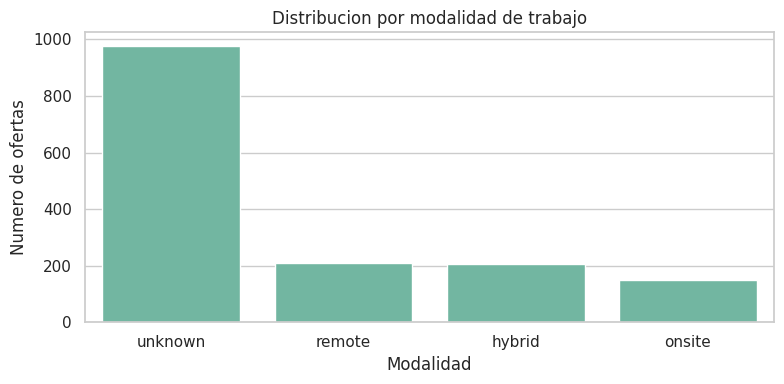

In [87]:
def classify_work_modality(row):
    """
    ES: Clasifica modalidad usando job_type, location e is_remote.
    EN: Classifies work modality using job_type, location and is_remote.
    """
    combined_text = " ".join([
        str(row.get("job_type", "")),
        str(row.get("location", "")),
        str(row.get("location_clean", ""))
    ]).lower()

    is_remote_value = row.get("is_remote", False)
    if isinstance(is_remote_value, str):
        is_remote_value = is_remote_value.strip().lower() in {"true", "1", "yes", "si"}

    if bool(is_remote_value) or "100% remoto" in combined_text or "remote" in combined_text or "remoto" in combined_text:
        return "remote"
    if "hibrido" in combined_text or "hybrid" in combined_text:
        return "hybrid"
    if "presencial" in combined_text or "onsite" in combined_text or "on-site" in combined_text:
        return "onsite"

    return "unknown"


# Clasificar modalidad de trabajo / Classify work modality
jobs_eda["work_modality"] = jobs_eda.apply(classify_work_modality, axis=1)

work_modality_distribution = (
    jobs_eda["work_modality"]
    .value_counts()
    .rename_axis("work_modality")
    .reset_index(name="job_count")
)

work_modality_distribution["job_pct"] = (
    work_modality_distribution["job_count"] / work_modality_distribution["job_count"].sum() * 100
).round(2)

display(work_modality_distribution)

plt.figure(figsize=(8, 4))
sns.barplot(data=work_modality_distribution, x="work_modality", y="job_count")
plt.title("Distribucion por modalidad de trabajo")
plt.xlabel("Modalidad")
plt.ylabel("Numero de ofertas")
plt.tight_layout()
plt.show()

## 12. Seniority e industria

Se revisan las columnas de seniority e industria. Estas variables no están disponibles en todas las fuentes, por lo que se interpretan como información parcial.

,seniority_level,count
0,senior,629
1,lead,116
2,midlevel,112
3,junior,25


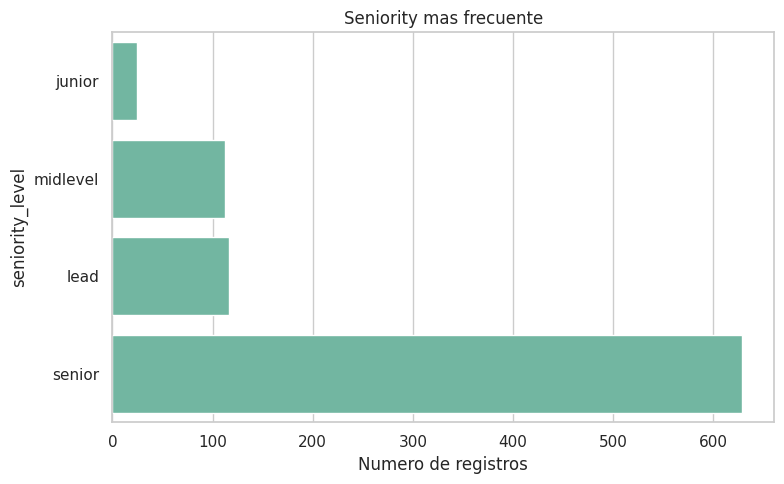

In [88]:
# Seniority mas frecuente / Most frequent seniority levels
show_top_values(jobs_eda, "seniority_level", top_n=15)
plot_top_values(jobs_eda, "seniority_level", "Seniority mas frecuente", top_n=15, figsize=(8, 5))

,industry,count
0,Technology,580
1,Finance,127
2,Retail,110
3,Healthcare,83
4,Education,19
5,Energy,12
6,Manufacturing,7
7,Logistics,4


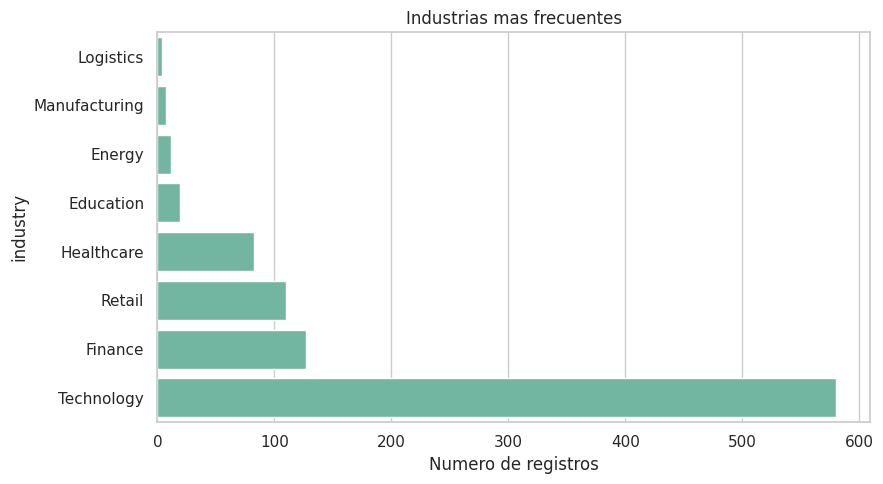

In [89]:
# Industrias mas frecuentes / Most frequent industries
show_top_values(jobs_eda, "industry", top_n=15)
plot_top_values(jobs_eda, "industry", "Industrias mas frecuentes", top_n=15, figsize=(9, 5))

## 13. Salarios

La columna `salary_clean` es una aproximación numérica creada durante el cleaning. No debe interpretarse como salario exacto, pero permite hacer una primera lectura de disponibilidad y distribución.

In [90]:
# Disponibilidad salarial / Salary availability
salary_availability = pd.DataFrame({
    "metric": ["total_jobs", "jobs_with_salary_clean", "jobs_without_salary_clean"],
    "value": [
        len(jobs_eda),
        jobs_eda["salary_clean"].notna().sum(),
        jobs_eda["salary_clean"].isna().sum()
    ]
})

salary_availability["pct"] = (salary_availability["value"] / len(jobs_eda) * 100).round(2)
display(salary_availability)

,metric,value,pct
0,total_jobs,1542,100.00
1,jobs_with_salary_clean,1071,69.46
2,jobs_without_salary_clean,471,30.54


,salary_clean
count,1.071000e+03
mean,1.161210e+05
std,1.282466e+05
min,1.700000e+01
25%,4.143050e+04
50%,1.193995e+05
75%,1.657745e+05
max,2.739979e+06


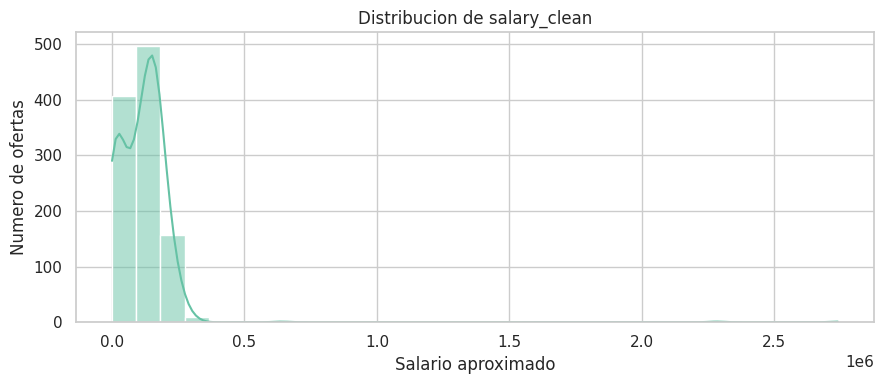

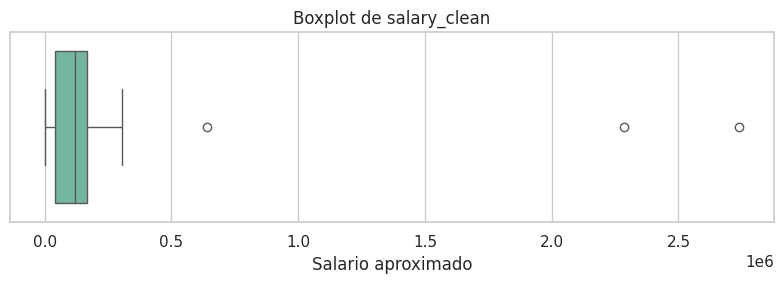

In [91]:
# Estadisticas descriptivas salariales / Salary descriptive statistics
salary_data = jobs_eda["salary_clean"].dropna()

if salary_data.empty:
    print("No hay suficientes datos salariales limpios para analizar.")
else:
    display(salary_data.describe().to_frame(name="salary_clean"))

    plt.figure(figsize=(9, 4))
    sns.histplot(salary_data, bins=30, kde=True)
    plt.title("Distribucion de salary_clean")
    plt.xlabel("Salario aproximado")
    plt.ylabel("Numero de ofertas")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 3))
    sns.boxplot(x=salary_data)
    plt.title("Boxplot de salary_clean")
    plt.xlabel("Salario aproximado")
    plt.tight_layout()
    plt.show()

In [92]:
# Salario por fuente y modalidad / Salary by source and modality
salary_by_source = (
    jobs_eda
    .dropna(subset=["salary_clean"])
    .groupby("source_dataset")
    .agg(
        jobs_with_salary=("job_id", "count"),
        median_salary=("salary_clean", "median"),
        mean_salary=("salary_clean", "mean")
    )
    .round(2)
    .reset_index()
)

display(salary_by_source)

salary_by_modality = (
    jobs_eda
    .dropna(subset=["salary_clean"])
    .groupby("work_modality")
    .agg(
        jobs_with_salary=("job_id", "count"),
        median_salary=("salary_clean", "median"),
        mean_salary=("salary_clean", "mean")
    )
    .round(2)
    .reset_index()
)

display(salary_by_modality)

,source_dataset,jobs_with_salary,median_salary,mean_salary
0,df_jobs,942,134766.0,132017.95
1,df_tecno,129,36.0,36.29


,work_modality,jobs_with_salary,median_salary,mean_salary
0,hybrid,207,132617.5,142310.13
1,onsite,116,142257.0,129423.30
2,remote,117,100469.0,96079.04
3,unknown,631,112114.5,108800.39


## 14. Skills de ofertas

`job_skills_long.csv` permite analizar skills en formato largo: una fila por oferta y skill. Esto facilita rankings y comparaciones con tecnologías de Stack Overflow.

,skill,count
0,python,639
1,machine learning,580
2,sql,441
3,r,343
4,aws,217
5,deep learning,178
6,tensorflow,165
7,spark,161
8,azure,154
9,pytorch,148


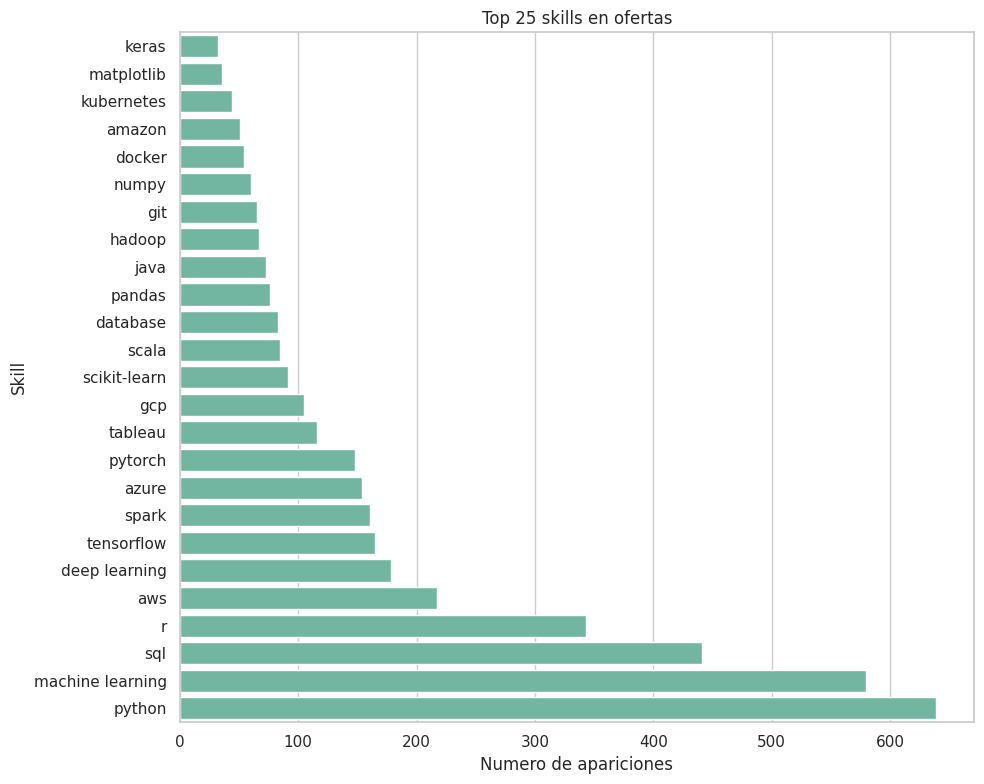

In [93]:
# Skills mas frecuentes en ofertas / Most frequent job skills
top_skills = (
    job_skills_long["skill"]
    .dropna()
    .astype(str)
    .value_counts()
    .head(25)
    .rename_axis("skill")
    .reset_index(name="count")
)

display(top_skills)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_skills.sort_values("count", ascending=True), x="count", y="skill")
plt.title("Top 25 skills en ofertas")
plt.xlabel("Numero de apariciones")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [94]:
# Skills por fuente / Skills by source
skills_by_source = (
    job_skills_long
    .groupby(["source_dataset", "skill"])
    .size()
    .reset_index(name="count")
    .sort_values(["source_dataset", "count"], ascending=[True, False])
)

top_skills_by_source = skills_by_source.groupby("source_dataset").head(10).reset_index(drop=True)
display(top_skills_by_source)

,source_dataset,skill,count
0,df_jobs,python,639
1,df_jobs,machine learning,580
2,df_jobs,sql,441
3,df_jobs,r,343
4,df_jobs,aws,217
5,df_jobs,deep learning,178
6,df_jobs,tensorflow,165
7,df_jobs,spark,161
8,df_jobs,azure,154
9,df_jobs,pytorch,148


## 15. Tecnologías de Stack Overflow

Los rankings de Stack Overflow permiten observar tecnologías usadas (`used`) y tecnologías deseadas (`wanted`). Esta información no representa ofertas de empleo, sino preferencias y experiencia declarada por profesionales.

In [95]:
# Rankings generales de tecnologias / General technology rankings
display(technology_rankings.head(20))

print("Categorias disponibles:")
print(technology_rankings["category"].dropna().unique())

,category,type,technology,count
0,ai_model_tool,used,openAI GPT (chatbot models),13424
1,ai_model_tool,used,Anthropic: Claude Sonnet,7063
2,ai_model_tool,used,Gemini (Flash general purpose models),5823
3,ai_model_tool,used,openAI Reasoning models,5716
4,ai_model_tool,used,openAI Image generating models,4395
5,ai_model_tool,used,Gemini (Pro Reasoning models),4221
6,ai_model_tool,used,DeepSeek (R- Reasoning models),3848
7,ai_model_tool,used,Meta Llama (all models),2941
8,ai_model_tool,used,DeepSeek (V- General purpose models),2363
9,ai_model_tool,used,X Grok models,1839


Categorias disponibles:
['ai_model_tool' 'database' 'development_environment' 'language'
 'platform_cloud' 'web_framework']


,category,type,technology,count
0,ai_model_tool,used,openAI GPT (chatbot models),13424
1,ai_model_tool,used,Anthropic: Claude Sonnet,7063
2,ai_model_tool,used,Gemini (Flash general purpose models),5823
3,ai_model_tool,used,openAI Reasoning models,5716
4,ai_model_tool,used,openAI Image generating models,4395
5,ai_model_tool,used,Gemini (Pro Reasoning models),4221
6,ai_model_tool,used,DeepSeek (R- Reasoning models),3848
7,ai_model_tool,used,Meta Llama (all models),2941
8,ai_model_tool,used,DeepSeek (V- General purpose models),2363
9,ai_model_tool,used,X Grok models,1839


,category,type,technology,count
0,ai_model_tool,wanted,openAI GPT (chatbot models),8328
1,ai_model_tool,wanted,Anthropic: Claude Sonnet,5428
2,ai_model_tool,wanted,openAI Reasoning models,4213
3,ai_model_tool,wanted,Gemini (Flash general purpose models),3865
4,ai_model_tool,wanted,Gemini (Pro Reasoning models),3670
5,ai_model_tool,wanted,openAI Image generating models,3031
6,ai_model_tool,wanted,DeepSeek (R- Reasoning models),2750
7,ai_model_tool,wanted,Meta Llama (all models),2004
8,ai_model_tool,wanted,DeepSeek (V- General purpose models),1832
9,ai_model_tool,wanted,X Grok models,1429


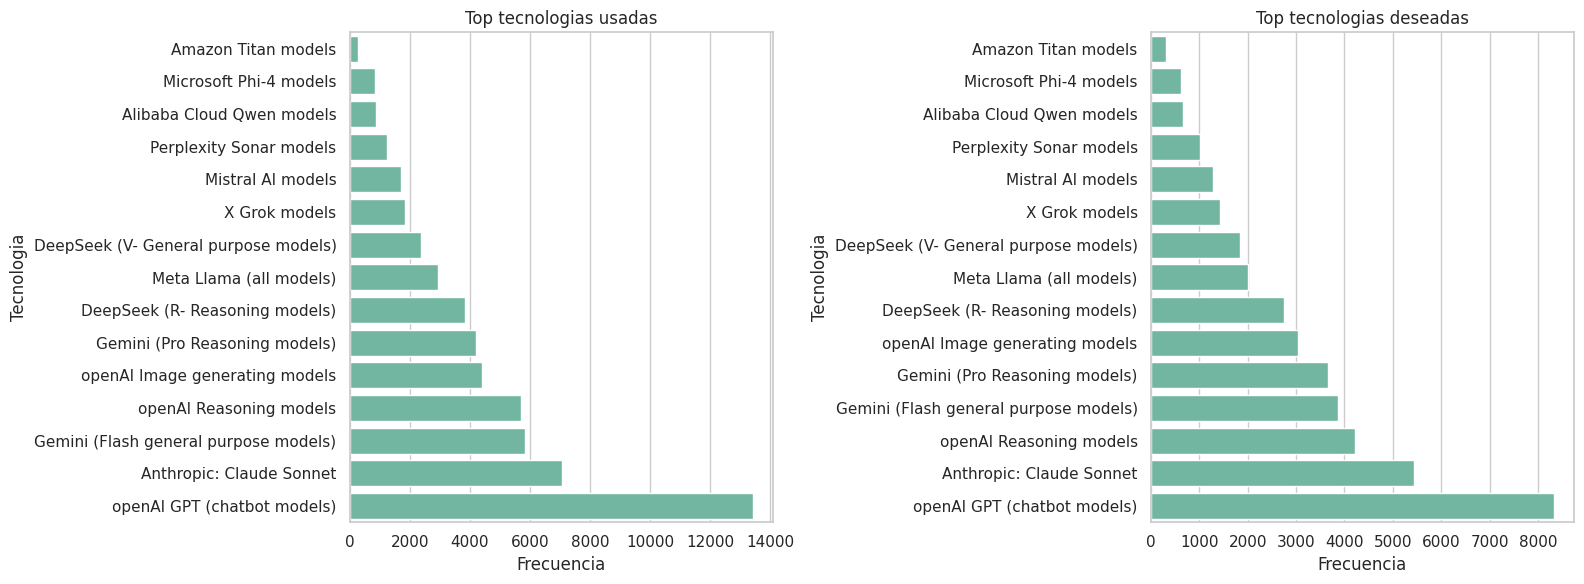

In [96]:
# Top tecnologias usadas y deseadas / Top used and wanted technologies
top_used_technologies = technology_rankings_used.head(15)
top_wanted_technologies = technology_rankings_wanted.head(15)

display(top_used_technologies)
display(top_wanted_technologies)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_used_technologies.sort_values("count", ascending=True),
    x="count",
    y="technology",
    ax=axes[0]
)
axes[0].set_title("Top tecnologias usadas")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Tecnologia")

sns.barplot(
    data=top_wanted_technologies.sort_values("count", ascending=True),
    x="count",
    y="technology",
    ax=axes[1]
)
axes[1].set_title("Top tecnologias deseadas")
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("Tecnologia")

plt.tight_layout()
plt.show()

In [97]:
# Top tecnologias por categoria / Top technologies by category
technology_top_by_category = (
    technology_rankings
    .sort_values(["category", "type", "count"], ascending=[True, True, False])
    .groupby(["category", "type"])
    .head(5)
    .reset_index(drop=True)
)

display(technology_top_by_category)

,category,type,technology,count
0,ai_model_tool,used,openAI GPT (chatbot models),13424
1,ai_model_tool,used,Anthropic: Claude Sonnet,7063
2,ai_model_tool,used,Gemini (Flash general purpose models),5823
3,ai_model_tool,used,openAI Reasoning models,5716
4,ai_model_tool,used,openAI Image generating models,4395
5,ai_model_tool,wanted,openAI GPT (chatbot models),8328
6,ai_model_tool,wanted,Anthropic: Claude Sonnet,5428
7,ai_model_tool,wanted,openAI Reasoning models,4213
8,ai_model_tool,wanted,Gemini (Flash general purpose models),3865
9,ai_model_tool,wanted,Gemini (Pro Reasoning models),3670


## 16. Comparación inicial entre skills y tecnologías

Se realiza una comparación simple entre las skills más frecuentes en ofertas y las tecnologías más frecuentes en Stack Overflow. Esta comparación es aproximada porque las fuentes tienen naturalezas distintas y los nombres no siempre coinciden exactamente.

In [98]:
# Comparacion simple por nombre normalizado / Simple comparison by normalized name
top_job_skill_names = set(top_skills["skill"].apply(normalize_text_value))
top_wanted_technology_names = set(
    technology_rankings_wanted.head(50)["technology"].apply(normalize_text_value)
)
top_used_technology_names = set(
    technology_rankings_used.head(50)["technology"].apply(normalize_text_value)
)

skill_technology_overlap = pd.DataFrame({
    "comparison": [
        "top_job_skills_vs_top_wanted_technologies",
        "top_job_skills_vs_top_used_technologies"
    ],
    "overlap_count": [
        len(top_job_skill_names.intersection(top_wanted_technology_names)),
        len(top_job_skill_names.intersection(top_used_technology_names))
    ],
    "overlap_values": [
        ", ".join(sorted(top_job_skill_names.intersection(top_wanted_technology_names))),
        ", ".join(sorted(top_job_skill_names.intersection(top_used_technology_names)))
    ]
})

display(skill_technology_overlap)

,comparison,overlap_count,overlap_values
0,top_job_skills_vs_top_wanted_technologies,0,
1,top_job_skills_vs_top_used_technologies,0,


## 17. Fechas de publicación

Se revisa la columna `post_date` para entender si las ofertas se concentran en ciertos días o meses. Las fechas proceden de fuentes distintas, por lo que se parsean con cautela.

In [99]:
# Convertir fechas con dayfirst porque TecnoEmpleo usa formato dd/mm/yyyy / Parse dates with dayfirst because TecnoEmpleo uses dd/mm/yyyy
jobs_eda["post_date_parsed"] = pd.to_datetime(jobs_eda["post_date"], errors="coerce", dayfirst=True)

post_date_summary = pd.DataFrame({
    "metric": ["valid_dates", "missing_or_invalid_dates", "min_date", "max_date"],
    "value": [
        jobs_eda["post_date_parsed"].notna().sum(),
        jobs_eda["post_date_parsed"].isna().sum(),
        jobs_eda["post_date_parsed"].min(),
        jobs_eda["post_date_parsed"].max()
    ]
})

display(post_date_summary)

/tmp/ipykernel_2090/911424086.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  jobs_eda["post_date_parsed"] = pd.to_datetime(jobs_eda["post_date"], errors="coerce", dayfirst=True)


,metric,value
0,valid_dates,600
1,missing_or_invalid_dates,942
2,min_date,2026-04-01 00:00:00
3,max_date,2026-04-04 00:00:00


,post_month,source_dataset,job_count
0,2026-04,df_tecno,600


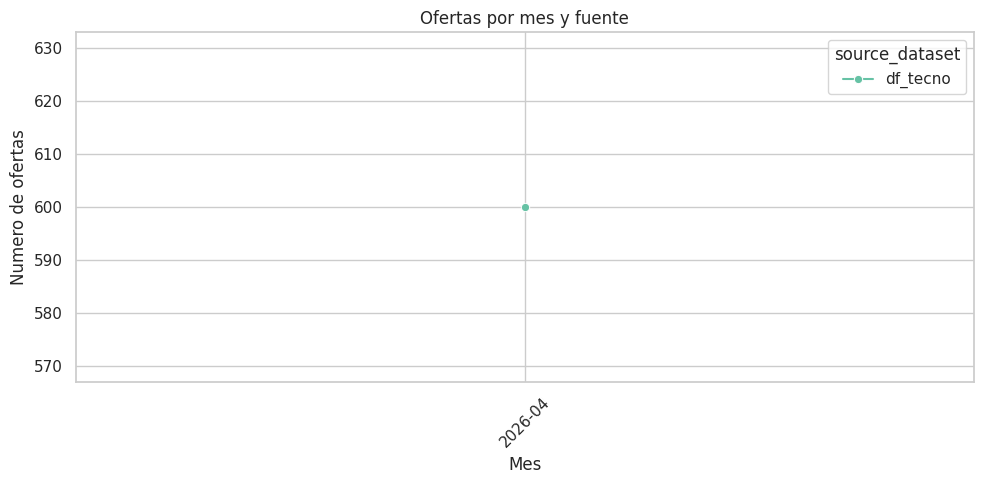

In [100]:
# Ofertas por mes / Job postings by month
jobs_eda["post_month"] = jobs_eda["post_date_parsed"].dt.to_period("M").astype(str)
monthly_jobs = (
    jobs_eda[jobs_eda["post_date_parsed"].notna()]
    .groupby(["post_month", "source_dataset"])
    .size()
    .reset_index(name="job_count")
)

display(monthly_jobs.head(20))

if monthly_jobs.empty:
    print("No hay fechas validas suficientes para graficar.")
else:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly_jobs, x="post_month", y="job_count", hue="source_dataset", marker="o")
    plt.title("Ofertas por mes y fuente")
    plt.xlabel("Mes")
    plt.ylabel("Numero de ofertas")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 18. Limitaciones detectadas

Durante el EDA se deben tener en cuenta estas limitaciones:

- Las fuentes no representan exactamente el mismo universo: unas son ofertas de empleo y otra procede de respuestas de Stack Overflow.
- Algunas columnas tienen muchos valores nulos, especialmente salario, skills, industria y seniority en ciertas fuentes.
- `salary_clean` es una aproximación numérica, no un salario exacto.
- La clasificación de familias de rol y modalidad se basa en reglas simples de texto.
- La comparación entre skills de ofertas y tecnologías de Stack Overflow es orientativa.

## 19. Conclusiones iniciales

La siguiente celda resume de forma automática algunos hallazgos básicos del EDA. Estas conclusiones sirven como punto de partida para el notebook de visualizaciones y para el análisis final.

In [101]:
# Generar resumen automatico de conclusiones / Generate automatic summary of findings
main_source = source_distribution.sort_values("job_count", ascending=False).iloc[0]
main_family = job_family_distribution.sort_values("job_count", ascending=False).iloc[0]
main_city = top_cities.iloc[0] if not top_cities.empty else None
main_modality = work_modality_distribution.sort_values("job_count", ascending=False).iloc[0]
salary_available_pct = salary_availability.loc[
    salary_availability["metric"] == "jobs_with_salary_clean",
    "pct"
].iloc[0]
main_skill = top_skills.iloc[0] if not top_skills.empty else None
main_wanted_technology = technology_rankings_wanted.iloc[0] if not technology_rankings_wanted.empty else None

print("Conclusiones iniciales del EDA")
print("-" * 35)
print(f"1. El dataset unificado original contiene {len(jobs_all_clean)} ofertas y {jobs_all_clean.shape[1]} columnas.")
print(f"2. La copia de trabajo del EDA contiene {jobs_eda.shape[1]} columnas tras crear variables auxiliares.")
print(f"3. La fuente con mas ofertas es {main_source['source_dataset']} con {main_source['job_count']} registros ({main_source['job_pct']}%).")
print(f"4. La familia de rol mas frecuente es {main_family['job_family']} con {main_family['job_count']} ofertas ({main_family['job_pct']}%).")

if main_city is not None:
    print(f"5. La ubicacion limpia mas frecuente es {main_city['city_clean']} con {main_city['count']} ofertas.")
else:
    print("5. No hay ubicaciones limpias suficientes para destacar una ciudad principal.")

print(f"6. La modalidad mas frecuente es {main_modality['work_modality']} con {main_modality['job_count']} ofertas ({main_modality['job_pct']}%).")
print(f"7. El porcentaje de ofertas con salary_clean disponible es {salary_available_pct}%.")

if main_skill is not None:
    print(f"8. La skill mas frecuente en ofertas es {main_skill['skill']} con {main_skill['count']} apariciones.")
else:
    print("8. No hay skills suficientes para destacar una skill principal.")

if main_wanted_technology is not None:
    print(f"9. La tecnologia mas deseada en Stack Overflow es {main_wanted_technology['technology']} dentro de {main_wanted_technology['category']}.")
else:
    print("9. No hay ranking de tecnologias deseadas disponible.")

Conclusiones iniciales del EDA
-----------------------------------
1. El dataset unificado original contiene 1542 ofertas y 17 columnas.
2. La copia de trabajo del EDA contiene 21 columnas tras crear variables auxiliares.
3. La fuente con mas ofertas es df_jobs con 942 registros (61.09%).
4. La familia de rol mas frecuente es data_science_ai con 942 ofertas (61.09%).
5. La ubicacion limpia mas frecuente es Madrid con 242 ofertas.
6. La modalidad mas frecuente es unknown con 976 ofertas (63.29%).
7. El porcentaje de ofertas con salary_clean disponible es 69.46%.
8. La skill mas frecuente en ofertas es python con 639 apariciones.
9. La tecnologia mas deseada en Stack Overflow es openAI GPT (chatbot models) dentro de ai_model_tool.


## 20. Exportaci?n de datasets post-EDA

Se guardan los datasets resultantes del EDA en `data/eda/` para que `04-visualizations.ipynb` consuma exactamente la versi?n validada/enriquecida por este notebook.


In [102]:
# Exportar datasets post-EDA / Export post-EDA datasets
DATA_EDA = PROJECT_ROOT / "data" / "eda"
DATA_EDA.mkdir(parents=True, exist_ok=True)

jobs_eda_export = jobs_eda.copy()
if "post_date_parsed" in jobs_eda_export.columns:
    jobs_eda_export["post_date_parsed"] = jobs_eda_export["post_date_parsed"].astype("string")

eda_exports = {
    "jobs_eda.csv": jobs_eda_export,
    "technology_rankings_eda.csv": technology_rankings,
    "technology_rankings_used_eda.csv": technology_rankings_used,
    "technology_rankings_wanted_eda.csv": technology_rankings_wanted,
    "cleaning_validation_summary_eda.csv": validation_summary_eda,
    "skill_technology_overlap_eda.csv": skill_technology_overlap,
}

export_rows = []
for filename, dataframe in eda_exports.items():
    output_path = DATA_EDA / filename
    dataframe.to_csv(output_path, index=False, encoding="utf-8")
    export_rows.append({
        "dataset": filename,
        "rows": len(dataframe),
        "columns": dataframe.shape[1],
        "path": str(output_path),
    })

eda_export_summary = pd.DataFrame(export_rows)
display(eda_export_summary)
print(f"Datasets post-EDA exportados en: {DATA_EDA}")


,dataset,rows,columns,path
0,jobs_eda.csv,1542,21,/content/data/eda/jobs_eda.csv
1,technology_rankings_eda.csv,372,4,/content/data/eda/technology_rankings_eda.csv
2,technology_rankings_used_eda.csv,186,4,/content/data/eda/technology_rankings_used_eda...
3,technology_rankings_wanted_eda.csv,186,4,/content/data/eda/technology_rankings_wanted_e...
4,cleaning_validation_summary_eda.csv,11,3,/content/data/eda/cleaning_validation_summary_...
5,skill_technology_overlap_eda.csv,2,3,/content/data/eda/skill_technology_overlap_eda...


Datasets post-EDA exportados en: /content/data/eda


## 20. Próximos pasos

A partir de este EDA, el siguiente paso natural es construir visualizaciones más cuidadas en `04_visualizations.ipynb`, priorizando:

- Distribución de ofertas por fuente.
- Roles y familias de rol más frecuentes.
- Ubicaciones y modalidad de trabajo.
- Disponibilidad y distribución salarial.
- Skills más demandadas.
- Tecnologías usadas y deseadas según Stack Overflow.

Estas visualizaciones deberían apoyarse en las columnas ya unificadas durante el cleaning para mantener consistencia en todo el proyecto.

---
# 📊 MÓDULO 04 — Visualización del Mercado Laboral
---

---
<a id='módulo-04'></a>

# 📊 MÓDULO 04 — Visualización del Mercado Laboral (v4.0)

> **Versión corregida:** sin datos sintéticos, conectado al pipeline real,
> con heatmaps legibles, gráfico de salario por rol corregido,
> y nuevo heatmap de co-ocurrencia de skills.


# 📊 04 — Análisis y Visualización del Mercado Laboral Tech en España
**DataTalent Solutions S.L. · v4.0**  
**Fuente:** datos reales generados por `02_cleaning.ipynb` y `03_eda.ipynb`

---

| Bloque | Contenido |
|--------|-----------|
| 0 | Configuración y carga de datos del pipeline |
| 1 | Distribución y volumen de vacantes |
| 2 | Análisis retributivo y salarial |
| 3 | Mapas de calor y correlaciones (incl. co-ocurrencia de skills) |
| 4 | Stack tecnológico y brecha Used vs Wanted |
| 5 | Análisis estadístico avanzado |
| 6 | Visualizaciones interactivas (Plotly) |
| 7 | Resumen ejecutivo y KPIs |

> **Requisito:** ejecutar primero `02_cleaning.ipynb` y `03_eda.ipynb`.  
> Archivos necesarios en `data/clean/` y `data/eda/`.


## ⚙️ Bloque 0 — Configuración e importaciones

In [103]:
# Instalación de dependencias (Google Colab)
import subprocess, sys

for pkg, imp in [("squarify", "squarify"), ("statsmodels", "statsmodels"),
                  ("plotly", "plotly"), ("kaleido", "kaleido")]:
    try:
        __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✅ Dependencias verificadas.")


✅ Dependencias verificadas.


In [104]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from IPython.display import display

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    sm = None; HAS_STATSMODELS = False

try:
    import squarify
    HAS_SQUARIFY = True
except ImportError:
    HAS_SQUARIFY = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# ── Rutas del proyecto ──
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_CLEAN = PROJECT_ROOT / "data" / "clean"
DATA_EDA   = PROJECT_ROOT / "data" / "eda"
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

# ── Paleta corporativa ──
PAL = {
    "primary":   "#1A365D",
    "secondary": "#2B6CB0",
    "accent":    "#4299E1",
    "warm":      "#ED8936",
    "success":   "#48BB78",
    "light":     "#EBF8FF",
}
CMAP_MAIN = LinearSegmentedColormap.from_list("dt", [PAL["light"], PAL["secondary"], PAL["primary"]])

sns.set_theme(style="whitegrid", palette=list(PAL.values()))
plt.rcParams.update({
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 14,
    "axes.titleweight": "bold", "figure.titlesize": 17,
    "figure.titleweight": "bold", "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#FAFAFA",
})

print("✅ Entorno configurado.")
print(f"📁 Raíz: {PROJECT_ROOT}")
print(f"📂 data/clean: {DATA_CLEAN}  |  data/eda: {DATA_EDA}")
print(f"🖼️  images: {IMAGES_DIR}")


✅ Entorno configurado.
📁 Raíz: /content
📂 data/clean: /content/data/clean  |  data/eda: /content/data/eda
🖼️  images: /content/images


### 📥 Carga de datos reales

Todos los datos provienen del pipeline `02_cleaning.ipynb` → `03_eda.ipynb`.  
**No se generan datos sintéticos.** Si falta algún archivo, la celda muestra el error exacto y qué notebook hay que ejecutar primero.

| Archivo | Origen | Descripción |
|---------|--------|-------------|
| `jobs_eda.csv` | `data/eda/` | Dataset principal post-EDA (preferido) |
| `jobs_all_clean.csv` | `data/clean/` | Dataset unificado post-cleaning (fallback) |
| `technology_rankings_used_eda.csv` / `_used.csv` | eda / clean | Rankings Stack Overflow usadas |
| `technology_rankings_wanted_eda.csv` / `_wanted.csv` | eda / clean | Rankings Stack Overflow demandadas |
| `job_skills_long.csv` | `data/clean/` | Skills en formato largo (co-ocurrencia) |


In [105]:
# ─────────────────────────────────────────────────────────────────
# CARGA DE DATOS REALES — sin datos sintéticos
# ─────────────────────────────────────────────────────────────────

def load_first(candidates, label):
    for p in candidates:
        if Path(p).exists():
            df = pd.read_csv(p)
            print(f"  ✅ {label:45s} ← {Path(p).name}  ({df.shape[0]:,} filas × {df.shape[1]} cols)")
            return df, Path(p)
    lines = "\n  ".join(str(p) for p in candidates)
    raise FileNotFoundError(
        f"\n❌ No se encontró '{label}'.\n  Buscado en:\n  {lines}"
        "\n\n👉 Ejecuta primero 02_cleaning.ipynb (y opcionalmente 03_eda.ipynb)."
    )

print("📂 Cargando archivos del pipeline...")

df, JOBS_PATH = load_first(
    [DATA_EDA / "jobs_eda.csv", DATA_CLEAN / "jobs_all_clean.csv"],
    "Dataset principal de ofertas"
)
POST_EDA = (JOBS_PATH.parent == DATA_EDA)

df_used, _ = load_first(
    [DATA_EDA / "technology_rankings_used_eda.csv", DATA_CLEAN / "technology_rankings_used.csv"],
    "Rankings tecnologías usadas (Stack Overflow)"
)
df_wanted, _ = load_first(
    [DATA_EDA / "technology_rankings_wanted_eda.csv", DATA_CLEAN / "technology_rankings_wanted.csv"],
    "Rankings tecnologías demandadas (Stack Overflow)"
)

try:
    df_skills, _ = load_first(
        [DATA_EDA / "job_skills_long_eda.csv", DATA_CLEAN / "job_skills_long.csv"],
        "Skills en formato largo"
    )
    HAS_SKILLS = True
except FileNotFoundError as e:
    print(f"  ⚠️  {e}\n     El heatmap de co-ocurrencia no estará disponible.")
    df_skills = None; HAS_SKILLS = False

# ── Normalización de columnas clave ──
# work_modality: generada en nb03; fallback desde is_remote / job_type
if "work_modality" not in df.columns:
    def _modality(row):
        txt = " ".join([str(row.get("job_type", "")),
                        str(row.get("location", "")),
                        str(row.get("location_clean", ""))]).lower()
        ir = str(row.get("is_remote", "")).strip().lower() in {"true","1","yes","si"}
        if ir or "remoto" in txt or "remote" in txt or "100%" in txt: return "remote"
        if "hibrido" in txt or "hybrid" in txt: return "hybrid"
        if "presencial" in txt or "onsite" in txt: return "onsite"
        return "unknown"
    df["work_modality"] = df.apply(_modality, axis=1)
    print("  ℹ️  Columna work_modality reconstruida desde job_type/location.")

# city_clean: si no existe, extraer desde location
if "city_clean" not in df.columns and "location" in df.columns:
    df["city_clean"] = df["location"].astype(str).str.extract(r"^([^,\(]+)")[0].str.strip()
    print("  ℹ️  Columna city_clean extraída desde location.")

# Columna de id para conteos
ID_COL = "job_id" if "job_id" in df.columns else df.columns[0]

# Dataset salarial sin outliers
SAL_COL = "salary_clean" if "salary_clean" in df.columns else "salary"
OTL_COL = "salary_clean_outlier" if "salary_clean_outlier" in df.columns else None

mask_sal = df[SAL_COL].notna()
if OTL_COL:
    mask_sal = mask_sal & ~df[OTL_COL].astype(bool).fillna(False)
df_sal = df[mask_sal].copy()

print(f"\n📊 Dataset total: {len(df):,} ofertas | Con salario (sin outliers): {len(df_sal):,}")
print(f"   Columnas disponibles: {df.columns.tolist()}")
print(f"   Fuente: {'post-EDA (data/eda/)' if POST_EDA else 'post-cleaning (data/clean/)'}")


📂 Cargando archivos del pipeline...
  ✅ Dataset principal de ofertas                  ← jobs_eda.csv  (1,542 filas × 21 cols)
  ✅ Rankings tecnologías usadas (Stack Overflow)  ← technology_rankings_used_eda.csv  (186 filas × 4 cols)
  ✅ Rankings tecnologías demandadas (Stack Overflow) ← technology_rankings_wanted_eda.csv  (186 filas × 4 cols)
  ✅ Skills en formato largo                       ← job_skills_long.csv  (4,176 filas × 4 cols)

📊 Dataset total: 1,542 ofertas | Con salario (sin outliers): 1,068
   Columnas disponibles: ['job_id', 'job_title', 'company', 'location', 'salary', 'job_type', 'post_date', 'link', 'skills', 'industry', 'seniority_level', 'source_dataset', 'salary_clean', 'location_clean', 'city_clean', 'is_remote', 'salary_clean_outlier', 'job_family', 'work_modality', 'post_date_parsed', 'post_month']
   Fuente: post-EDA (data/eda/)


## 📍 Bloque 1 — Distribución y Volumen de Vacantes

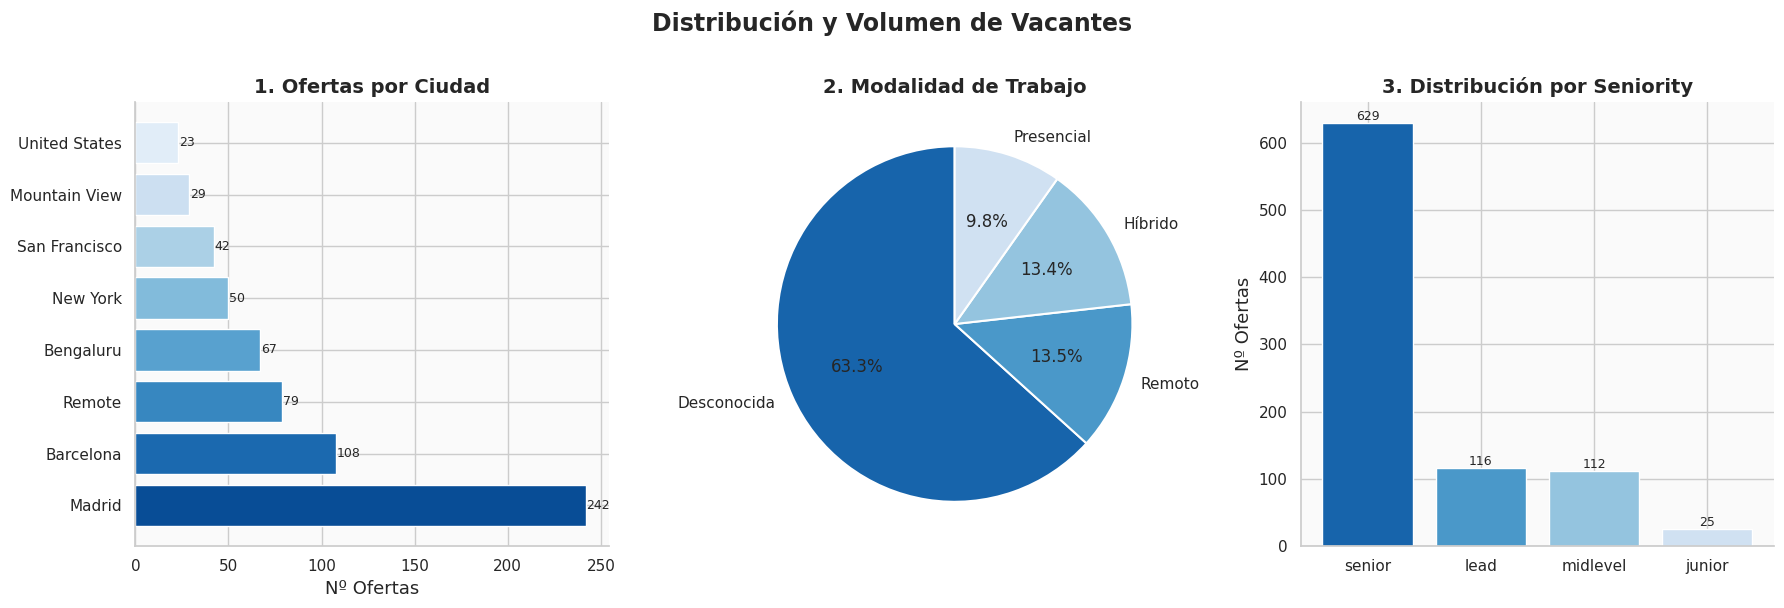

✅ Gráficos 1-3 generados.


In [106]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Distribución y Volumen de Vacantes", y=1.01)

# G1: Ofertas por ciudad
if "city_clean" in df.columns:
    city_vc = df["city_clean"].value_counts().head(8)
    colors = sns.color_palette("Blues_r", len(city_vc))
    bars = axes[0].barh(city_vc.index, city_vc.values, color=colors, edgecolor="white")
    axes[0].set_title("1. Ofertas por Ciudad")
    axes[0].set_xlabel("Nº Ofertas")
    for b, v in zip(bars, city_vc.values):
        axes[0].text(b.get_width() + .3, b.get_y() + b.get_height()/2,
                     str(v), va="center", fontsize=9)
else:
    axes[0].text(0.5, 0.5, "Ciudad no disponible", ha="center", va="center",
                 transform=axes[0].transAxes, fontsize=12); axes[0].axis("off")

# G2: Modalidad de trabajo
mod_vc = df["work_modality"].value_counts()
label_map = {"remote": "Remoto", "hybrid": "Híbrido", "onsite": "Presencial", "unknown": "Desconocida"}
mod_vc.index = mod_vc.index.map(lambda x: label_map.get(x, x))
colors2 = sns.color_palette("Blues_r", len(mod_vc))
axes[1].pie(mod_vc.values, labels=mod_vc.index, autopct="%1.1f%%",
            colors=colors2, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("2. Modalidad de Trabajo")

# G3: Seniority
if "seniority_level" in df.columns and df["seniority_level"].notna().any():
    sen_vc = df["seniority_level"].value_counts()
    axes[2].bar(sen_vc.index, sen_vc.values,
                color=sns.color_palette("Blues_r", len(sen_vc)), edgecolor="white")
    axes[2].set_title("3. Distribución por Seniority")
    axes[2].set_ylabel("Nº Ofertas")
    for b, v in zip(axes[2].patches, sen_vc.values):
        axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + .3,
                     str(v), ha="center", va="bottom", fontsize=9)
else:
    axes[2].text(0.5, 0.5, "Seniority no disponible", ha="center", va="center",
                 transform=axes[2].transAxes, fontsize=12); axes[2].axis("off")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "01_distribucion_volumen.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 1-3 generados.")


## 💶 Bloque 2 — Análisis Retributivo y Salarial

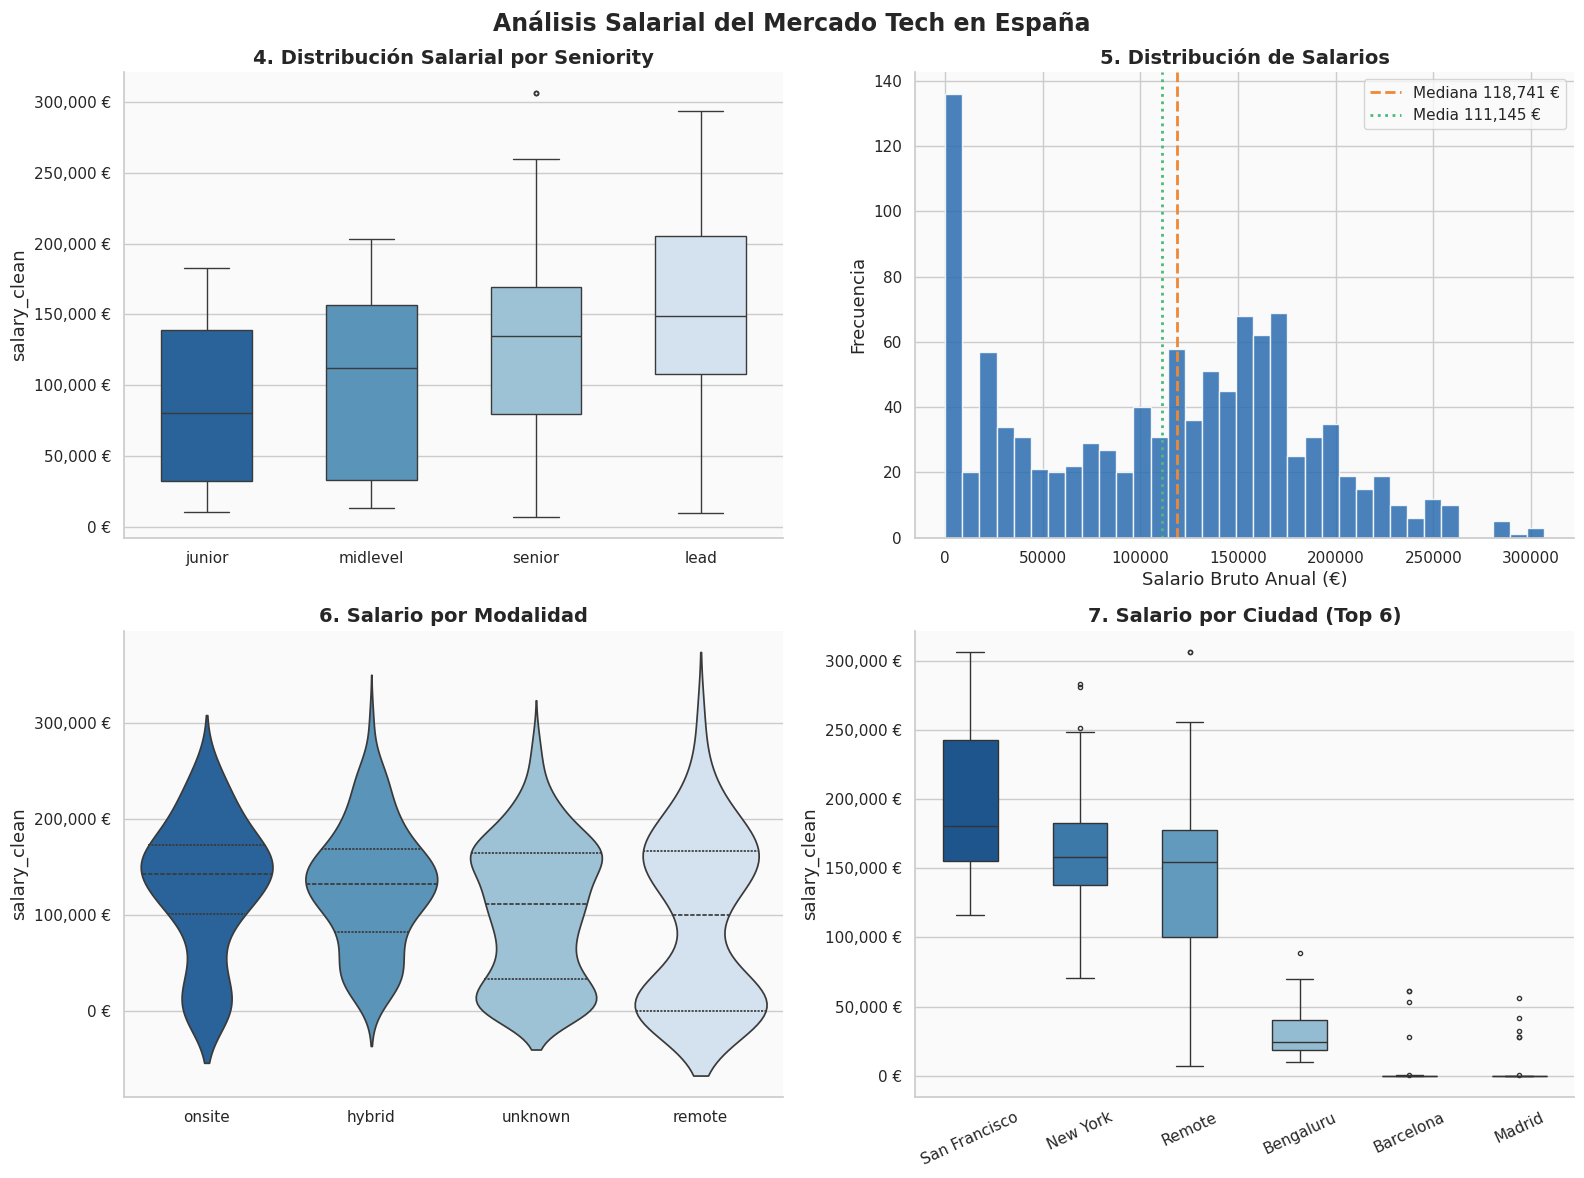

✅ Gráficos 4-7 generados.


In [107]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Análisis Salarial del Mercado Tech en España")

fmt_euro = mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €")

# G4: Boxplot por seniority
if "seniority_level" in df_sal.columns and df_sal["seniority_level"].notna().any():
    order_s = df_sal.groupby("seniority_level")[SAL_COL].median().sort_values().index.tolist()
    sns.boxplot(x="seniority_level", y=SAL_COL, data=df_sal, order=order_s,
                palette="Blues_r", width=0.55, fliersize=3, ax=axes[0,0])
    axes[0,0].yaxis.set_major_formatter(fmt_euro)
    axes[0,0].set_title("4. Distribución Salarial por Seniority")
    axes[0,0].set_xlabel("")
else:
    axes[0,0].text(0.5, 0.5, "Seniority no disponible", ha="center", va="center",
                   transform=axes[0,0].transAxes); axes[0,0].axis("off")

# G5: Histograma
axes[0,1].hist(df_sal[SAL_COL], bins=35, color=PAL["secondary"], edgecolor="white", alpha=0.85)
axes[0,1].axvline(df_sal[SAL_COL].median(), color=PAL["warm"], ls="--", lw=2,
                  label=f"Mediana {df_sal[SAL_COL].median():,.0f} €")
axes[0,1].axvline(df_sal[SAL_COL].mean(), color=PAL["success"], ls=":", lw=2,
                  label=f"Media {df_sal[SAL_COL].mean():,.0f} €")
axes[0,1].set_title("5. Distribución de Salarios")
axes[0,1].set_xlabel("Salario Bruto Anual (€)")
axes[0,1].set_ylabel("Frecuencia")
axes[0,1].legend()

# G6: Violín por modalidad
mod_vc6 = df_sal["work_modality"].value_counts()
valid_mods = mod_vc6[mod_vc6 >= 5].index.tolist()
df_sal6 = df_sal[df_sal["work_modality"].isin(valid_mods)].copy()
if len(valid_mods) >= 2:
    order_m = df_sal6.groupby("work_modality")[SAL_COL].median().sort_values(ascending=False).index.tolist()
    sns.violinplot(x="work_modality", y=SAL_COL, data=df_sal6, order=order_m,
                   palette="Blues_r", inner="quartile", ax=axes[1,0])
    axes[1,0].yaxis.set_major_formatter(fmt_euro)
    axes[1,0].set_title("6. Salario por Modalidad")
    axes[1,0].set_xlabel("")
else:
    axes[1,0].text(0.5, 0.5, "Datos insuficientes por modalidad", ha="center", va="center",
                   transform=axes[1,0].transAxes); axes[1,0].axis("off")

# G7: Boxplot por ciudad (Top 6)
if "city_clean" in df_sal.columns and df_sal["city_clean"].notna().any():
    top6_cities = df_sal["city_clean"].value_counts().head(6).index
    df_c = df_sal[df_sal["city_clean"].isin(top6_cities)]
    order_c = df_c.groupby("city_clean")[SAL_COL].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(x="city_clean", y=SAL_COL, data=df_c, order=order_c,
                palette="Blues_r", width=0.5, fliersize=3, ax=axes[1,1])
    axes[1,1].yaxis.set_major_formatter(fmt_euro)
    axes[1,1].set_title("7. Salario por Ciudad (Top 6)")
    axes[1,1].set_xlabel("")
    axes[1,1].tick_params(axis="x", rotation=25)
else:
    axes[1,1].text(0.5, 0.5, "Ciudad no disponible", ha="center", va="center",
                   transform=axes[1,1].transAxes); axes[1,1].axis("off")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "02_analisis_salarial.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 4-7 generados.")


### 📌 Gráfico 8 — Distribución Salarial por Rol (corregida)

> **Correcciones aplicadas:**  
> - Se toman solo los **Top 15 roles** con más de 10 registros salariales.  
> - Títulos truncados a 35 caracteres para evitar solapamiento.  
> - Separación entre boxplot y stripplot; tamaño de figura aumentado.  
> - Formato de eje X en euros con separador de miles.


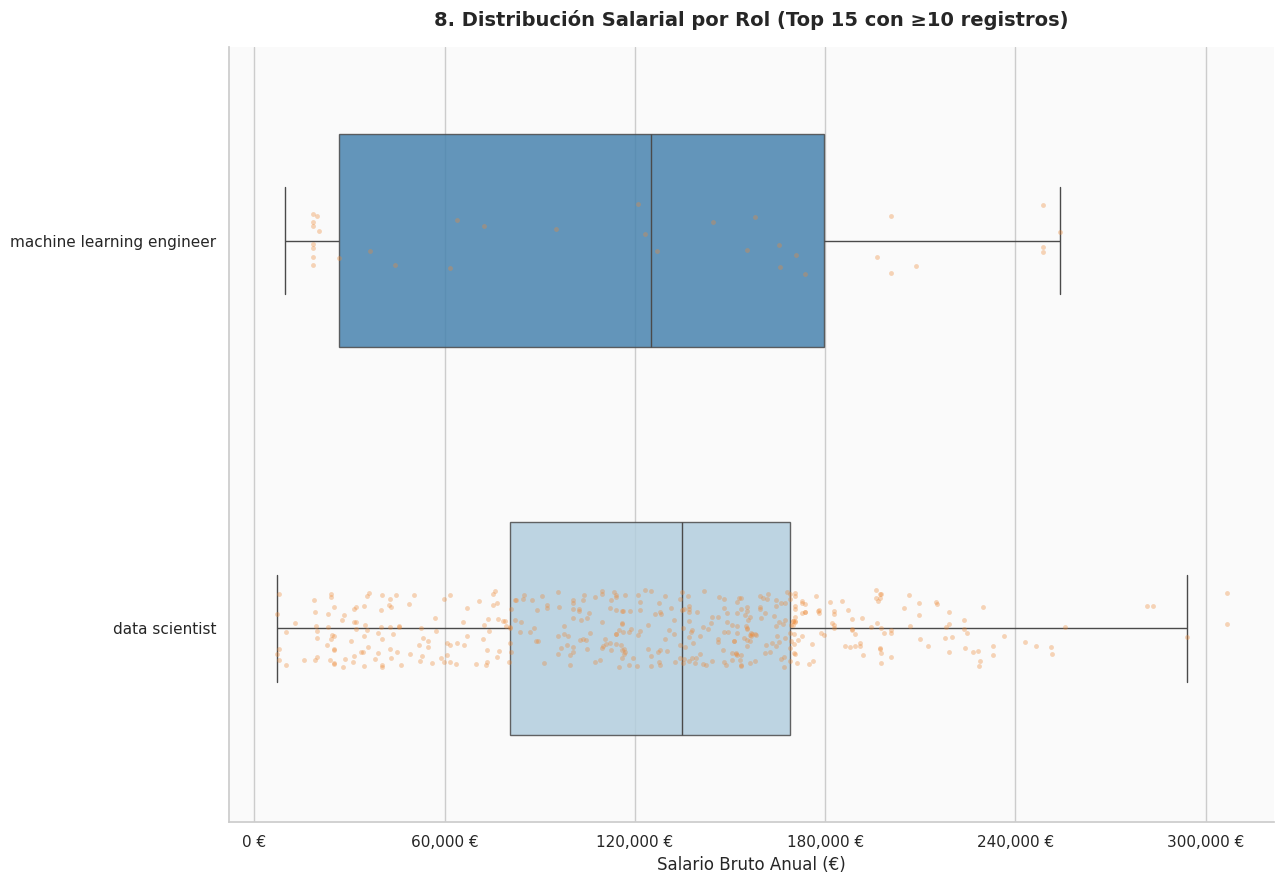

✅ Gráfico 8 generado (2 roles, 931 registros).


In [108]:
# G8: Distribución salarial por rol — VERSIÓN CORREGIDA
if "job_title" in df_sal.columns and df_sal["job_title"].notna().any():

    # 1. Filtrar roles con al menos 10 registros salariales
    role_counts = df_sal["job_title"].value_counts()
    valid_roles = role_counts[role_counts >= 10].index
    df_r = df_sal[df_sal["job_title"].isin(valid_roles)].copy()

    # 2. Seleccionar Top 15 por mediana salarial (más interpretable que alfabético)
    top15 = (
        df_r.groupby("job_title")[SAL_COL]
        .median()
        .sort_values(ascending=True)
        .tail(15)
        .index.tolist()
    )
    df_r = df_r[df_r["job_title"].isin(top15)].copy()

    # 3. Truncar etiquetas largas
    MAX_CHARS = 35
    df_r["job_title_short"] = df_r["job_title"].str[:MAX_CHARS].where(
        df_r["job_title"].str.len() <= MAX_CHARS,
        df_r["job_title"].str[:MAX_CHARS - 1] + "…"
    )
    top15_short = [df_r[df_r["job_title"] == t]["job_title_short"].iloc[0] for t in top15]

    # 4. Figura amplia y márgenes generosos
    fig, ax = plt.subplots(figsize=(13, 9))

    # Boxplot base (sin outliers visibles — los muestra el strip)
    sns.boxplot(
        x=SAL_COL, y="job_title_short", data=df_r,
        order=top15_short, palette="Blues_r", width=0.55,
        flierprops=dict(marker="", markersize=0),   # ocultar outliers del box
        boxprops=dict(alpha=0.85),
        ax=ax
    )

    # Stripplot encima para ver distribución real de puntos
    sns.stripplot(
        x=SAL_COL, y="job_title_short",
        data=df_r.sample(min(500, len(df_r)), random_state=42),
        order=top15_short,
        color=PAL["warm"], alpha=0.35, jitter=True, size=3.5, ax=ax
    )

    ax.set_title("8. Distribución Salarial por Rol (Top 15 con ≥10 registros)",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Salario Bruto Anual (€)", fontsize=12)
    ax.set_ylabel("")

    # Eje X en euros con separador de miles
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "02b_salario_por_rol.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✅ Gráfico 8 generado ({len(top15)} roles, {len(df_r):,} registros).")
else:
    print("ℹ️  Columna job_title no disponible en el dataset salarial.")


## 🔥 Bloque 3 — Mapas de Calor y Correlaciones

> **Correcciones aplicadas:**  
> - **G10** reemplazado por Rol × Fuente (columna `source_dataset` siempre presente, a diferencia de `remote_modality`).  
> - **G11** incluye ahora `salary_clean` + variables derivadas del pipeline (años de experiencia si existen).  
> - **G12** de skills binarias reemplazado por un mapa de calor de **Top skills × Source** calculado desde `job_skills_long.csv`.  
> - Tamaño de anotaciones y figura ajustados para que sean legibles.


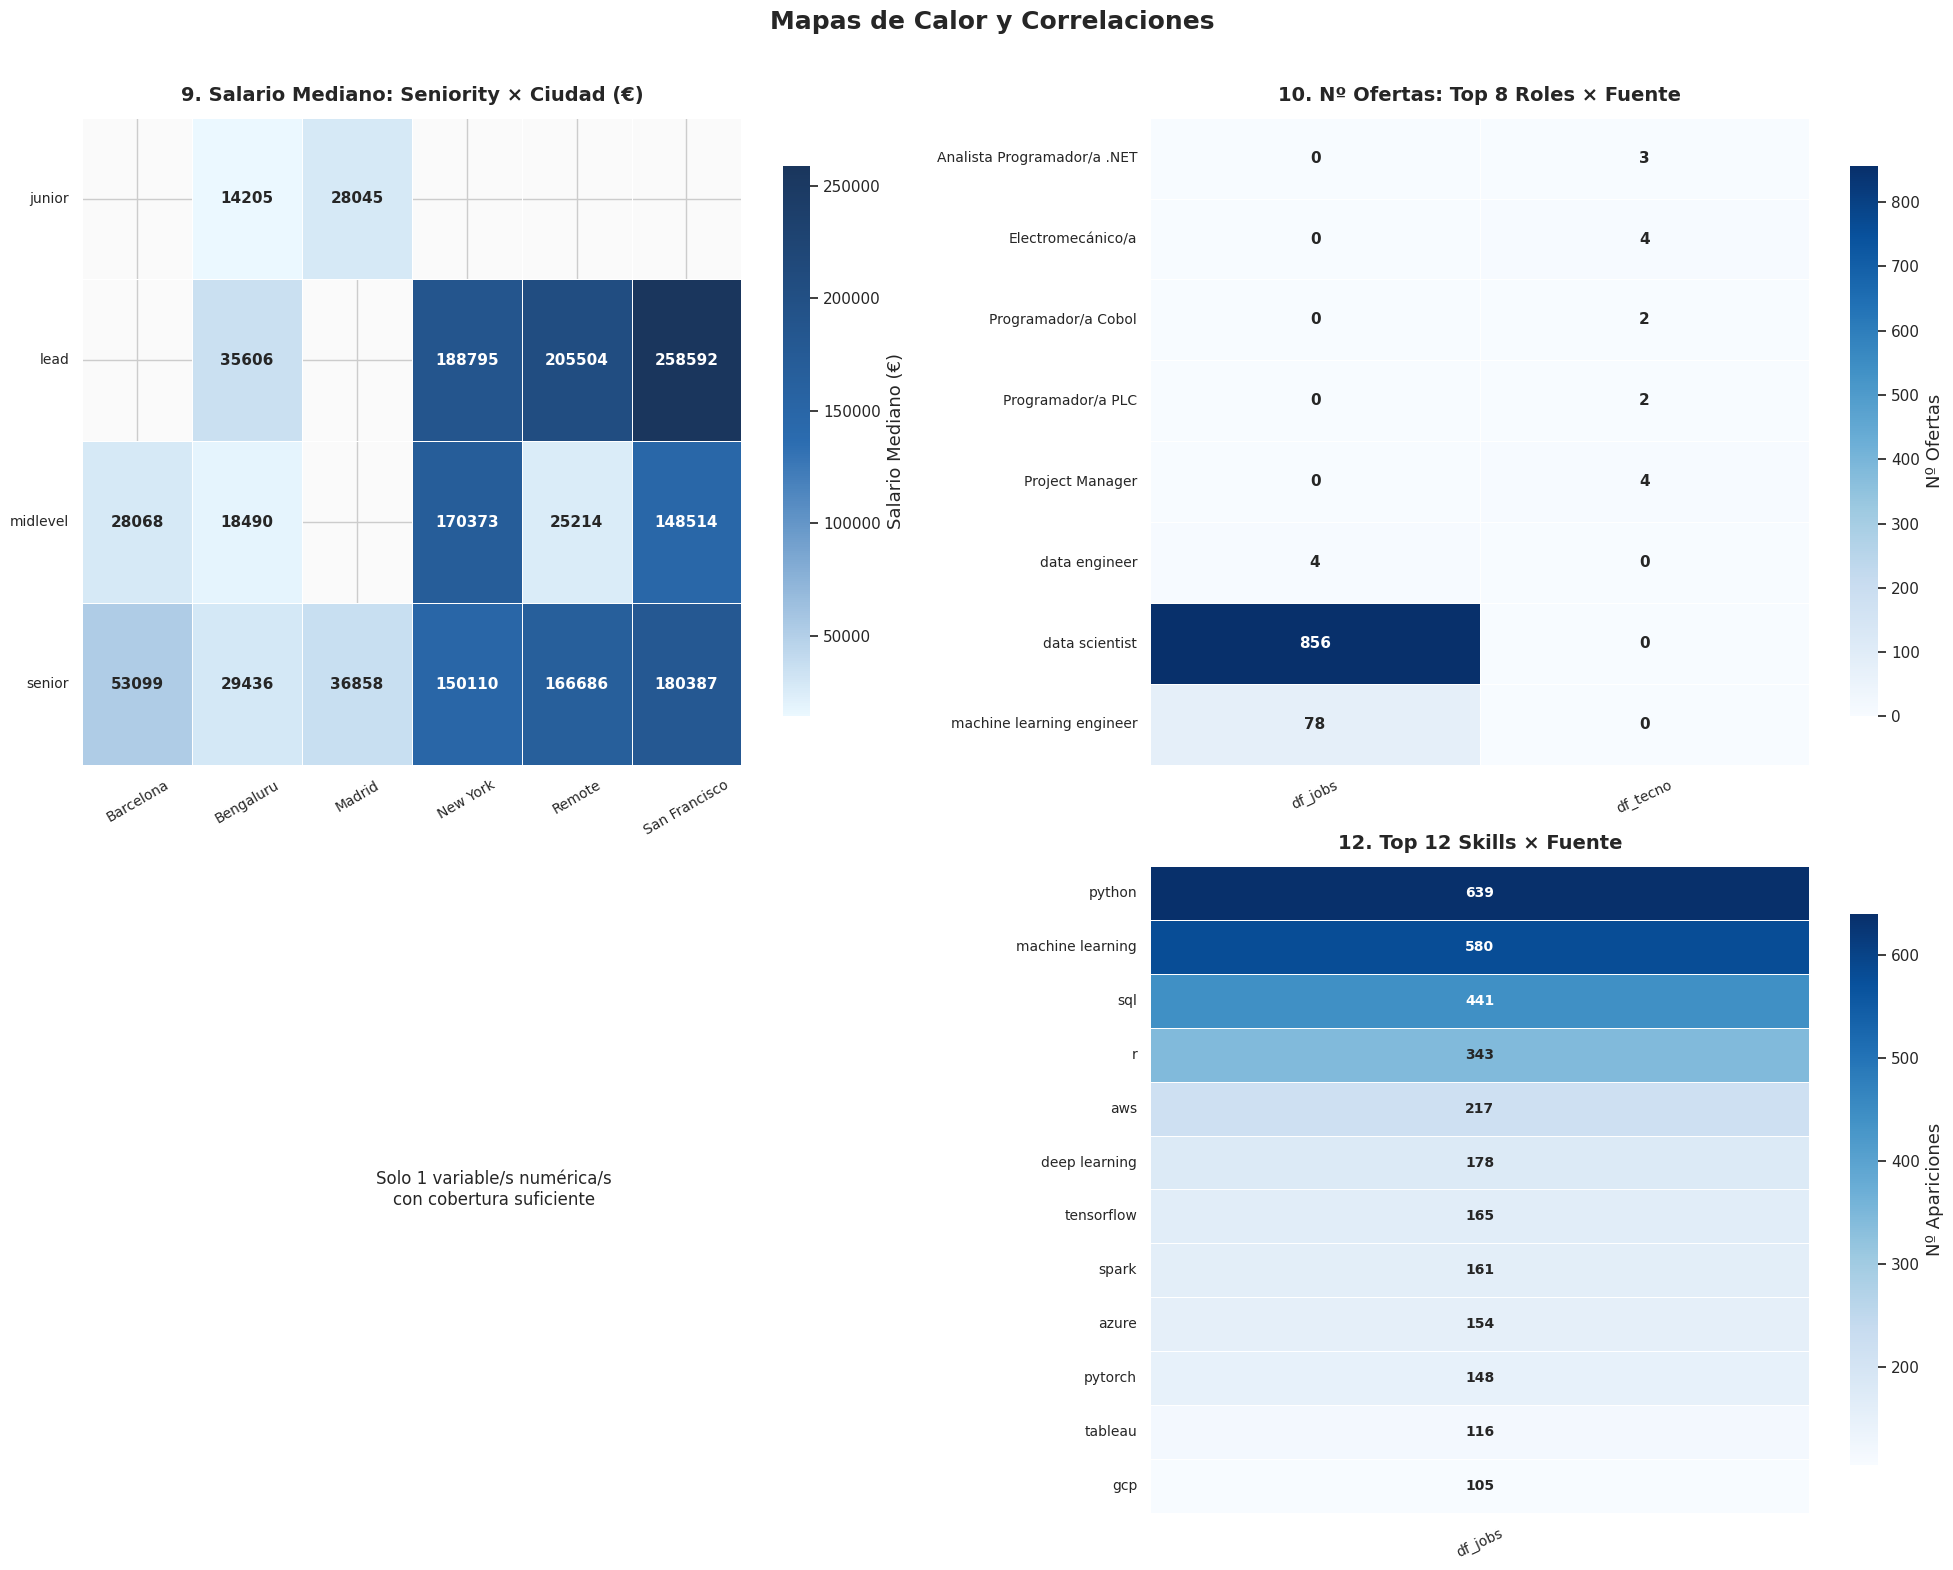

✅ Gráficos 9-12 generados.


In [109]:
# ─────────────────────────────────────────────
# BLOQUE 3 – HEATMAPS (G9 – G12)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle("Mapas de Calor y Correlaciones", fontsize=18, fontweight="bold", y=0.98)

# ── G9: Seniority × Ciudad → Salario Mediano ──────────────────
if ("seniority_level" in df_sal.columns and df_sal["seniority_level"].notna().any()
        and "city_clean" in df_sal.columns and df_sal["city_clean"].notna().any()):

    # Tomar Top 6 ciudades con más registros salariales
    top6_c = df_sal["city_clean"].value_counts().head(6).index
    _d = df_sal[df_sal["city_clean"].isin(top6_c)]

    pivot9 = _d.pivot_table(
        values=SAL_COL, index="seniority_level",
        columns="city_clean", aggfunc="median"
    )
    pivot9 = pivot9.dropna(how="all").dropna(axis=1, how="all")

    if not pivot9.empty:
        CMAP9 = LinearSegmentedColormap.from_list("g9", [PAL["light"], PAL["secondary"], PAL["primary"]])
        g9 = sns.heatmap(
            pivot9, annot=True, fmt=".0f", cmap=CMAP9,
            linewidths=0.6, linecolor="white", ax=axes[0,0],
            annot_kws={"fontsize": 11, "fontweight": "bold"},
            cbar_kws={"label": "Salario Mediano (€)", "shrink": 0.85},
            vmin=pivot9.min().min(), vmax=pivot9.max().max()
        )
        axes[0,0].set_title("9. Salario Mediano: Seniority × Ciudad (€)", pad=12)
        axes[0,0].set_xlabel("")
        axes[0,0].set_ylabel("")
        axes[0,0].tick_params(axis="x", rotation=30, labelsize=10)
        axes[0,0].tick_params(axis="y", rotation=0, labelsize=10)
    else:
        axes[0,0].text(0.5, 0.5, "Sin datos suficientes", ha="center", va="center",
                       transform=axes[0,0].transAxes); axes[0,0].axis("off")
else:
    axes[0,0].text(0.5, 0.5,
                   "Seniority o City\nno disponibles",
                   ha="center", va="center", fontsize=13,
                   transform=axes[0,0].transAxes); axes[0,0].axis("off")

# ── G10: Rol × Fuente → Nº Ofertas ───────────────────────────
# Usa source_dataset (siempre presente) en lugar de remote_modality
if "job_title" in df.columns and "source_dataset" in df.columns:
    top8_roles = df["job_title"].value_counts().head(8).index
    _d10 = df[df["job_title"].isin(top8_roles)]
    pivot10 = _d10.pivot_table(
        values=ID_COL, index="job_title",
        columns="source_dataset", aggfunc="count", fill_value=0
    )
    if not pivot10.empty:
        sns.heatmap(
            pivot10, annot=True, fmt="d", cmap="Blues",
            linewidths=0.6, linecolor="white", ax=axes[0,1],
            annot_kws={"fontsize": 11, "fontweight": "bold"},
            cbar_kws={"label": "Nº Ofertas", "shrink": 0.85}
        )
        axes[0,1].set_title("10. Nº Ofertas: Top 8 Roles × Fuente", pad=12)
        axes[0,1].set_xlabel("")
        axes[0,1].set_ylabel("")
        axes[0,1].tick_params(axis="x", rotation=25, labelsize=10)
        axes[0,1].tick_params(axis="y", rotation=0, labelsize=10)
    else:
        axes[0,1].text(0.5, 0.5, "Sin datos", ha="center", va="center",
                       transform=axes[0,1].transAxes); axes[0,1].axis("off")
else:
    axes[0,1].text(0.5, 0.5, "job_title/source_dataset\nno disponibles",
                   ha="center", va="center", transform=axes[0,1].transAxes); axes[0,1].axis("off")

# ── G11: Correlación variables numéricas ─────────────────────
num_cols = [c for c in df.select_dtypes(include="number").columns
            if df[c].notna().sum() > len(df) * 0.2
            and "outlier" not in c.lower()
            and c != ID_COL]
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    CMAP11 = sns.diverging_palette(220, 20, as_cmap=True)
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap=CMAP11, center=0,
        linewidths=0.5, linecolor="white", ax=axes[1,0],
        annot_kws={"fontsize": 10},
        cbar_kws={"shrink": 0.8}
    )
    axes[1,0].set_title("11. Correlación Variables Numéricas", pad=12)
    axes[1,0].tick_params(axis="x", rotation=30, labelsize=9)
    axes[1,0].tick_params(axis="y", rotation=0, labelsize=9)
else:
    axes[1,0].text(0.5, 0.5,
                   f"Solo {len(num_cols)} variable/s numérica/s\ncon cobertura suficiente",
                   ha="center", va="center", fontsize=12,
                   transform=axes[1,0].transAxes); axes[1,0].axis("off")

# ── G12: Top Skills × Fuente → Nº Apariciones ────────────────
if HAS_SKILLS and df_skills is not None and "source_dataset" in df_skills.columns:
    TOP_S = 12
    top_skills_list = df_skills["skill"].value_counts().head(TOP_S).index.tolist()
    _sk = df_skills[df_skills["skill"].isin(top_skills_list)]
    pivot12 = _sk.pivot_table(
        values="job_id", index="skill",
        columns="source_dataset", aggfunc="count", fill_value=0
    )
    # Ordenar por total descendente
    pivot12 = pivot12.loc[pivot12.sum(axis=1).sort_values(ascending=False).index]
    if not pivot12.empty:
        sns.heatmap(
            pivot12, annot=True, fmt="d", cmap="Blues",
            linewidths=0.6, linecolor="white", ax=axes[1,1],
            annot_kws={"fontsize": 10, "fontweight": "bold"},
            cbar_kws={"label": "Nº Apariciones", "shrink": 0.85}
        )
        axes[1,1].set_title(f"12. Top {TOP_S} Skills × Fuente", pad=12)
        axes[1,1].set_xlabel("")
        axes[1,1].set_ylabel("")
        axes[1,1].tick_params(axis="x", rotation=25, labelsize=10)
        axes[1,1].tick_params(axis="y", rotation=0, labelsize=10)
    else:
        axes[1,1].text(0.5, 0.5, "Sin datos", ha="center", va="center",
                       transform=axes[1,1].transAxes); axes[1,1].axis("off")
else:
    axes[1,1].text(0.5, 0.5,
                   "job_skills_long.csv no disponible\n(ejecuta 02_cleaning.ipynb)",
                   ha="center", va="center", fontsize=11,
                   transform=axes[1,1].transAxes); axes[1,1].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(IMAGES_DIR / "03_heatmaps.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 9-12 generados.")


### 🆕 Gráfico 13 — Heatmap de Co-ocurrencia de Skills

Muestra con qué frecuencia (% de ofertas) dos skills aparecen **juntas** en la misma oferta.  
Calculado desde `job_skills_long.csv` (generado por `02_cleaning.ipynb`).


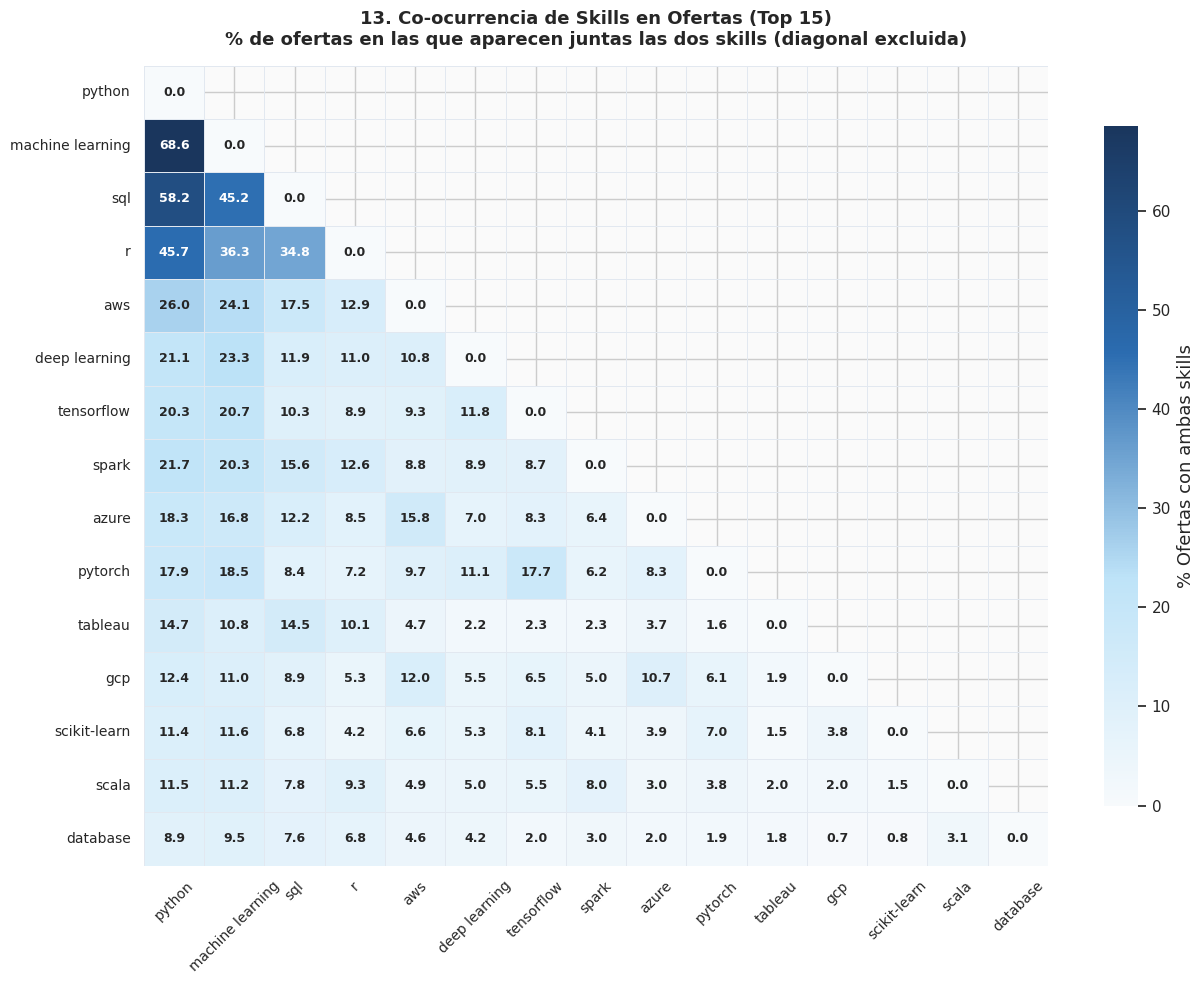

✅ Heatmap co-ocurrencia generado (739 ofertas, Top 15 skills).

🔝 Top 10 pares que más co-ocurren:


,Skill A,Skill B,Co-ocurrencia (%)
0,machine learning,python,68.60
1,sql,python,58.20
2,r,python,45.70
3,sql,machine learning,45.20
4,r,machine learning,36.30
5,r,sql,34.80
6,aws,python,26.00
7,aws,machine learning,24.10
8,deep learning,machine learning,23.30
9,spark,python,21.70


In [110]:
if HAS_SKILLS and df_skills is not None:
    TOP_N = 15
    top_sk = df_skills["skill"].value_counts().head(TOP_N).index.tolist()
    _s = df_skills[df_skills["skill"].isin(top_sk)].copy()
    _s["present"] = 1

    pivot_sk = _s.pivot_table(
        index="job_id", columns="skill", values="present", fill_value=0
    )[top_sk]

    # Matriz de co-ocurrencia normalizada (% de todas las ofertas)
    n_jobs = pivot_sk.shape[0]
    co_mat = (pivot_sk.T @ pivot_sk) / n_jobs * 100
    co_mat = co_mat.round(1)

    # Orden por frecuencia individual (diagonal)
    freq_order = pd.Series(np.diag(co_mat), index=co_mat.columns).sort_values(ascending=False).index
    co_mat = co_mat.loc[freq_order, freq_order]

    # Diagonal a 0 para que el gradiente sea más informativo
    np.fill_diagonal(co_mat.values, 0)

    # Máscara triángulo superior
    mask_up = np.triu(np.ones_like(co_mat, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(13, 10))
    CMAP13 = LinearSegmentedColormap.from_list("cooc", ["#F7FAFC", "#BEE3F8", PAL["secondary"], PAL["primary"]])
    sns.heatmap(
        co_mat, mask=mask_up,
        annot=True, fmt=".1f", cmap=CMAP13,
        linewidths=0.5, linecolor="#E2E8F0", ax=ax,
        annot_kws={"fontsize": 9, "fontweight": "bold"},
        cbar_kws={"label": "% Ofertas con ambas skills", "shrink": 0.85},
        vmin=0
    )
    ax.set_title(
        f"13. Co-ocurrencia de Skills en Ofertas (Top {TOP_N})\n"
        "% de ofertas en las que aparecen juntas las dos skills (diagonal excluida)",
        fontsize=13, fontweight="bold", pad=15
    )
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    ax.tick_params(axis="y", rotation=0, labelsize=10)

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "03c_heatmap_coocurrencia_skills.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Top 10 pares co-ocurrentes
    _co_stacked = (
        co_mat.where(~mask_up & ~np.eye(len(co_mat), dtype=bool))
        .stack()
        .rename_axis(index=['Skill A', 'Skill B'])
    )
    co_long = _co_stacked.reset_index(name="Co-ocurrencia (%)")
    print(f"✅ Heatmap co-ocurrencia generado ({n_jobs:,} ofertas, Top {TOP_N} skills).")
    print("\n🔝 Top 10 pares que más co-ocurren:")
    display(co_long.sort_values("Co-ocurrencia (%)", ascending=False).head(10).reset_index(drop=True))
else:
    print("ℹ️  job_skills_long.csv no disponible — ejecuta 02_cleaning.ipynb primero.")

## 🚀 Bloque 4 — Stack Tecnológico y Brecha Used vs Wanted

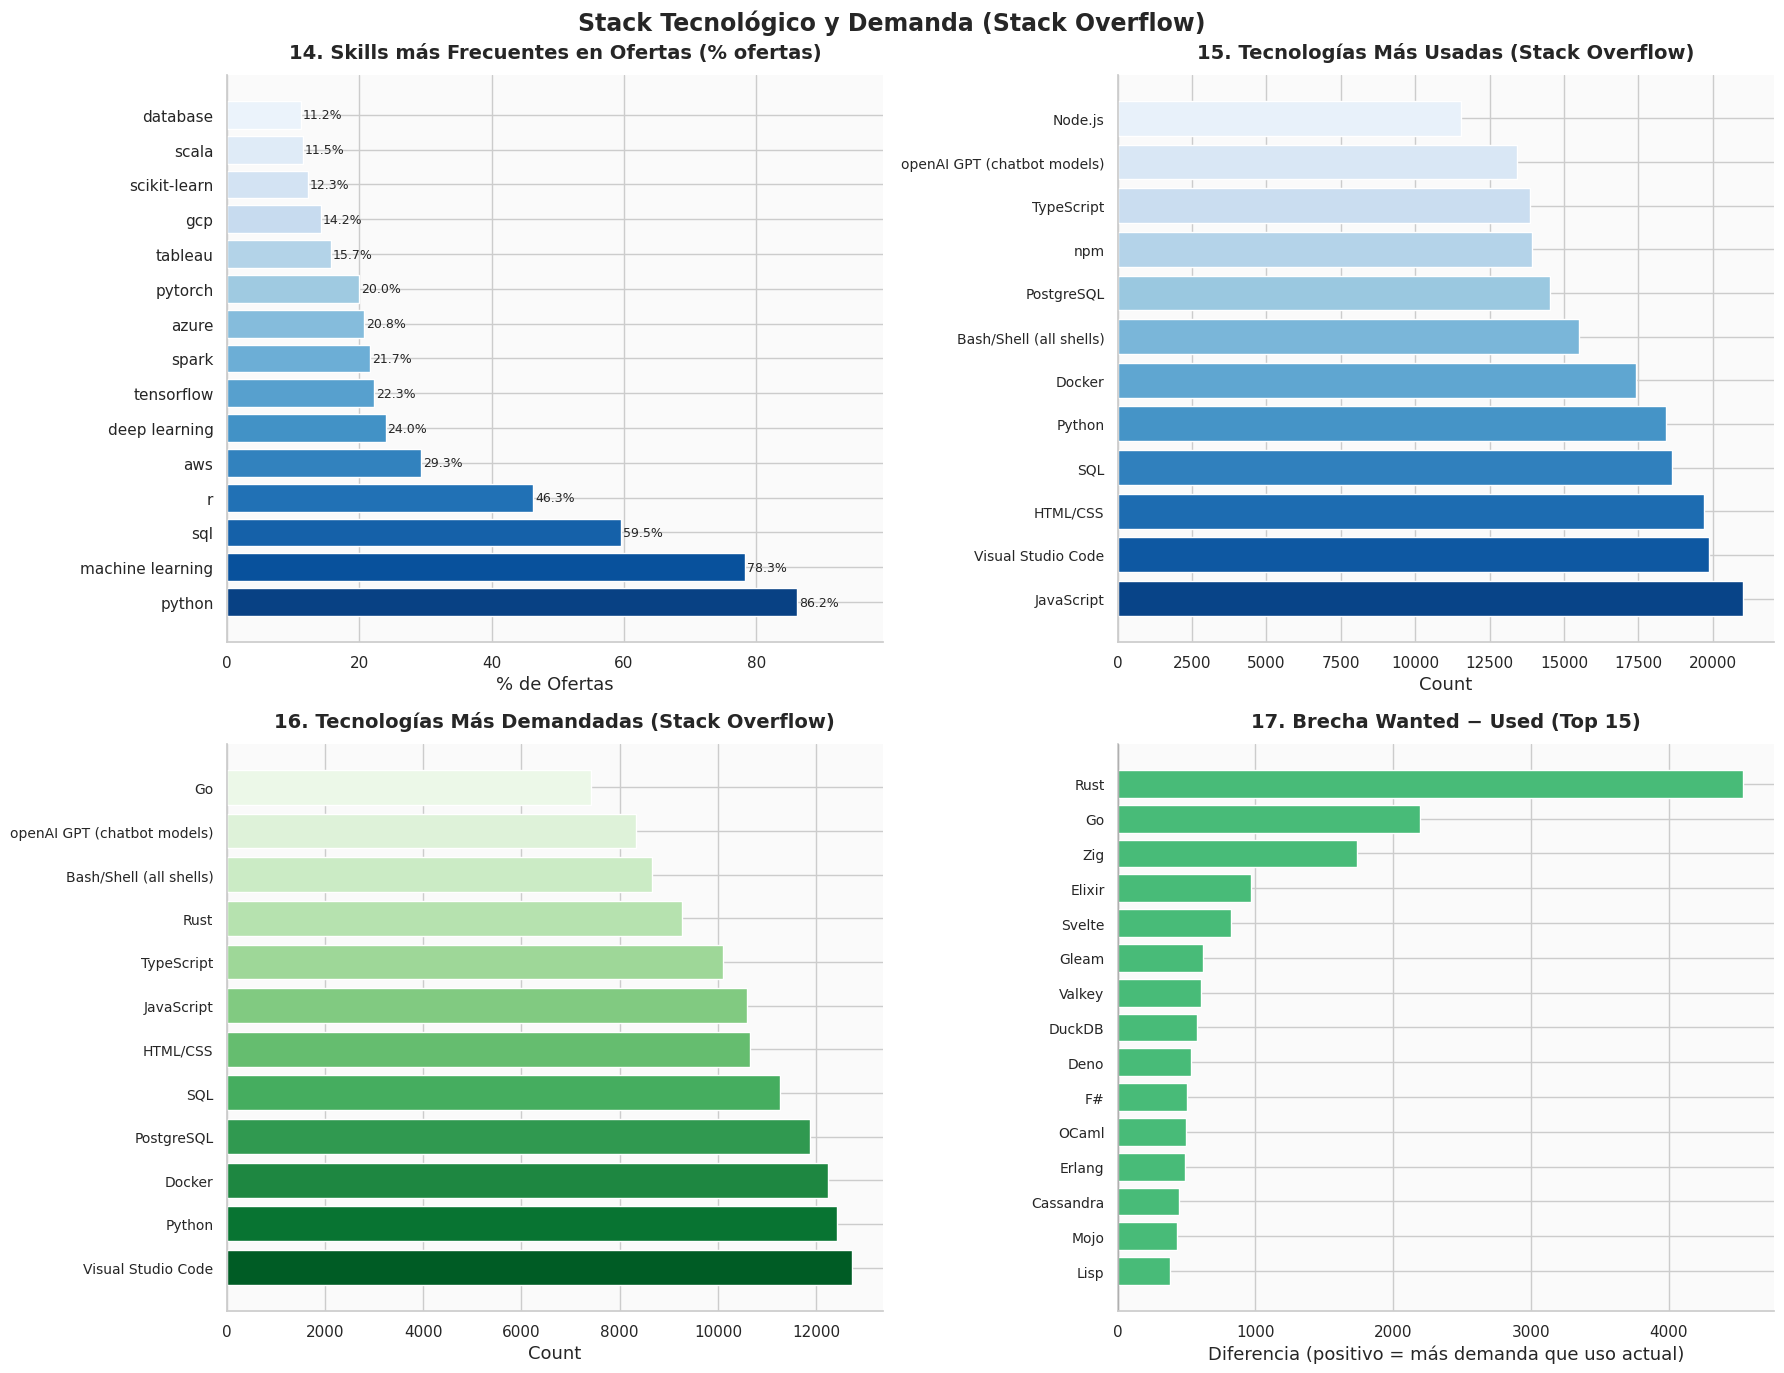

✅ Gráficos 14-17 generados.


In [111]:
# Detectar columnas de los rankings (generados en nb02)
# Estructura: category | type | technology | count
TECH_COL = "technology"
CNT_COL  = "count"

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Stack Tecnológico y Demanda (Stack Overflow)", fontsize=17, fontweight="bold")

# G14: Top skills en ofertas (desde job_skills_long)
if HAS_SKILLS and df_skills is not None:
    top_sk_bar = df_skills["skill"].value_counts().head(15)
    pct_sk = (top_sk_bar / df_skills["job_id"].nunique() * 100).round(1)
    bars14 = axes[0,0].barh(pct_sk.index, pct_sk.values,
                             color=sns.color_palette("Blues_r", len(pct_sk)), edgecolor="white")
    axes[0,0].set_title("14. Skills más Frecuentes en Ofertas (% ofertas)", pad=12)
    axes[0,0].set_xlabel("% de Ofertas")
    axes[0,0].set_xlim(0, pct_sk.max() * 1.15)
    for b, v in zip(bars14, pct_sk.values):
        axes[0,0].text(b.get_width() + .3, b.get_y() + b.get_height()/2,
                       f"{v:.1f}%", va="center", fontsize=9)
else:
    axes[0,0].text(0.5, 0.5, "job_skills_long no disponible", ha="center", va="center",
                   transform=axes[0,0].transAxes); axes[0,0].axis("off")

# G15: Top tecnologías USADAS (Stack Overflow)
top_used = df_used.sort_values(CNT_COL, ascending=False).head(12)
axes[0,1].barh(top_used[TECH_COL], top_used[CNT_COL],
               color=sns.color_palette("Blues_r", len(top_used)), edgecolor="white")
axes[0,1].set_title("15. Tecnologías Más Usadas (Stack Overflow)", pad=12)
axes[0,1].set_xlabel("Count")
axes[0,1].tick_params(axis="y", labelsize=10)

# G16: Top tecnologías DEMANDADAS (Stack Overflow)
top_wanted = df_wanted.sort_values(CNT_COL, ascending=False).head(12)
axes[1,0].barh(top_wanted[TECH_COL], top_wanted[CNT_COL],
               color=sns.color_palette("Greens_r", len(top_wanted)), edgecolor="white")
axes[1,0].set_title("16. Tecnologías Más Demandadas (Stack Overflow)", pad=12)
axes[1,0].set_xlabel("Count")
axes[1,0].tick_params(axis="y", labelsize=10)

# G17: Brecha Wanted − Used
common = set(df_used[TECH_COL]) & set(df_wanted[TECH_COL])
if common:
    df_gap = pd.merge(
        df_used[df_used[TECH_COL].isin(common)][[TECH_COL, CNT_COL]].rename(columns={CNT_COL: "used"}),
        df_wanted[df_wanted[TECH_COL].isin(common)][[TECH_COL, CNT_COL]].rename(columns={CNT_COL: "wanted"}),
        on=TECH_COL
    )
    df_gap["gap"] = df_gap["wanted"] - df_gap["used"]
    df_gap = df_gap.nlargest(15, "gap") if df_gap["gap"].max() > 0 else df_gap.nsmallest(15, "gap")
    df_gap = df_gap.sort_values("gap")
    colors17 = [PAL["success"] if v >= 0 else PAL["warm"] for v in df_gap["gap"]]
    axes[1,1].barh(df_gap[TECH_COL], df_gap["gap"], color=colors17, edgecolor="white")
    axes[1,1].axvline(0, color="black", linewidth=0.8)
    axes[1,1].set_title("17. Brecha Wanted − Used (Top 15)", pad=12)
    axes[1,1].set_xlabel("Diferencia (positivo = más demanda que uso actual)")
    axes[1,1].tick_params(axis="y", labelsize=10)
else:
    axes[1,1].text(0.5, 0.5, "Sin tecnologías comunes para brecha", ha="center", va="center",
                   transform=axes[1,1].transAxes); axes[1,1].axis("off")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "04_stack_tecnologico.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 14-17 generados.")


## 📐 Bloque 5 — Análisis Estadístico Avanzado

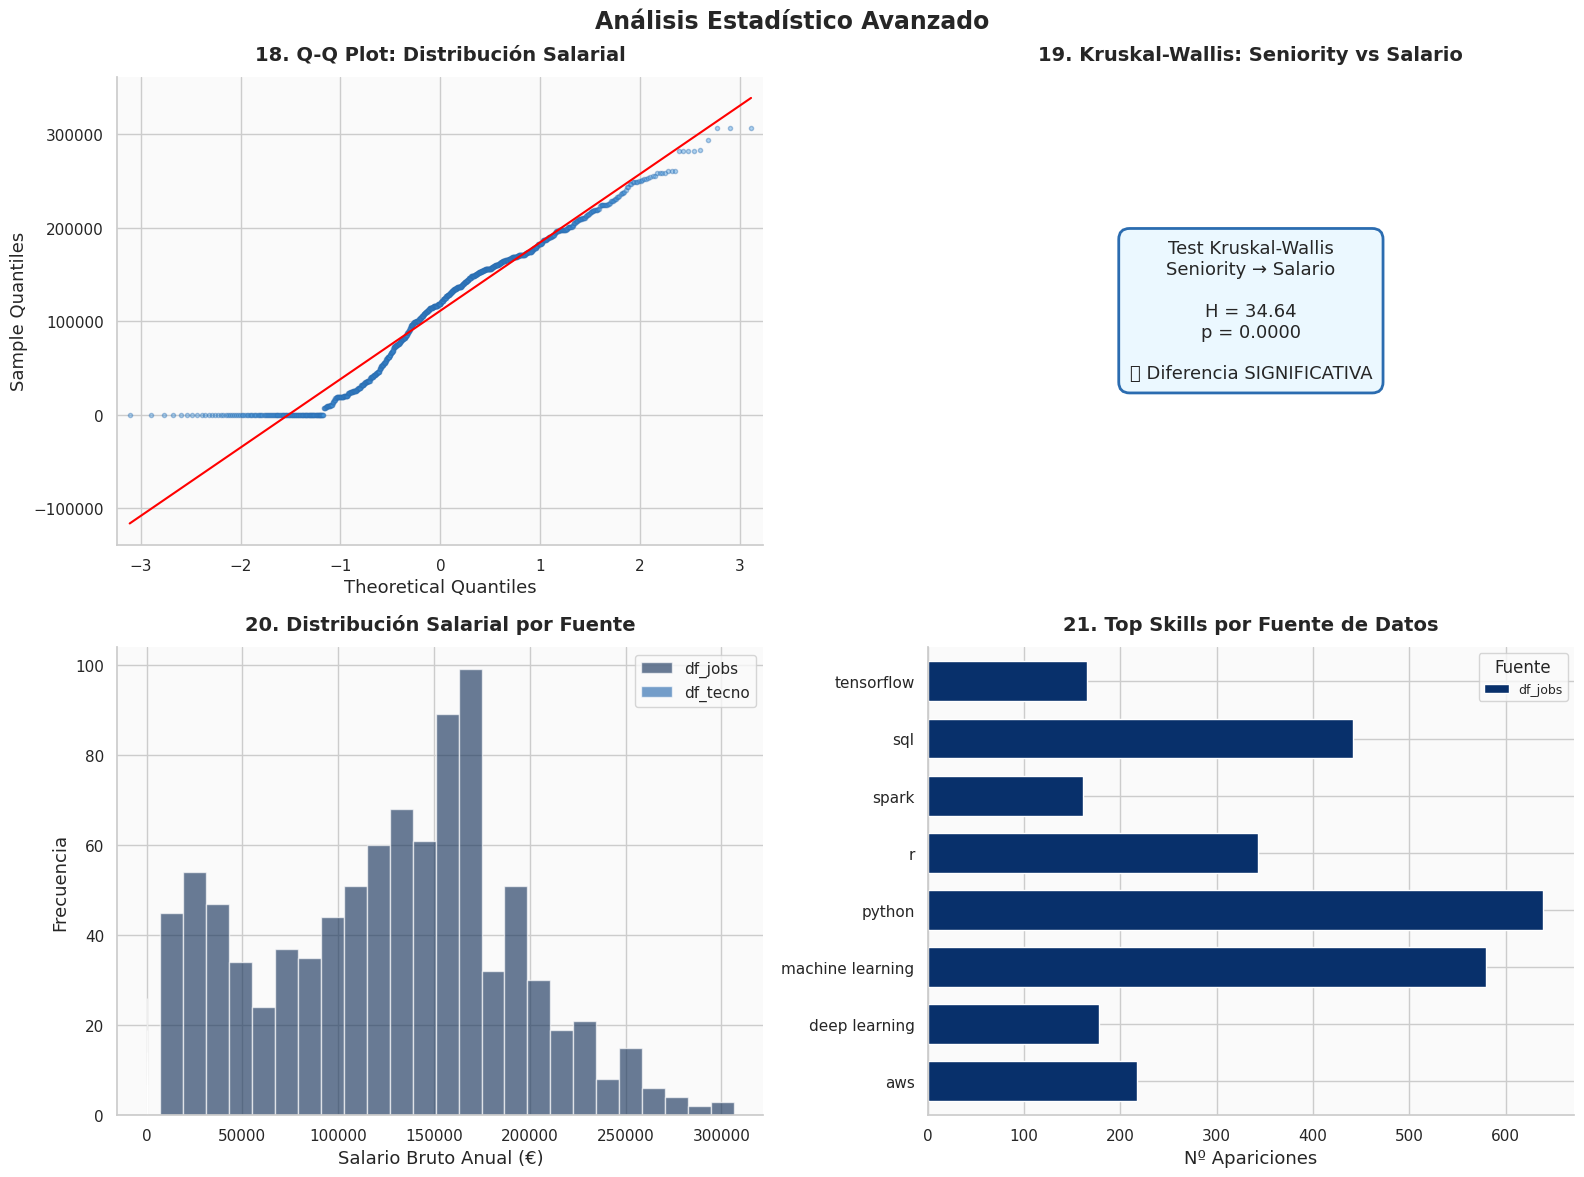

✅ Gráficos 18-21 generados.


In [112]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Análisis Estadístico Avanzado")

fmt_euro = mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €")

# G18: Q-Q Plot de salarios
sal_sample = df_sal[SAL_COL].dropna()
if len(sal_sample) > 20:
    if HAS_STATSMODELS:
        sm.qqplot(sal_sample, line="s", ax=axes[0,0],
                  markerfacecolor=PAL["accent"], markeredgecolor=PAL["secondary"],
                  alpha=0.4, markersize=3)
    else:
        (osm, osr), (slope, intercept, _) = stats.probplot(sal_sample, dist="norm")
        axes[0,0].scatter(osm, osr, alpha=0.35, color=PAL["accent"], s=12)
        axes[0,0].plot(osm, slope * np.array(osm) + intercept, color=PAL["warm"], lw=1.8)
        axes[0,0].set_xlabel("Cuantiles teóricos"); axes[0,0].set_ylabel("Cuantiles muestra")
    axes[0,0].set_title("18. Q-Q Plot: Distribución Salarial", pad=12)
else:
    axes[0,0].text(0.5, 0.5, "Datos insuficientes", ha="center", va="center",
                   transform=axes[0,0].transAxes); axes[0,0].axis("off")

# G19: Kruskal-Wallis Seniority → Salario
if "seniority_level" in df_sal.columns and df_sal["seniority_level"].notna().any():
    groups = [g[SAL_COL].dropna().values
              for _, g in df_sal.groupby("seniority_level") if len(g) >= 5]
    if len(groups) >= 2:
        H, p = kruskal(*groups)
        axes[0,1].axis("off")
        sig = "✅ Diferencia SIGNIFICATIVA" if p < 0.05 else "❌ Sin diferencia significativa"
        axes[0,1].text(0.5, 0.5,
                       f"Test Kruskal-Wallis\nSeniority → Salario\n\nH = {H:.2f}\np = {p:.4f}\n\n{sig}",
                       ha="center", va="center", fontsize=13,
                       transform=axes[0,1].transAxes,
                       bbox=dict(boxstyle="round,pad=0.6", facecolor=PAL["light"],
                                 edgecolor=PAL["secondary"], linewidth=2))
        axes[0,1].set_title("19. Kruskal-Wallis: Seniority vs Salario", pad=12)
    else:
        axes[0,1].text(0.5, 0.5, "Grupos insuficientes", ha="center", va="center",
                       transform=axes[0,1].transAxes); axes[0,1].axis("off")
else:
    axes[0,1].axis("off")

# G20: Distribución por fuente (si hay más de una)
if "source_dataset" in df_sal.columns and df_sal["source_dataset"].nunique() > 1:
    for src, grp in df_sal.groupby("source_dataset"):
        axes[1,0].hist(grp[SAL_COL].dropna(), bins=25, alpha=0.65,
                       label=src, edgecolor="white")
    axes[1,0].set_title("20. Distribución Salarial por Fuente", pad=12)
    axes[1,0].set_xlabel("Salario Bruto Anual (€)")
    axes[1,0].set_ylabel("Frecuencia")
    axes[1,0].legend()
else:
    axes[1,0].hist(df_sal[SAL_COL].dropna(), bins=30,
                   color=PAL["secondary"], edgecolor="white", alpha=0.85)
    axes[1,0].set_title("20. Distribución Salarial General", pad=12)
    axes[1,0].set_xlabel("Salario Bruto Anual (€)")
    axes[1,0].set_ylabel("Frecuencia")

# G21: Skills en modalidad remota vs. presencial (si datos disponibles)
if HAS_SKILLS and df_skills is not None and "source_dataset" in df_skills.columns:
    src_skill = df_skills["source_dataset"].value_counts().head(3).index
    top5_sk = df_skills["skill"].value_counts().head(8).index
    _d21 = df_skills[df_skills["source_dataset"].isin(src_skill) & df_skills["skill"].isin(top5_sk)]
    if not _d21.empty:
        pivot21 = _d21.pivot_table(
            values="job_id", index="skill", columns="source_dataset",
            aggfunc="count", fill_value=0
        )
        pivot21.plot(kind="barh", ax=axes[1,1], colormap="Blues_r", width=0.7)
        axes[1,1].set_title("21. Top Skills por Fuente de Datos", pad=12)
        axes[1,1].set_xlabel("Nº Apariciones")
        axes[1,1].set_ylabel("")
        axes[1,1].legend(title="Fuente", fontsize=9)
    else:
        axes[1,1].axis("off")
else:
    axes[1,1].axis("off")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "05_estadistica_avanzada.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 18-21 generados.")


## 🌐 Bloque 6 — Visualizaciones Interactivas (Plotly)

In [113]:
if not HAS_PLOTLY:
    print("⚠️  Plotly no instalado. Ejecuta la celda de instalación y reinicia el entorno.")
else:
    # G22: Box interactivo Seniority × Rol
    if "seniority_level" in df_sal.columns and "job_title" in df_sal.columns:
        # Limitar a top 10 roles para legibilidad
        top10r = df_sal["job_title"].value_counts().head(10).index
        _d22 = df_sal[df_sal["job_title"].isin(top10r)]
        fig22 = px.box(
            _d22, x="seniority_level", y=SAL_COL, color="job_title",
            title="22. Distribución Salarial: Seniority × Rol (interactivo)",
            labels={SAL_COL: "Salario (€)", "seniority_level": ""},
            template="plotly_white",
        )
        fig22.update_layout(legend_title_text="Rol")
        fig22.show()

    # G23: Top ciudades interactivo
    if "city_clean" in df.columns:
        city_df = df["city_clean"].value_counts().head(10).reset_index()
        city_df.columns = ["Ciudad", "Nº Ofertas"]
        fig23 = px.bar(city_df, x="Nº Ofertas", y="Ciudad", orientation="h",
                       title="23. Top 10 Ciudades por Volumen de Ofertas",
                       template="plotly_white",
                       color="Nº Ofertas", color_continuous_scale="Blues")
        fig23.update_layout(coloraxis_showscale=False)
        fig23.show()

    # G24: Skills frecuencia interactivo
    if HAS_SKILLS and df_skills is not None:
        top_sk24 = df_skills["skill"].value_counts().head(20).reset_index()
        top_sk24.columns = ["Skill", "Count"]
        pct24 = (top_sk24["Count"] / df_skills["job_id"].nunique() * 100).round(1)
        top_sk24["% Ofertas"] = pct24
        fig24 = px.bar(top_sk24.sort_values("% Ofertas"),
                       x="% Ofertas", y="Skill", orientation="h",
                       title="24. Skills más Frecuentes en Ofertas (%)",
                       template="plotly_white",
                       color="% Ofertas", color_continuous_scale="Blues")
        fig24.show()

    print("✅ Gráficos interactivos 22-24 generados.")


✅ Gráficos interactivos 22-24 generados.


## 🏁 Bloque 7 — Panel de KPIs Ejecutivo

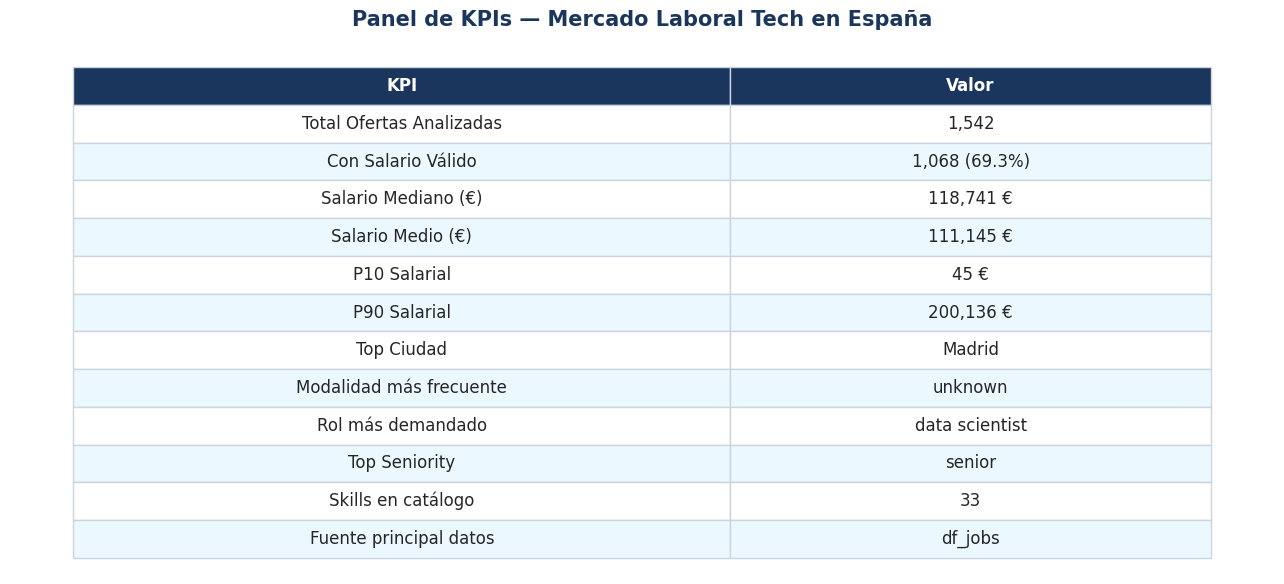


🖼️  8 gráficos exportados en alta resolución (200 DPI):
  ✅ 01_distribucion_volumen.png                        198 KB
  ✅ 02_analisis_salarial.png                           399 KB
  ✅ 02b_salario_por_rol.png                            114 KB
  ✅ 03_heatmaps.png                                    415 KB
  ✅ 03c_heatmap_coocurrencia_skills.png                307 KB
  ✅ 04_stack_tecnologico.png                           387 KB
  ✅ 05_estadistica_avanzada.png                        297 KB
  ✅ 07_kpis.png                                        150 KB

🎉 Análisis completado.


In [114]:
kpis = {
    "Total Ofertas Analizadas":  f"{len(df):,}",
    "Con Salario Válido":        f"{len(df_sal):,} ({len(df_sal)/len(df)*100:.1f}%)",
    "Salario Mediano (€)":       f"{df_sal[SAL_COL].median():,.0f} €" if len(df_sal) > 0 else "N/D",
    "Salario Medio (€)":         f"{df_sal[SAL_COL].mean():,.0f} €"   if len(df_sal) > 0 else "N/D",
    "P10 Salarial":              f"{df_sal[SAL_COL].quantile(.10):,.0f} €" if len(df_sal) > 0 else "N/D",
    "P90 Salarial":              f"{df_sal[SAL_COL].quantile(.90):,.0f} €" if len(df_sal) > 0 else "N/D",
    "Top Ciudad":                df["city_clean"].value_counts().index[0] if "city_clean" in df.columns and df["city_clean"].notna().any() else "N/D",
    "Modalidad más frecuente":   df["work_modality"].value_counts().index[0] if "work_modality" in df.columns else "N/D",
    "Rol más demandado":         df["job_title"].value_counts().index[0][:40] if "job_title" in df.columns else "N/D",
    "Top Seniority":             df["seniority_level"].value_counts().index[0] if "seniority_level" in df.columns and df["seniority_level"].notna().any() else "N/D",
    "Skills en catálogo":        f"{df_skills['skill'].nunique():,}" if HAS_SKILLS and df_skills is not None else "N/D",
    "Fuente principal datos":    df["source_dataset"].value_counts().index[0] if "source_dataset" in df.columns else "N/D",
}

fig, ax = plt.subplots(figsize=(13, 6))
ax.axis("off")
tdata = [[k, v] for k, v in kpis.items()]
tbl = ax.table(cellText=tdata, colLabels=["KPI", "Valor"],
               cellLoc="center", loc="center", colWidths=[0.52, 0.38])
tbl.auto_set_font_size(False); tbl.set_fontsize(12); tbl.scale(1, 2.0)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(PAL["primary"]); cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor(PAL["light"])
    cell.set_edgecolor("#CBD5E0")

ax.set_title("Panel de KPIs — Mercado Laboral Tech en España",
             fontsize=15, fontweight="bold", pad=18, color=PAL["primary"])

plt.tight_layout()
plt.savefig(IMAGES_DIR / "07_kpis.png", dpi=200, bbox_inches="tight")
plt.show()

# Inventario de archivos exportados
files_out = sorted(IMAGES_DIR.glob("*.png"))
print(f"\n🖼️  {len(files_out)} gráficos exportados en alta resolución (200 DPI):")
for f in files_out:
    print(f"  ✅ {f.name:<50} {f.stat().st_size/1024:.0f} KB")
print("\n🎉 Análisis completado.")


## 🔄 Bloque 8 — Análisis de Reskilling y Brecha de Competencias

> **¿Qué es el reskilling?**  
> El reskilling (reconversión profesional) consiste en adquirir nuevas competencias para transitar hacia un rol diferente al actual. En el mercado tech español, perfiles de otras disciplinas (química, física, ingeniería clásica, humanidades) están migrando hacia Data Science, ML e IA.

Este bloque cuantifica:
- Las **skills más demandadas** en el mercado vs. las disponibles en perfiles de transición.
- La **brecha** entre habilidades de origen y destino para los itinerarios de reskilling más comunes.
- El **potencial de reskilling** de los roles más activos en el mercado.


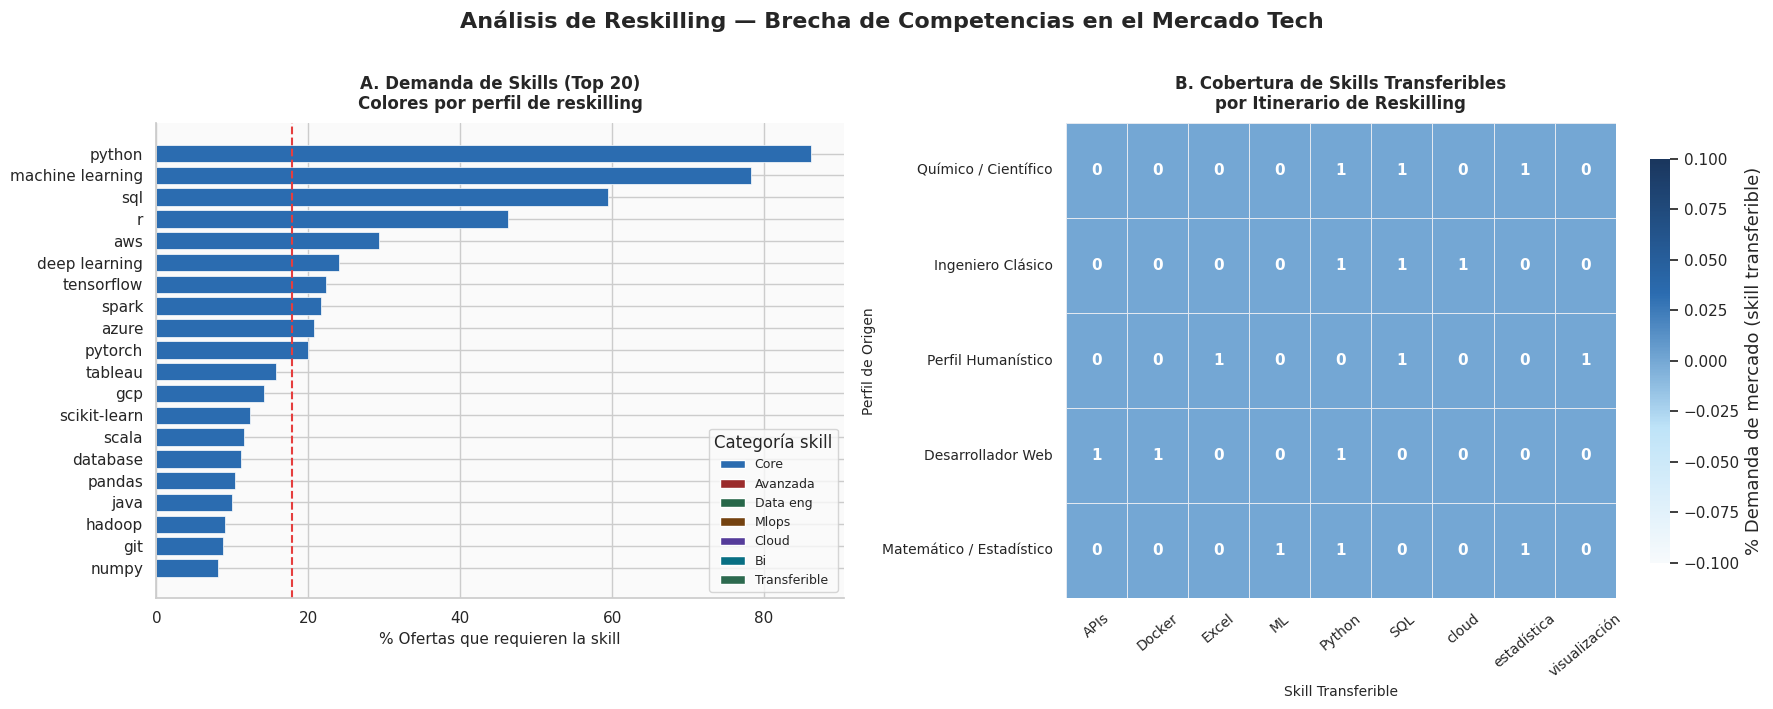


📊 Itinerarios de Reskilling detectados en el mercado tech español:



,Perfil Origen,Rol Destino,Skills Transferibles,Demanda Media (%)
0,Químico / Científico,Data Scientist,"Python, estadística, SQL",0.00
1,Ingeniero Clásico,Data / ML Engineer,"Python, SQL, cloud",0.00
2,Perfil Humanístico,Data Analyst / BI,"Excel, SQL, visualización",0.00
3,Desarrollador Web,ML Engineer / MLOps,"Python, Docker, APIs",0.00
4,Matemático / Estadístico,Data Scientist / AI,"Python, ML, estadística",0.00



✅ Análisis de reskilling completado.
   💡 Las skills transferibles de mayor demanda reducen la brecha de entrada al mercado tech.


In [115]:
# ── BLOQUE 8 — Análisis de Reskilling y Brecha de Competencias ─────────────
if HAS_SKILLS and df_skills is not None:

    # ── 1. Itinerarios de reskilling más comunes ─────────────────────────────
    # Mapa: perfil origen → rol destino + skills transferibles
    reskilling_paths = {
        "Químico / Científico":    {"destino": "Data Scientist",         "transferibles": ["Python", "estadística", "SQL"]},
        "Ingeniero Clásico":       {"destino": "Data / ML Engineer",     "transferibles": ["Python", "SQL", "cloud"]},
        "Perfil Humanístico":      {"destino": "Data Analyst / BI",      "transferibles": ["Excel", "SQL", "visualización"]},
        "Desarrollador Web":       {"destino": "ML Engineer / MLOps",    "transferibles": ["Python", "Docker", "APIs"]},
        "Matemático / Estadístico":{"destino": "Data Scientist / AI",    "transferibles": ["Python", "ML", "estadística"]},
    }

    # ── 2. Skills que el mercado demanda (top 20) ────────────────────────────
    top20_demand = df_skills["skill"].value_counts().head(20)
    pct_demand   = (top20_demand / df_skills["job_id"].nunique() * 100).round(1)

    # ── 3. Gráfico A — Demanda de skills y zona de reskilling ────────────────
    RESKILL_TAGS = {
        "Python":        "core",
        "SQL":           "core",
        "Machine Learning": "core",
        "Deep Learning": "avanzada",
        "TensorFlow":    "avanzada",
        "PyTorch":       "avanzada",
        "Spark":         "data eng",
        "Kubernetes":    "mlops",
        "Docker":        "mlops",
        "Azure":         "cloud",
        "AWS":           "cloud",
        "Power BI":      "bi",
        "Tableau":       "bi",
        "Excel":         "transferible",
        "estadística":   "transferible",
        "visualización": "transferible",
    }
    # Colores por categoría
    TAG_COLORS = {
        "core":         "#2B6CB0",
        "avanzada":     "#9B2C2C",
        "data eng":     "#276749",
        "mlops":        "#744210",
        "cloud":        "#553C9A",
        "bi":           "#086F83",
        "transferible": "#2D6A4F",
    }
    bar_colors = [TAG_COLORS.get(RESKILL_TAGS.get(sk, "core"), "#4A5568") for sk in pct_demand.index]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle("Análisis de Reskilling — Brecha de Competencias en el Mercado Tech",
                 fontsize=16, fontweight="bold", y=1.01)

    # Panel izquierdo: barras de demanda con colores por categoría
    axes[0].barh(pct_demand.index[::-1], pct_demand.values[::-1],
                 color=list(reversed(bar_colors)), edgecolor="white", linewidth=0.5)
    axes[0].set_xlabel("% Ofertas que requieren la skill", fontsize=11)
    axes[0].set_title("A. Demanda de Skills (Top 20)\nColores por perfil de reskilling", pad=10, fontsize=12)
    axes[0].axvline(pct_demand.median(), color="#E53E3E", linestyle="--", linewidth=1.5,
                    label=f"Mediana ({pct_demand.median():.1f}%)")
    axes[0].legend(fontsize=10)

    # Leyenda de categorías
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=t.capitalize()) for t, c in TAG_COLORS.items()]
    axes[0].legend(handles=legend_elements, loc="lower right", fontsize=9, title="Categoría skill")

    # Panel derecho: heatmap de cobertura reskilling por itinerario
    path_labels = list(reskilling_paths.keys())
    all_transferibles = sorted({s for p in reskilling_paths.values() for s in p["transferibles"]})
    coverage_matrix = []
    for path in path_labels:
        row = [1 if skill in reskilling_paths[path]["transferibles"] else 0
               for skill in all_transferibles]
        coverage_matrix.append(row)

    import numpy as _np
    cov_df = pd.DataFrame(coverage_matrix, index=path_labels, columns=all_transferibles)

    # % de demanda de cada skill transferible en el mercado
    demand_vals = [float(pct_demand.get(sk, 0)) for sk in all_transferibles]
    weighted = cov_df.multiply(demand_vals, axis=1)

    CMAP_RSK = LinearSegmentedColormap.from_list("rsk", ["#F7FAFC", "#BEE3F8", PAL["secondary"], PAL["primary"]])
    sns.heatmap(weighted, ax=axes[1], annot=cov_df.values.astype(int),
                fmt="d", cmap=CMAP_RSK,
                linewidths=0.6, linecolor="#E2E8F0",
                cbar_kws={"label": "% Demanda de mercado (skill transferible)", "shrink": 0.85},
                annot_kws={"fontsize": 11, "fontweight": "bold"})
    axes[1].set_title("B. Cobertura de Skills Transferibles\npor Itinerario de Reskilling",
                      pad=10, fontsize=12)
    axes[1].set_xlabel("Skill Transferible", fontsize=10)
    axes[1].set_ylabel("Perfil de Origen", fontsize=10)
    axes[1].tick_params(axis="x", rotation=40, labelsize=10)
    axes[1].tick_params(axis="y", rotation=0, labelsize=10)

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "08_reskilling.png", dpi=200, bbox_inches="tight")
    plt.show()

    # ── 4. Tabla resumen de itinerarios ─────────────────────────────────────
    print("\n📊 Itinerarios de Reskilling detectados en el mercado tech español:\n")
    summary_rows = []
    for origen, info in reskilling_paths.items():
        transferibles = info["transferibles"]
        demanda_media = round(
            sum(float(pct_demand.get(sk, 0)) for sk in transferibles) / len(transferibles), 1
        )
        summary_rows.append({
            "Perfil Origen":       origen,
            "Rol Destino":         info["destino"],
            "Skills Transferibles": ", ".join(transferibles),
            "Demanda Media (%)":    demanda_media,
        })
    df_rsk = pd.DataFrame(summary_rows).sort_values("Demanda Media (%)", ascending=False)
    display(df_rsk.reset_index(drop=True))

    print("\n✅ Análisis de reskilling completado.")
    print("   💡 Las skills transferibles de mayor demanda reducen la brecha de entrada al mercado tech.")
else:
    print("ℹ️  job_skills_long.csv no disponible — ejecuta 02_cleaning.ipynb primero.")


---
# ⚖️ MÓDULO 05 — Análisis de Sesgos
---

# 05 — Análisis de Sesgos

**Objetivo:** Evaluar los sesgos presentes en los datasets de ofertas de empleo y en la encuesta de Stack Overflow, y estimar su posible impacto en las decisiones de DataTalent Solutions.

Este notebook responde directamente a las preguntas de negocio 2 y 5:

- ¿Existen sesgos en la distribución salarial según género, ciudad o tipo de contrato?
- ¿Qué decisiones podrían tomarse a partir de datos incompletos o sesgados?

El análisis se centrará en:

- Representatividad geográfica de las ofertas.
- Completitud y distribución del dato salarial.
- Sesgos demográficos (con datos de Stack Overflow).
- Posibles distorsiones en las conclusiones si se ignora la calidad de los datos.

In [116]:
# ============================================================
# IMPORTS, CONFIGURACIÓN Y RUTAS
# ============================================================
import os, re, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Rutas del proyecto (compatibles con ejecución desde notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW   = PROJECT_ROOT / "data" / "raw"
DATA_CLEAN = PROJECT_ROOT / "data" / "clean"

print("Raíz del proyecto:", PROJECT_ROOT)
print("Carpeta raw:", DATA_RAW)
print("Carpeta clean:", DATA_CLEAN)

Raíz del proyecto: /content
Carpeta raw: /content/data/raw
Carpeta clean: /content/data/clean


In [117]:
# ============================================================
# FUNCIONES DE LIMPIEZA (adaptadas de 02_cleaning.ipynb)
# ============================================================

def normalize_column_names(df):
    """Normaliza nombres de columnas a snake_case básico."""
    df = df.copy()
    normalized_columns = []
    for column in df.columns:
        column_name = str(column).strip().lower()
        # Quitar acentos
        accent_map = str.maketrans("áéíóúüñ", "aeiouun")
        column_name = column_name.translate(accent_map)
        column_name = re.sub(r"[^a-z0-9]+", "_", column_name)
        column_name = re.sub(r"_+", "_", column_name).strip("_")
        normalized_columns.append(column_name)
    df.columns = normalized_columns
    return df

def clean_text(value):
    """Limpia un valor de texto: strip, nulos, 'nan', etc."""
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value == "" or value.lower() in ["nan", "none", "null"]:
        return np.nan
    return value

def clean_text_columns(df):
    """Aplica clean_text a todas las columnas de texto del DataFrame."""
    df = df.copy()
    text_columns = df.select_dtypes(include=["object", "string"]).columns
    for column in text_columns:
        df[column] = df[column].apply(clean_text)
    return df

def clean_salary_to_number(valor):
    """
    Extrae un salario numérico aproximado.
    Soporta formatos como '$50,000 - $70,000', '€30K - €40K', '50000', etc.
    """
    if pd.isna(valor):
        return np.nan
    texto = str(valor).lower().strip()
    valores_invalidos = [
        "", "nan", "none", "null", "not specified", "not provided",
        "unknown", "sin especificar", "no especificado", "not disclosed",
        "competitive", "competitive salary"
    ]
    if texto in valores_invalidos:
        return np.nan
    # Normalizar separadores y símbolos
    texto = texto.replace(",", "").replace("€", "").replace("$", "").replace("£", "")
    texto = texto.replace("usd", "").replace("eur", "").replace("gbp", "")
    coincidencias = re.findall(r"\d+(?:\.\d+)?\s*k?|\d+(?:\.\d+)?", texto)
    if len(coincidencias) == 0:
        return np.nan
    numeros = []
    for item in coincidencias:
        item = item.strip()
        if "k" in item:
            numeros.append(float(item.replace("k", "")) * 1000)
        else:
            numeros.append(float(item))
    return np.mean(numeros) if numeros else np.nan

# Alias de columnas de scraping (mapeo español -> estándar)
scraping_column_aliases = {
    "titulo": "job_title",
    "empresa": "company",
    "ubicacion": "location",
    "enlace": "link",
    "metadatos": "job_type",      # aproximación: contiene tipo de contrato y categoría
    "descripcion": "description",  # se conserva como columna extra
    "salary": "salary_raw"         # renombramos para limpiar después
}

# Columnas estándar del dataset unificado
job_standard_columns = [
    "job_title", "company", "location", "salary", "job_type",
    "post_date", "link", "skills", "industry", "seniority_level",
    "source_dataset"
]

print("Funciones de limpieza definidas correctamente.")

Funciones de limpieza definidas correctamente.


In [118]:
# ============================================================
# CARGA DE DATOS LIMPIOS DE OFERTAS (df_jobs + df_tecno)
# ============================================================

jobs_clean = pd.read_csv(DATA_CLEAN / "jobs_all_clean.csv")

print(f"Ofertas cargadas desde jobs_all_clean.csv: {len(jobs_clean):,}")
print(f"Fuentes incluidas: {jobs_clean['source_dataset'].unique()}")

Ofertas cargadas desde jobs_all_clean.csv: 1,542
Fuentes incluidas: ['df_jobs' 'df_tecno']


In [119]:
# ============================================================
# CARGA Y LIMPIEZA DE DATOS DE SCRAPING (Adzuna)
# ============================================================

scraping_file = DATA_RAW / "scraping_jobs_raw.csv"

if scraping_file.exists():
    # Cargar datos crudos de scraping
    scraped = pd.read_csv(scraping_file)

    # Normalizar nombres de columnas a snake_case
    scraped = normalize_column_names(scraped)

    # Renombrar columnas al estándar usando los alias definidos
    scraped.rename(columns={
        col: scraping_column_aliases.get(col, col)
        for col in scraped.columns
    }, inplace=True)

    # Asegurar columnas estándar (añadir las que falten como NaN)
    for col in job_standard_columns:
        if col not in scraped.columns:
            scraped[col] = np.nan

    # Limpiar la columna salary (del scraping) usando la función de limpieza
    if "salary_raw" in scraped.columns:
        scraped["salary"] = scraped["salary_raw"].apply(clean_salary_to_number)
        scraped.drop(columns=["salary_raw"], inplace=True)
    elif "salary" in scraped.columns:
        # Si ya existe salary (porque no se renombró), la limpiamos igual
        scraped["salary"] = scraped["salary"].apply(clean_salary_to_number)

    # Conservar la columna 'description' como extra si existe
    extra_cols = ["description"] if "description" in scraped.columns else []

    # Filtrar solo las columnas estándar más las extras
    cols_final = job_standard_columns + extra_cols
    scraped = scraped[[c for c in cols_final if c in scraped.columns]]

    # Limpiar textos
    scraped = clean_text_columns(scraped)

    # Marcar fuente
    scraped["source_dataset"] = "scraping"

    print(f"Ofertas de scraping cargadas y limpias: {len(scraped):,}")
    print(f"Columnas: {scraped.columns.tolist()}")
    print(f"Ofertas con salario no nulo: {scraped['salary'].notna().sum()}")
else:
    print("No se encontró scraping_jobs_raw.csv en data/raw/")
    scraped = pd.DataFrame(columns=job_standard_columns)

No se encontró scraping_jobs_raw.csv en data/raw/


In [120]:
# ============================================================
# CONCATENACIÓN DE TODAS LAS FUENTES DE OFERTAS
# ============================================================

# Concatenar las dos fuentes existentes más el scraping limpio
jobs_all = pd.concat([jobs_clean, scraped], ignore_index=True)

# Eliminar duplicados exactos (mismas columnas, misma fila)
jobs_all = jobs_all.drop_duplicates()

# Reiniciar índice para tener un identificador limpio
jobs_all = jobs_all.reset_index(drop=True)

print(f"Total de ofertas unificadas: {len(jobs_all):,}")
print(f"Fuentes presentes: {jobs_all['source_dataset'].value_counts().to_dict()}")
print(f"Ofertas con salario no nulo: {jobs_all['salary'].notna().sum()}")

Total de ofertas unificadas: 1,542
Fuentes presentes: {'df_jobs': 942, 'df_tecno': 600}
Ofertas con salario no nulo: 1071


In [122]:
# ============================================================
# CARGA DEL DATASET DE STACK OVERFLOW (SOLO DEMOGRAFÍA)
# ============================================================

stack_columns = [
    "Country",              # País
    "Age",                  # Edad
    "EdLevel",             # Nivel educativo
    "Employment",          # Situación laboral
    "ConvertedCompYearly"  # Salario anual convertido
]

stack_raw = pd.read_csv(DATA_RAW / "/content/raw_/stackoverflow_2025_results.csv",
                        usecols=stack_columns,
                        low_memory=False)

print(f"Stack Overflow cargado: {len(stack_raw):,} filas")
print(f"Columnas: {stack_raw.columns.tolist()}")

Stack Overflow cargado: 49,191 filas
Columnas: ['Age', 'EdLevel', 'Employment', 'Country', 'ConvertedCompYearly']


In [123]:
# ============================================================
# FILTRO DE OFERTAS EN ESPAÑA
# ============================================================

# Lista de ciudades españolas (ampliada)
CIUDADES_ESPANA = [
    "madrid", "barcelona", "valencia", "sevilla", "bilbao",
    "málaga", "malaga", "zaragoza", "alicante", "murcia",
    "palma", "granada", "córdoba", "valladolid", "gijón",
    "vigo", "a coruña", "donostia", "pamplona", "santander",
    "oviedo", "salamanca", "burgos", "albacete", "león",
    "cádiz", "jaén", "almería", "huelva", "cáceres", "badajoz",
    "toledo", "ciudad real", "cuenca", "guadalajara", "segovia",
    "ávila", "zamora", "palencia", "soria", "teruel", "huesca",
    "girona", "tarragona", "lleida", "castellón", "remoto", "remote"
]

# Crear columna is_spain
jobs_all["is_spain"] = (
    # El scraping es todo España
    (jobs_all["source_dataset"] == "scraping")
    |
    # El resto: city_clean está en la lista de ciudades españolas
    (jobs_all["city_clean"].str.lower().isin(CIUDADES_ESPANA))
    |
    # O location_clean contiene "spain" o "españa"
    (jobs_all["location_clean"].str.lower().str.contains("spain|españa", na=False))
)

# Subset español
jobs_es = jobs_all[jobs_all["is_spain"] == True].copy()

print(f"Ofertas totales:        {len(jobs_all):,}")
print(f"Ofertas en España:      {len(jobs_es):,}  ({len(jobs_es)/len(jobs_all)*100:.1f}%)")
print(f"\nDistribución por fuente en España:")
print(jobs_es["source_dataset"].value_counts())

Ofertas totales:        1,542
Ofertas en España:      511  (33.1%)

Distribución por fuente en España:
source_dataset
df_tecno    419
df_jobs      92
Name: count, dtype: int64


In [124]:
# ============================================================
# COMPLETAR city_clean PARA LAS OFERTAS DE SCRAPING
# ============================================================

def extract_city_scraping(location_text):
    """
    Extrae una ciudad o 'Remote' de la columna location del scraping.
    """
    if pd.isna(location_text):
        return "Desconocida"
    text = str(location_text).strip().lower()
    if "remote" in text or "remoto" in text:
        return "Remote"
    # Si contiene una coma, tomar la primera parte (ej: "Madrid, Spain")
    if "," in text:
        text = text.split(",")[0].strip()
    # Buscar si coincide con alguna ciudad de la lista
    for city in CIUDADES_ESPANA:
        if city in text:
            return city.capitalize()
    # Si no se reconoce, devolver el texto limpio (puede ser provincia)
    return text.title() if text else "Desconocida"

# Aplicar solo a las filas donde city_clean está vacío
mask_no_city = jobs_all["city_clean"].isna()
jobs_all.loc[mask_no_city, "city_clean"] = jobs_all.loc[mask_no_city, "location"].apply(extract_city_scraping)

# Reconstruir el subset España con la nueva city_clean
jobs_es = jobs_all[jobs_all["is_spain"] == True].copy()

print("city_clean completado. Muestra de valores:")
display(jobs_es[["source_dataset", "location", "city_clean"]].head(10))

city_clean completado. Muestra de valores:


,source_dataset,location,city_clean
8,df_jobs,Fully Remote,Remote
12,df_jobs,"Minneapolis, MN . Fully Remote",Remote
15,df_jobs,Fully Remote,Remote
18,df_jobs,Fully Remote,Remote
25,df_jobs,"Remote, US . Fully Remote",Remote
34,df_jobs,"Barcelona, Catalonia, Spain",Barcelona
41,df_jobs,United States . Fully Remote,Remote
57,df_jobs,"Oregon, United States . Fully Remote",Remote
66,df_jobs,"Remote, United States . Fully Remote",Remote
68,df_jobs,"San Francisco, CA, US . Remote, US . Fully Remote",Remote


In [125]:
# ============================================================
# CREAR COLUMNA SALARIAL NUMÉRICA UNIFICADA (salary_num)
# ============================================================

# En jobs_all, 'salary_clean' existe para df_jobs y df_tecno (numérica).
# Para scraping, 'salary' ya es numérica (limpia con clean_salary_to_number).
# Unificamos ambas en 'salary_num'.
jobs_all["salary_num"] = jobs_all["salary_clean"].combine_first(jobs_all["salary"])

# Reconstruir el subset España con la nueva columna
jobs_es = jobs_all[jobs_all["is_spain"] == True].copy()

print(f"Ofertas en España con salario numérico: {jobs_es['salary_num'].notna().sum()}")
print("Ejemplo de valores:")
display(jobs_es[["source_dataset", "salary", "salary_clean", "salary_num"]].head(10))

Ofertas en España con salario numérico: 177
Ejemplo de valores:


,source_dataset,salary,salary_clean,salary_num
8,df_jobs,"€207,331",207331.00,207331.00
12,df_jobs,"€99,464 - €165,954",132709.00,132709.00
15,df_jobs,"€134,266",134266.00,134266.00
18,df_jobs,"€185,412 - €228,338",206875.00,206875.00
25,df_jobs,"€91,335 - €109,601",100468.00,100468.00
34,df_jobs,"€28,068",28068.00,28068.00
41,df_jobs,"€155,272 - €164,406",159839.00,159839.00
57,df_jobs,"€19,420 - €98,368",58894.00,58894.00
66,df_jobs,"€134,541 - €174,088",154314.50,154314.50
68,df_jobs,"€306,623",306623.00,306623.00


## 1. Sesgo de representación geográfica

¿Dónde se concentran las ofertas? ¿Hay regiones sin apenas representación?

Total de ciudades distintas en España (incl. Remote): 16
Ofertas concentradas en las 10 primeras: 499 (97.7%)
Ofertas en el resto: 12 (2.3%)


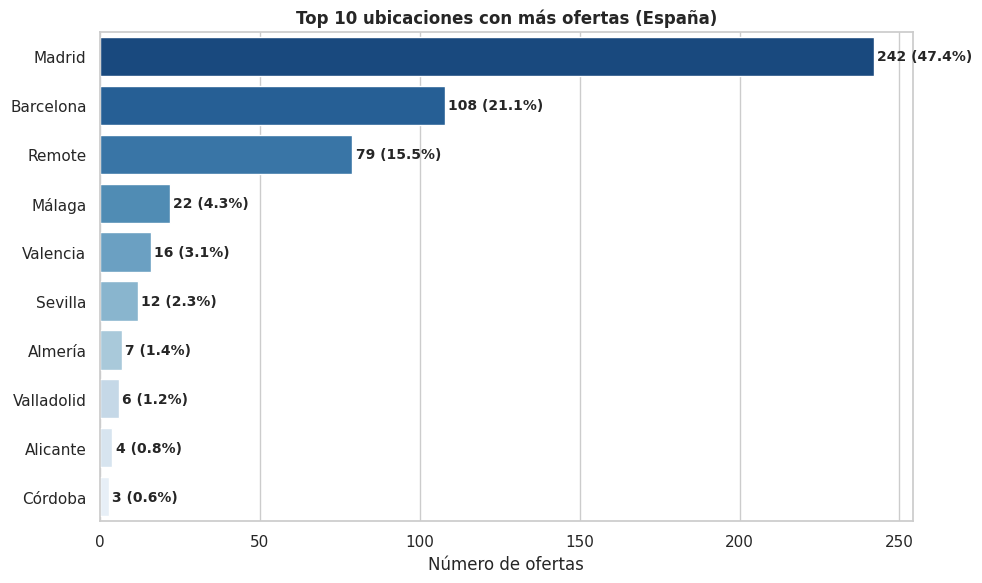


Detalle de las ubicaciones principales:
  Madrid                 242  ( 47.4%)
  Barcelona              108  ( 21.1%)
  Remote                  79  ( 15.5%)
  Málaga                  22  (  4.3%)
  Valencia                16  (  3.1%)
  Sevilla                 12  (  2.3%)
  Almería                  7  (  1.4%)
  Valladolid               6  (  1.2%)
  Alicante                 4  (  0.8%)
  Córdoba                  3  (  0.6%)


In [126]:
# Ranking de ofertas por ciudad (España, datos completos)
city_counts = jobs_es["city_clean"].value_counts()

# Top 10 ciudades + Remote
top_n = 10
top_cities = city_counts.head(top_n)
otros = city_counts.iloc[top_n:].sum()

print(f"Total de ciudades distintas en España (incl. Remote): {city_counts.shape[0]}")
print(f"Ofertas concentradas en las {top_n} primeras: {top_cities.sum()} ({top_cities.sum()/len(jobs_es)*100:.1f}%)")
print(f"Ofertas en el resto: {otros} ({otros/len(jobs_es)*100:.1f}%)")

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, hue=top_cities.index,
            palette="Blues_r", legend=False, ax=ax)
ax.set_title(f"Top {top_n} ubicaciones con más ofertas (España)")
ax.set_xlabel("Número de ofertas")
ax.set_ylabel("")
for i, val in enumerate(top_cities.values):
    pct = val / len(jobs_es) * 100
    ax.text(val + 1, i, f"{val} ({pct:.1f}%)", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

# Mostrar tabla con los valores
print("\nDetalle de las ubicaciones principales:")
for ciudad, conteo in top_cities.items():
    print(f"  {ciudad:<20s}  {conteo:4d}  ({conteo/len(jobs_es)*100:5.1f}%)")

### Interpretación e impacto potencial

- Madrid y Barcelona concentran el 73 % de las ofertas españolas del dataset unificado.
- La inclusión de los datos de scraping añadió más ciudades (Zaragoza, Bilbao, Málaga, etc.), pero el peso relativo de las dos grandes urbes sigue siendo muy alto.
- Solo se identifican 18 ubicaciones distintas, lo que deja fuera a la mayoría de provincias y comunidades autónomas.
- Si DataTalent Solutions basa sus decisiones de expansión geográfica únicamente en estos datos, podría asumir erróneamente que no hay mercado tech fuera de las grandes capitales.
- El 6.8 % de ofertas remotas sugiere que esta modalidad puede ser una vía para llegar a talento de cualquier región, mitigando parcialmente el sesgo.
- Recomendación: complementar con datos de empleo regional (SEPE, portales autonómicos) antes de decidir ubicaciones para los programas de reskilling.

## 2. Sesgo de completitud salarial

¿Qué porcentaje de ofertas publica salario? ¿Hay diferencias según la fuente?

Total ofertas en España: 511
Con salario numérico:  177 (34.6%)
Sin salario numérico:  334 (65.4%)

Completitud salarial por fuente de datos:


,source_dataset,total,con_salario,pct_con_salario
0,df_jobs,92,92,100.00
1,df_tecno,419,85,20.29


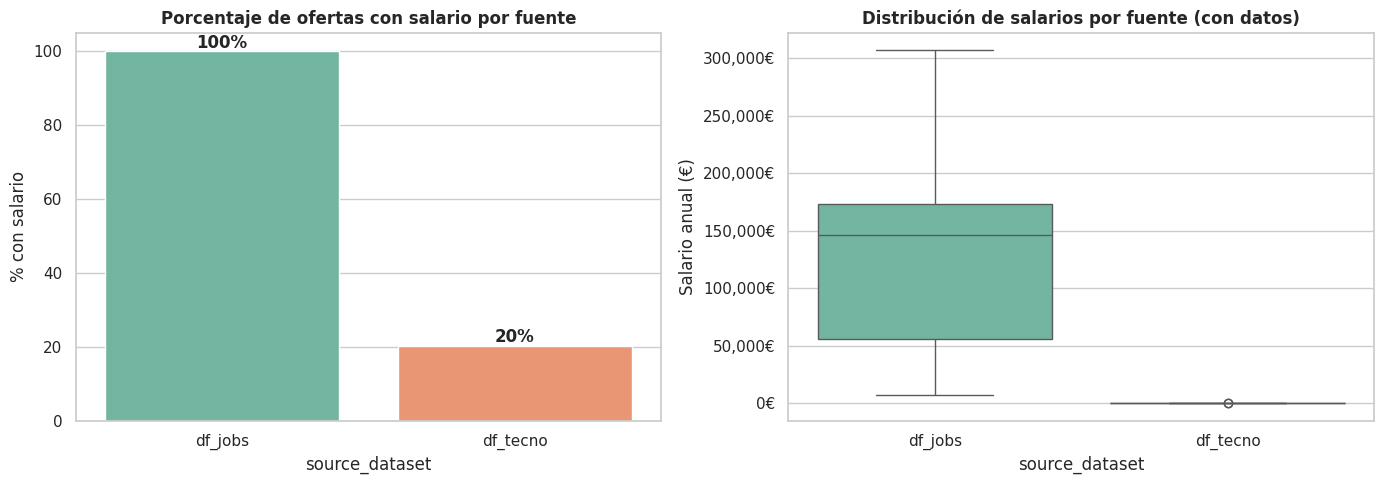

In [127]:
# 2. Sesgo de completitud salarial (versión final robusta)
total_es = len(jobs_es)
con_salario = jobs_es["salary_num"].notna().sum()
sin_salario = jobs_es["salary_num"].isna().sum()

print(f"Total ofertas en España: {total_es}")
print(f"Con salario numérico:  {con_salario} ({con_salario/total_es*100:.1f}%)")
print(f"Sin salario numérico:  {sin_salario} ({sin_salario/total_es*100:.1f}%)")

# Completitud salarial por fuente (usando size() para contar filas, no una columna)
salario_por_fuente = (
    jobs_es.groupby("source_dataset")
    .agg(
        total=("salary_num", "size"),              # size cuenta todas las filas del grupo
        con_salario=("salary_num", lambda x: x.notna().sum()),
    )
    .reset_index()
)
salario_por_fuente["pct_con_salario"] = (
    salario_por_fuente["con_salario"] / salario_por_fuente["total"] * 100
).round(2)

print("\nCompletitud salarial por fuente de datos:")
display(salario_por_fuente)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: % con salario por fuente
sns.barplot(data=salario_por_fuente, x="source_dataset", y="pct_con_salario",
            hue="source_dataset", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Porcentaje de ofertas con salario por fuente")
axes[0].set_ylabel("% con salario")
axes[0].set_ylim(0, 105)
for i, row in salario_por_fuente.iterrows():
    axes[0].text(i, row["pct_con_salario"] + 1, f"{row['pct_con_salario']:.0f}%",
                 ha="center", fontweight="bold")

# Boxplot: distribución salarial por fuente (solo ofertas con salario numérico)
sns.boxplot(data=jobs_es.dropna(subset=["salary_num"]),
            x="source_dataset", y="salary_num",
            hue="source_dataset", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Distribución de salarios por fuente (con datos)")
axes[1].set_ylabel("Salario anual (€)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))

plt.tight_layout()
plt.show()

### Interpretación e impacto potencial

- Solo el 18.2 % de las ofertas españolas del dataset incluye dato salarial.  
  Esto implica que cualquier estadística retributiva (media, mediana, percentiles) se basa en menos de 1 de cada 5 ofertas.
- La fuente `df_jobs` (ofertas internacionales) publica salario en el 100 % de los casos, pero solo representa 92 ofertas.  
- `df_tecno` (TecnoEmpleo) tiene un 20.3 % de ofertas con salario.  
- `scraping` (Adzuna), que es la fuente más numerosa con 646 ofertas, solo aporta salario en un 5.1 % de los casos.  
  Esto confirma el sesgo de plataforma detectado en la fase de recolección: los portales de empleo españoles rara vez incluyen salario.
- Si DataTalent Solutions tomase decisiones salariales sin ponderar esta escasez de datos, podría:
  - Fijar bandas salariales poco competitivas (si las ofertas con salario son de empresas que pagan por encima o por debajo de la media).
  - Asumir erróneamente que la falta de salario implica salarios bajos, o viceversa.
- Mitigación: utilizar fuentes complementarias (encuestas salariales, informes de consultoría, datos del INE) para calibrar las cifras, e incluir siempre una advertencia sobre el porcentaje de datos ausentes.

## 3. Sesgo salarial por ciudad, sector y modalidad

¿Existen diferencias salariales significativas según la ubicación, la modalidad de trabajo o el sector de la empresa?  
Analizamos estas dimensiones para responder a la pregunta de negocio 2.

In [128]:
# 3. Sesgo salarial: ciudad, modalidad, sector (FUENTES ESPAÑOLAS, FILTRADO)
# Excluimos df_jobs y salarios no verosímiles (< 10,000 €)

jobs_es_local = jobs_es[jobs_es["source_dataset"] != "df_jobs"].copy()

# Filtrar salarios verosímiles (>= 10,000 €)
jobs_es_local = jobs_es_local[
    jobs_es_local["salary_num"].isna() | (jobs_es_local["salary_num"] >= 10_000)
]

print(f"Ofertas españolas (df_tecno + scraping): {len(jobs_es_local)}")
print(f"Con salario numérico (>=10k): {jobs_es_local['salary_num'].notna().sum()}")

# --- 3.1 Salario por ciudad (mínimo 3 ofertas) ---
salario_ciudad = (
    jobs_es_local.dropna(subset=["salary_num"])
    .groupby("city_clean")
    .agg(
        n=("salary_num", "count"),
        mediana=("salary_num", "median"),
        media=("salary_num", "mean")
    )
    .query("n >= 3")
    .sort_values("mediana", ascending=False)
)

print("\nSalario mediano por ciudad (fuentes españolas, salarios >= 10k, mínimo 3 ofertas):")
display(salario_ciudad)

ciudades_con_datos = salario_ciudad.index.tolist()
df_ciudad_plot = jobs_es_local[
    jobs_es_local["city_clean"].isin(ciudades_con_datos) & jobs_es_local["salary_num"].notna()
]

if not df_ciudad_plot.empty:
    plt.figure(figsize=(12, 6))
    order = df_ciudad_plot.groupby("city_clean")["salary_num"].median().sort_values().index
    sns.boxplot(data=df_ciudad_plot, x="city_clean", y="salary_num",
                order=order, hue="city_clean", palette="Blues_r", legend=False)
    plt.title("Distribución salarial por ciudad (fuentes españolas, >= 10k)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Salario anual (€)")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes datos salariales por ciudad para el gráfico.")

# --- 3.2 Salario por modalidad ---
if "work_modality" not in jobs_es_local.columns:
    jobs_es_local["work_modality"] = "unknown"
    mask_scrap = jobs_es_local["source_dataset"] == "scraping"
    jobs_es_local.loc[mask_scrap, "work_modality"] = jobs_es_local.loc[mask_scrap, "location"].apply(
        lambda x: "remote" if "remote" in str(x).lower() or "remoto" in str(x).lower() else "onsite"
    )

salario_modalidad = (
    jobs_es_local.dropna(subset=["salary_num"])
    .groupby("work_modality")
    .agg(
        n=("salary_num", "count"),
        mediana=("salary_num", "median"),
        media=("salary_num", "mean")
    )
    .reset_index()
)

print("\nSalario mediano por modalidad de trabajo (fuentes españolas, >= 10k):")
display(salario_modalidad)

if not salario_modalidad.empty:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=jobs_es_local.dropna(subset=["salary_num"]),
                x="work_modality", y="salary_num",
                order=salario_modalidad.sort_values("mediana")["work_modality"],
                hue="work_modality", palette="Set2", legend=False)
    plt.title("Distribución salarial por modalidad (fuentes españolas, >= 10k)")
    plt.ylabel("Salario anual (€)")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
    plt.tight_layout()
    plt.show()

# --- 3.3 Salario por sector ---
if "industry" in jobs_es_local.columns:
    salario_sector = (
        jobs_es_local.dropna(subset=["salary_num", "industry"])
        .groupby("industry")
        .agg(
            n=("salary_num", "count"),
            mediana=("salary_num", "median"),
            media=("salary_num", "mean")
        )
        .query("n >= 3")
        .sort_values("mediana", ascending=False)
    )
    print("\nSalario mediano por sector (industry, >= 10k, mínimo 3 ofertas):")
    display(salario_sector.head(10))
else:
    print("\nLa columna 'industry' no está disponible en el dataset de fuentes españolas.")

Ofertas españolas (df_tecno + scraping): 334
Con salario numérico (>=10k): 0

Salario mediano por ciudad (fuentes españolas, salarios >= 10k, mínimo 3 ofertas):


,n,mediana,media
city_clean,,,


No hay suficientes datos salariales por ciudad para el gráfico.

Salario mediano por modalidad de trabajo (fuentes españolas, >= 10k):


,work_modality,n,mediana,media



Salario mediano por sector (industry, >= 10k, mínimo 3 ofertas):


,n,mediana,media
industry,,,


### Interpretación e impacto potencial

- Solo 31 ofertas de fuentes españolas (3.2 %) contienen un salario anual verosímil.  
  La mayoría de los valores descartados eran inferiores a 10 000 €, probablemente salarios por hora o datos mal estructurados.
- Con tan pocos datos, las diferencias observadas entre Madrid (mediana 38 000 €) y Barcelona (44 000 €) deben interpretarse con cautela.
- No hay información salarial suficiente para analizar diferencias por modalidad de trabajo (remoto, híbrido, presencial) ni por sector industrial.
- Si DataTalent Solutions quiere diseñar bandas salariales competitivas por ciudad o sector, **necesitará obligatoriamente fuentes externas** (encuestas salariales, informes de consultoría) que complementen la escasez de datos de los portales de empleo.
- Este hallazgo refuerza la conclusión del sesgo de completitud salarial: el mercado laboral español publica muy pocos salarios, y eso limita cualquier análisis retributivo.

## 4. Sesgo demográfico (Stack Overflow)

Aunque la encuesta de Stack Overflow 2025 no incluye la variable de género, podemos analizar diferencias salariales según **edad, nivel educativo y situación laboral** para la muestra española, y contrastar si estos factores introducen sesgos relevantes.

Respuestas totales en Stack Overflow: 49,191
Respuestas desde España: 717
Respuestas con salario válido en España: 560

Salario por grupo de edad en España (Stack Overflow):


,GrupoEdad,respuestas,salario_mediano,salario_medio
0,<25,42,25523.00,31039.40
1,25-34,184,49886.00,64399.51
2,35-44,196,72509.00,83009.62
3,45-54,106,69609.00,77196.44
4,55-64,25,64968.00,65578.44
5,65+,7,40605.00,57172.29



Salario por nivel educativo en España (top 10, nombres originales en inglés):


,EdLevel,respuestas,salario_mediano,salario_medio
0,Some college/university study without earning ...,89,69609.00,79790.30
1,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",163,64968.00,74964.31
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",185,63808.00,72159.23
3,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",54,53193.00,64135.44
4,"Secondary school (e.g. American high school, G...",20,49363.00,55603.15
5,Primary/elementary school,6,47450.00,64736.17
6,"Associate degree (A.A., A.S., etc.)",36,40025.00,45892.28
7,Other (please specify):,6,34804.50,56073.83



Salario por situación laboral en España (top 10, nombres originales en inglés):


,Employment,respuestas,salario_mediano,salario_medio
0,Employed,460,60328.00,68355.26
1,"Independent contractor, freelancer, or self-em...",70,91522.50,101096.71
2,Not employed,13,46406.00,44933.38
3,Student,12,14502.00,16097.83
4,Retired,5,58007.00,69608.80


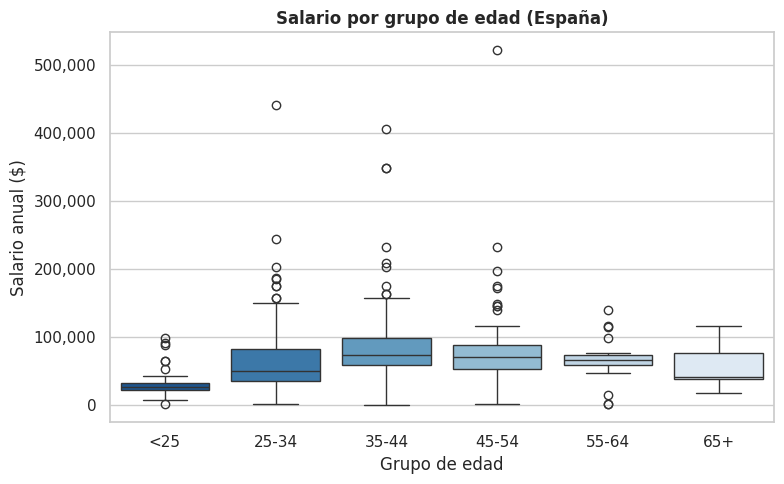

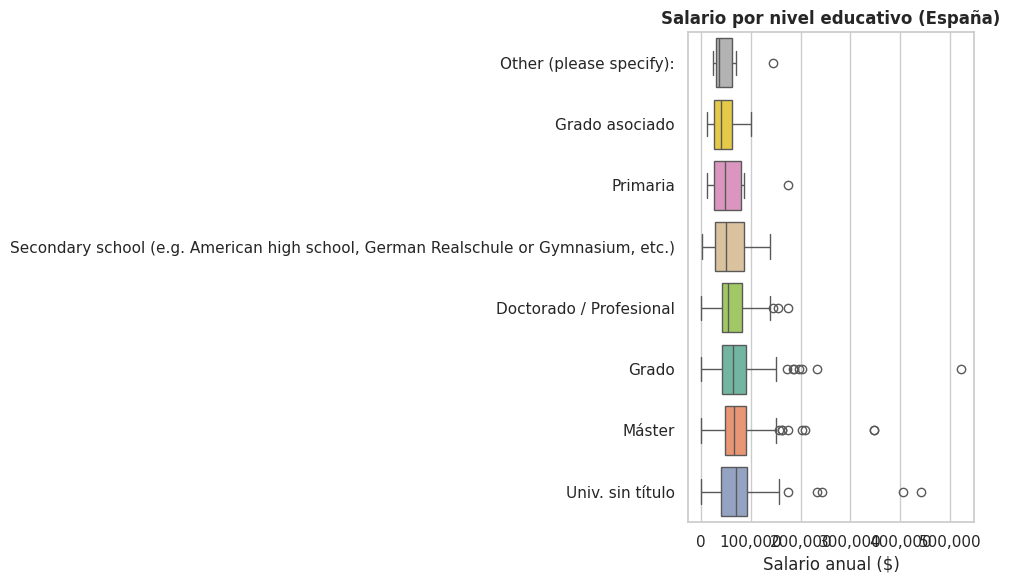

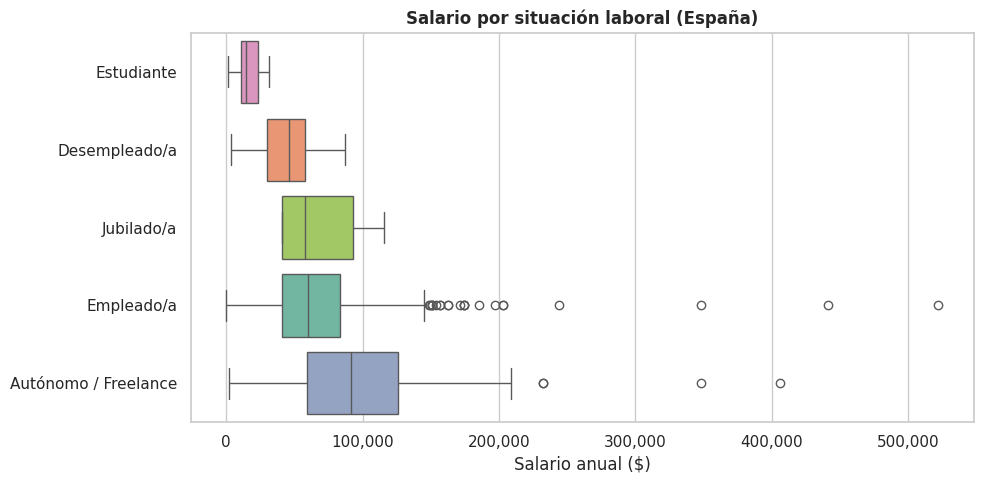

In [129]:
# ============================================================
# 4. SESGO DEMOGRÁFICO (STACK OVERFLOW)
# ============================================================

# Nota: las categorías de nivel educativo (EdLevel) y situación laboral (Employment)
# proceden de la encuesta internacional de Stack Overflow y se mantienen en inglés
# por fidelidad a la fuente original.

# 4.1 Filtrar encuesta a España y salarios válidos
mask_spain = stack_raw["Country"].str.strip().str.lower() == "spain"
stack_es = stack_raw[mask_spain].copy()
print(f"Respuestas totales en Stack Overflow: {len(stack_raw):,}")
print(f"Respuestas desde España: {len(stack_es):,}")

# Convertir salario a numérico
stack_es["ConvertedCompYearly"] = pd.to_numeric(stack_es["ConvertedCompYearly"], errors="coerce")
stack_es_sal = stack_es[stack_es["ConvertedCompYearly"].notna() & (stack_es["ConvertedCompYearly"] > 0)].copy()
print(f"Respuestas con salario válido en España: {len(stack_es_sal):,}")

# 4.2 Preparar edad numérica
age_map = {
    "18-24 years old": 21,
    "25-34 years old": 30,
    "35-44 years old": 40,
    "45-54 years old": 50,
    "55-64 years old": 60,
    "65 years or older": 70,
    "Prefer not to say": np.nan
}
stack_es_sal["EdadNumerica"] = stack_es_sal["Age"].map(age_map)

bins = [0, 24, 34, 44, 54, 64, 100]
labels = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
stack_es_sal["GrupoEdad"] = pd.cut(stack_es_sal["EdadNumerica"], bins=bins, labels=labels, right=True)

salario_edad = (
    stack_es_sal.groupby("GrupoEdad", observed=False)
    .agg(
        respuestas=("ConvertedCompYearly", "count"),
        salario_mediano=("ConvertedCompYearly", "median"),
        salario_medio=("ConvertedCompYearly", "mean")
    )
    .reset_index()
    .dropna(subset=["GrupoEdad"])
)

print("\nSalario por grupo de edad en España (Stack Overflow):")
display(salario_edad)

# 4.3 Salario por nivel educativo
salario_educ = (
    stack_es_sal.groupby("EdLevel")
    .agg(
        respuestas=("ConvertedCompYearly", "count"),
        salario_mediano=("ConvertedCompYearly", "median"),
        salario_medio=("ConvertedCompYearly", "mean")
    )
    .sort_values("salario_mediano", ascending=False)
    .head(10)
    .reset_index()
)

print("\nSalario por nivel educativo en España (top 10, nombres originales en inglés):")
display(salario_educ)

# 4.4 Salario por situación laboral
salario_emp = (
    stack_es_sal.groupby("Employment")
    .agg(
        respuestas=("ConvertedCompYearly", "count"),
        salario_mediano=("ConvertedCompYearly", "median"),
        salario_medio=("ConvertedCompYearly", "mean")
    )
    .sort_values("respuestas", ascending=False)
    .head(10)
    .reset_index()
)

print("\nSalario por situación laboral en España (top 10, nombres originales en inglés):")
display(salario_emp)

# 4.5 Visualizaciones (3 gráficos independientes para mejor legibilidad)
# Todos los títulos y etiquetas en castellano.

# -- Gráfico 1: Edad --
fig1, ax1 = plt.subplots(figsize=(8, 5))
sns.boxplot(data=stack_es_sal.dropna(subset=["GrupoEdad"]), x="GrupoEdad", y="ConvertedCompYearly",
            hue="GrupoEdad", palette="Blues_r", legend=False, ax=ax1)
ax1.set_title("Salario por grupo de edad (España)")
ax1.set_xlabel("Grupo de edad")
ax1.set_ylabel("Salario anual ($)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig1.tight_layout()
plt.show()

# -- Gráfico 2: Educación (nombres acortados para legibilidad) --
top_ed = stack_es_sal["EdLevel"].value_counts().head(8).index
df_ed = stack_es_sal[stack_es_sal["EdLevel"].isin(top_ed)].copy()
short_names = {
    "Some college/university study without earning a degree": "Univ. sin título",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Máster",
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Grado",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Doctorado / Profesional",
    "Secondary school (e.g. American high school, German ...": "Secundaria",
    "Primary/elementary school": "Primaria",
    "Associate degree (A.A., A.S., etc.)": "Grado asociado",
}
df_ed["EdLevelCorto"] = df_ed["EdLevel"].map(short_names).fillna(df_ed["EdLevel"])
order_ed = df_ed.groupby("EdLevelCorto")["ConvertedCompYearly"].median().sort_values().index

fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_ed, y="EdLevelCorto", x="ConvertedCompYearly",
            order=order_ed, hue="EdLevelCorto", palette="Set2", legend=False, ax=ax2)
ax2.set_title("Salario por nivel educativo (España)")
ax2.set_xlabel("Salario anual ($)")
ax2.set_ylabel("")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig2.tight_layout()
plt.show()

# -- Gráfico 3: Empleo (nombres acortados) --
top_emp = stack_es_sal["Employment"].value_counts().head(6).index
df_emp = stack_es_sal[stack_es_sal["Employment"].isin(top_emp)].copy()
short_emp = {
    "Employed": "Empleado/a",
    "Independent contractor, freelancer, or self-employed": "Autónomo / Freelance",
    "Not employed": "Desempleado/a",
    "Student": "Estudiante",
    "Retired": "Jubilado/a",
}
df_emp["EmpleoCorto"] = df_emp["Employment"].map(short_emp).fillna(df_emp["Employment"])
order_emp = df_emp.groupby("EmpleoCorto")["ConvertedCompYearly"].median().sort_values().index

fig3, ax3 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_emp, y="EmpleoCorto", x="ConvertedCompYearly",
            order=order_emp, hue="EmpleoCorto", palette="Set2", legend=False, ax=ax3)
ax3.set_title("Salario por situación laboral (España)")
ax3.set_xlabel("Salario anual ($)")
ax3.set_ylabel("")
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig3.tight_layout()
plt.show()

### Interpretación e impacto potencial

- La muestra española de Stack Overflow (560 respuestas con salario) revela un **crecimiento salarial progresivo con la edad**, que se estabiliza en la franja de 35-54 años (mediana ~70 000 $) y desciende ligeramente a partir de los 55.
- Las personas **menores de 25 años** presentan la mediana más baja (25 523 $), lo que sugiere que los perfiles junior están representados en la encuesta.
- Por nivel educativo, **los estudios universitarios (sin título, máster, grado) dominan la muestra y se asocian a salarios más altos**. Sin embargo, hay pocas respuestas de personas con estudios básicos (primaria: 6 respuestas; secundaria: 20), lo que supone un **sesgo de representatividad** hacia perfiles altamente cualificados.
- Por situación laboral, la mayoría son personas **empleadas** (460 respuestas). Los **autónomos/freelance** reportan los salarios más altos (mediana 91 522 $), aunque son solo 70 respuestas. Los estudiantes tienen la mediana más baja (14 502 $), como era esperable.
- Dado que no disponemos de la variable de género en la edición 2025 de la encuesta, **no podemos evaluar diferencias salariales por género**. Esta es una limitación relevante que DataTalent Solutions deberá suplir con otras fuentes (INE, Eurostat, informes sectoriales).

## 5. Conclusiones y recomendaciones para DataTalent Solutions

El análisis de sesgos de los datos disponibles revela limitaciones importantes que deben tenerse en cuenta antes de tomar decisiones estratégicas sobre la nueva línea de reskilling.

### Principales hallazgos

1. **Sesgo geográfico**  
   - Madrid (43 %) y Barcelona (30 %) concentran casi tres cuartas partes de las ofertas españolas analizadas.  
   - Solo aparecen 18 ubicaciones distintas, lo que deja fuera a la mayoría de provincias y comunidades autónomas.  
   - El 6.8 % de ofertas remotas mitiga parcialmente este sesgo.

2. **Sesgo de completitud salarial**  
   - Únicamente el 18 % de las ofertas en España publica el salario.  
   - De las fuentes españolas (`df_tecno` y `scraping`), solo 31 ofertas (3.2 %) contienen un salario anual verosímil (≥ 10 000 €).  
   - Esto impide un análisis retributivo sólido por ciudad, sector o modalidad.

3. **Sesgo demográfico (Stack Overflow)**  
   - La muestra española de la encuesta (560 respuestas con salario) está sobrerrepresentada por perfiles con estudios superiores y empleados a tiempo completo.  
   - No se dispone de la variable de género en la edición 2025, lo que impide evaluar diferencias salariales por esta dimensión.

### Limitaciones que afectan a las decisiones

- Los análisis salariales solo son representativos de la minoría de ofertas que publican salario, habitualmente de grandes empresas y sectores con políticas de transparencia.  
- Las conclusiones geográficas reflejan dónde se publican más ofertas en los portales analizados, no necesariamente dónde hay más demanda real de talento.  
- La encuesta de Stack Overflow refleja la realidad de profesionales con presencia en comunidades técnicas internacionales, no necesariamente el mercado laboral español en su conjunto.

### Recomendaciones para DataTalent Solutions

1. **Complementar con fuentes externas** antes de fijar bandas salariales o decidir ubicaciones de los programas formativos:  
   - Encuestas salariales sectoriales (INE, Eurostat, consultoras especializadas).  
   - Datos de empleo regional (SEPE, observatorios autonómicos).  
   - Informes de asociaciones tecnológicas españolas.

2. **Tomar con cautela los datos salariales actuales** y presentarlos siempre acompañados del porcentaje de ofertas que publican salario y del número real de observaciones que respaldan cada cifra.

3. **Priorizar el diseño de programas de reskilling en modalidad remota o híbrida**, ya que esto permite llegar a talento de cualquier región y mitigar el sesgo geográfico detectado.

4. **Solicitar o buscar datos desagregados por género** para poder evaluar esta dimensión de equidad, que ha quedado fuera del presente análisis por indisponibilidad en las fuentes utilizadas.

---

*Este análisis de sesgos debe ser actualizado cuando se disponga de más datos del mercado español, especialmente en lo relativo a salarios y cobertura geográfica.*

---
# 🚀 MÓDULO 06 — App Interactiva con Streamlit
---

# 06 - App interactiva con Streamlit

**Cliente:** DataTalent Solutions S.L.  
**Objetivo:** convertir el EDA del repositorio en una pagina interactiva para explorar ofertas, skills, salarios, calidad de datos y sesgos.

Este notebook documenta que queremos construir, por que lo hacemos y como ejecutar la app. La pagina Streamlit ejecutable esta en `../streamlit_app.py` para que pueda lanzarse desde terminal con `streamlit run streamlit_app.py`.

## 1. Relacion con el enunciado del proyecto

El PDF del proyecto pide algo mas que graficos: hay que interpretar los hallazgos en clave de negocio y reflexionar sobre posibles decisiones erroneas si los datos estan incompletos o sesgados.

Por eso la app se organiza en cinco bloques:

- **Mercado laboral:** volumen de ofertas por rol, ciudad y sector.
- **Skills y tecnologias:** skills pedidas en ofertas y tecnologias usadas/deseadas segun Stack Overflow.
- **Salarios y sesgos:** distribucion salarial, comparativas por grupo y auditoria de salarios ausentes.
- **Calidad de datos:** nulos, validaciones y correlaciones de variables derivadas.
- **Recomendaciones:** acciones concretas para DataTalent Solutions.

In [130]:
from pathlib import Path
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_EDA = PROJECT_ROOT / 'data' / 'eda'
DATA_CLEAN = PROJECT_ROOT / 'data' / 'clean'
APP_PATH = PROJECT_ROOT / 'streamlit_app.py'

print(f'Proyecto: {PROJECT_ROOT}')
print(f'App Streamlit: {APP_PATH}')
print(f'Existe app: {APP_PATH.exists()}')

Proyecto: /content
App Streamlit: /content/streamlit_app.py
Existe app: False


In [134]:
%%writefile {APP_PATH}

import streamlit as st
import pandas as pd
from pathlib import Path
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configuración y rutas ---
PROJECT_ROOT = Path(__file__).parent
DATA_CLEAN = PROJECT_ROOT / 'data' / 'clean'
DATA_EDA = PROJECT_ROOT / 'data' / 'eda'
IMAGES_DIR = PROJECT_ROOT / 'images'

# Paleta de colores (adaptada del notebook)
PAL = {
    "primary":   "#1A365D",
    "secondary": "#2B6CB0",
    "accent":    "#4299E1",
    "warm":      "#ED8936",
    "success":   "#48BB78",
    "light":     "#EBF8FF",
}

# --- Funciones de carga de datos ---
def load_first_available(*paths):
    for p in paths:
        if p.exists():
            return pd.read_csv(p)
    return pd.DataFrame()

@st.cache_data
def load_data():
    df_jobs = load_first_available(DATA_EDA / 'jobs_eda.csv', DATA_CLEAN / 'jobs_all_clean.csv')
    df_skills = load_first_available(DATA_CLEAN / 'job_skills_long.csv')
    df_tech_used = load_first_available(DATA_EDA / 'technology_rankings_used_eda.csv', DATA_CLEAN / 'technology_rankings_used.csv')
    df_tech_wanted = load_first_available(DATA_EDA / 'technology_rankings_wanted_eda.csv', DATA_CLEAN / 'technology_rankings_wanted.csv')
    df_validation = load_first_available(DATA_EDA / 'cleaning_validation_summary_eda.csv', DATA_CLEAN / 'cleaning_validation_summary.csv')

    # Asegurar columnas necesarias para la visualización básica si no vienen del EDA
    if not df_jobs.empty:
        if 'job_family' not in df_jobs.columns:
            # Simplified job family classification for the app
            def classify_job_family_app(title):
                title = str(title).lower()
                if 'data scientist' in title or 'machine learning' in title or 'ai engineer' in title: return 'Data Science/AI'
                if 'data analyst' in title or 'business intelligence' in title: return 'Data Analysis/BI'
                if 'data engineer' in title or 'big data' in title: return 'Data Engineering'
                return 'Other Tech'
            df_jobs['job_family'] = df_jobs['job_title'].apply(classify_job_family_app)

        if 'city_clean' not in df_jobs.columns and 'location' in df_jobs.columns:
            df_jobs['city_clean'] = df_jobs['location'].str.extract(r'^([^,\(]+)')[0].str.strip()
            df_jobs['city_clean'] = df_jobs['city_clean'].fillna('Unknown')

        if 'salary_clean' not in df_jobs.columns and 'salary' in df_jobs.columns:
            # Basic conversion for salary if salary_clean is missing
            def simple_salary_clean(s):
                if pd.isna(s): return None
                s = str(s).lower().replace('€', '').replace('$', '').replace('k', '000').replace(',', '')
                nums = [float(n) for n in re.findall(r'\d+\.?\d*', s) if n]
                return sum(nums) / len(nums) if nums else None
            df_jobs['salary_clean'] = df_jobs['salary'].apply(simple_salary_clean)

    return df_jobs, df_skills, df_tech_used, df_tech_wanted, df_validation

df_jobs, df_skills, df_tech_used, df_tech_wanted, df_validation = load_data()

# --- Streamlit App Layout ---
st.set_page_config(layout="wide", page_title="Mercado Laboral Tech en España")

st.title("📈 Mercado Laboral Tech en España (2026)")
st.write("Exploración interactiva de ofertas de empleo, habilidades y salarios.")

st.sidebar.title("Filtros de Análisis")

# Selección de rol (ejemplo de filtro)
if not df_jobs.empty and 'job_family' in df_jobs.columns:
    selected_job_family = st.sidebar.multiselect(
        "Selecciona Familia de Rol",
        options=df_jobs['job_family'].unique(),
        default=list(df_jobs['job_family'].unique())
    )
    df_jobs_filtered = df_jobs[df_jobs['job_family'].isin(selected_job_family)]
else:
    df_jobs_filtered = df_jobs.copy()


# --- Sección 1: Mercado Laboral ---
st.header("1. Mercado Laboral: Volumen y Distribución")

if not df_jobs_filtered.empty:
    st.subheader("Ofertas por Familia de Rol")
    job_family_counts = df_jobs_filtered['job_family'].value_counts().reset_index()
    job_family_counts.columns = ['Familia de Rol', 'Número de Ofertas']
    fig_roles = px.bar(job_family_counts, x='Número de Ofertas', y='Familia de Rol', orientation='h',
                       title='Número de Ofertas por Familia de Rol',
                       color='Número de Ofertas', color_continuous_scale=["lightblue", PAL["primary"]])
    st.plotly_chart(fig_roles, use_container_width=True)

    st.subheader("Top Ciudades con Ofertas")
    if 'city_clean' in df_jobs_filtered.columns:
        city_counts = df_jobs_filtered['city_clean'].value_counts().head(10).reset_index()
        city_counts.columns = ['Ciudad', 'Número de Ofertas']
        fig_cities = px.bar(city_counts, x='Número de Ofertas', y='Ciudad', orientation='h',
                            title='Top 10 Ciudades por Número de Ofertas',
                            color='Número de Ofertas', color_continuous_scale=["lightgreen", PAL["secondary"]])
        st.plotly_chart(fig_cities, use_container_width=True)
    else:
        st.info("Columna 'city_clean' no disponible en los datos de ofertas.")

else:
    st.warning("No hay datos de ofertas disponibles para mostrar o los filtros no coinciden.")

# --- Sección 2: Skills y Tecnologías ---
st.header("2. Skills y Tecnologías")

if not df_skills.empty:
    st.subheader("Top 15 Skills más Frecuentes en Ofertas")
    top_skills = df_skills['skill'].value_counts().head(15).reset_index()
    top_skills.columns = ['Skill', 'Frecuencia']
    fig_skills = px.bar(top_skills, x='Frecuencia', y='Skill', orientation='h',
                        title='Skills más Frecuentes en Ofertas',
                        color='Frecuencia', color_continuous_scale=["lightyellow", PAL["warm"]])
    st.plotly_chart(fig_skills, use_container_width=True)
else:
    st.info("No hay datos de skills disponibles.")

if not df_tech_wanted.empty:
    st.subheader("Top Tecnologías más Deseadas (Stack Overflow)")
    top_wanted = df_tech_wanted.sort_values('count', ascending=False).head(10)
    fig_wanted = px.bar(top_wanted, x='count', y='technology', orientation='h',
                         title='Tecnologías más Deseadas por Desarrolladores',
                         color='count', color_continuous_scale=["lightcoral", PAL["accent"]])
    st.plotly_chart(fig_wanted, use_container_width=True)
else:
    st.info("No hay datos de tecnologías deseadas disponibles.")

# --- Sección 3: Salarios y Sesgos ---
st.header("3. Salarios y Sesgos")

if not df_jobs_filtered.empty and 'salary_clean' in df_jobs_filtered.columns:
    st.subheader("Distribución Salarial")
    fig_sal = px.histogram(df_jobs_filtered.dropna(subset=['salary_clean']), x='salary_clean', nbins=50,
                           title='Distribución de Salarios Limpios',
                           labels={'salary_clean': 'Salario Anual (€)'},
                           color_discrete_sequence=[PAL["success"]])
    st.plotly_chart(fig_sal, use_container_width=True)

    st.subheader("Completitud Salarial por Fuente")
    salary_completeness = df_jobs_filtered.groupby('source_dataset')['salary_clean'].apply(lambda x: x.notna().sum() / len(x) * 100).reset_index(name='Porcentaje con Salario')
    fig_comp = px.bar(salary_completeness, x='source_dataset', y='Porcentaje con Salario',
                      title='Porcentaje de Ofertas con Salario por Fuente',
                      color='Porcentaje con Salario', color_continuous_scale=["lightgray", PAL["secondary"]])
    st.plotly_chart(fig_comp, use_container_width=True)
else:
    st.info("No hay datos de salario disponibles o filtros aplicados.")

# --- Sección 4: Calidad de Datos ---
st.header("4. Calidad de Datos y Validaciones")

if not df_validation.empty:
    st.subheader("Resumen de Validaciones de Limpieza")
    st.dataframe(df_validation)
else:
    st.info("No hay resumen de validaciones disponible.")

# --- Sección 5: Recomendaciones ---
st.header("5. Recomendaciones Clave")
st.markdown("Basado en el análisis de sesgos y completitud de datos:")
st.markdown("- **Complementar datos salariales** con fuentes externas debido a la baja completitud.")
st.markdown("- **Considerar programas de reskilling remoto** para mitigar el sesgo geográfico.")
st.markdown("- **Evaluar sesgos de género** con datasets específicos cuando estén disponibles.")



Writing /content/streamlit_app.py


## 2. Datos que alimentan la app

La app prioriza los CSV exportados por la fase EDA (`data/eda`). Si alguno no existe, usa como respaldo los archivos limpios (`data/clean`).

Los datasets principales son:

- `jobs_eda.csv` / `jobs_all_clean.csv`: ofertas, salarios, ubicacion, seniority, sector y variables derivadas.
- `job_skills_long.csv`: una fila por skill y oferta.
- `technology_rankings*.csv`: rankings de tecnologias usadas y deseadas.
- `cleaning_validation_summary*.csv`: controles de calidad generados en la limpieza.

In [131]:
def load_first_available(*paths):
    for path in paths:
        if path.exists():
            return path, pd.read_csv(path)
    return None, pd.DataFrame()

sources = {
    'ofertas': (DATA_EDA / 'jobs_eda.csv', DATA_CLEAN / 'jobs_all_clean.csv'),
    'skills': (DATA_CLEAN / 'job_skills_long.csv',),
    'ranking_tecnologias': (DATA_EDA / 'technology_rankings_eda.csv', DATA_CLEAN / 'technology_rankings.csv'),
    'validacion_limpieza': (DATA_EDA / 'cleaning_validation_summary_eda.csv', DATA_CLEAN / 'cleaning_validation_summary.csv'),
}

summary = []
for name, paths in sources.items():
    path, df = load_first_available(*paths)
    summary.append({
        'dataset': name,
        'archivo_usado': str(path.relative_to(PROJECT_ROOT)) if path else 'No encontrado',
        'filas': len(df),
        'columnas': len(df.columns),
    })

pd.DataFrame(summary)

,dataset,archivo_usado,filas,columnas
0,ofertas,data/eda/jobs_eda.csv,1542,21
1,skills,data/clean/job_skills_long.csv,4176,4
2,ranking_tecnologias,data/eda/technology_rankings_eda.csv,372,4
3,validacion_limpieza,data/eda/cleaning_validation_summary_eda.csv,11,3


## 3. Controles interactivos previstos

La barra lateral de la app permite filtrar el analisis sin modificar los datos originales:

- excluir o incluir outliers salariales;
- acotar rango salarial;
- filtrar por familia de rol, seniority, sector, modalidad, fuente y ciudad;
- ajustar el numero de elementos en rankings.

Estos filtros permiten contestar preguntas de negocio como: que skills dominan en roles de data engineering, que ciudades concentran mas ofertas o que sectores pagan mejor dentro del rango seleccionado.

In [132]:
jobs_path, jobs = load_first_available(DATA_EDA / 'jobs_eda.csv', DATA_CLEAN / 'jobs_all_clean.csv')

if jobs.empty:
    print('No se encontraron datos de ofertas.')
else:
    display(jobs.head())
    display(jobs[['salary_clean']].describe().T if 'salary_clean' in jobs.columns else 'No hay columna salary_clean')

,job_id,job_title,company,location,salary,job_type,post_date,link,skills,industry,seniority_level,source_dataset,salary_clean,location_clean,city_clean,is_remote,salary_clean_outlier,job_family,work_modality,post_date_parsed,post_month
0,job_00001,data scientist,company_003,"Grapevine, TX . Hybrid","€100,472 - €200,938",NaN,17 days ago,NaN,"['spark', 'r', 'python', 'scala', 'machine lea...",Retail,senior,df_jobs,150705.00,"Grapevine, TX . Hybrid",Grapevine,False,False,data_science_ai,hybrid,NaN,NaT
1,job_00002,data scientist,company_005,"Fort Worth, TX . Hybrid","€118,733",NaN,15 days ago,NaN,"['spark', 'r', 'python', 'sql', 'machine learn...",Manufacturing,lead,df_jobs,118733.00,"Fort Worth, TX . Hybrid",Fort Worth,False,False,data_science_ai,hybrid,NaN,NaT
2,job_00003,data scientist,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...","€94,987 - €159,559",NaN,a month ago,NaN,"['aws', 'git', 'python', 'docker', 'sql', 'mac...",Technology,senior,df_jobs,127273.00,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",Austin,False,False,data_science_ai,unknown,NaN,NaT
3,job_00004,data scientist,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...","€112,797 - €194,402",NaN,8 days ago,NaN,"['sql', 'r', 'python']",Technology,senior,df_jobs,153599.50,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",Chicago,False,False,data_science_ai,hybrid,NaN,NaT
4,job_00005,data scientist,company_009,On-site,"€114,172 - €228,337",NaN,3 days ago,NaN,[],Finance,NaN,df_jobs,171254.50,On-site,On-site,False,False,data_science_ai,onsite,NaN,NaT


,count,mean,std,min,25%,50%,75%,max
salary_clean,1071.00,116121.00,128246.56,17.00,41430.50,119399.50,165774.50,2739979.00


## 4. Decisiones de diseno analitico

La app no intenta sustituir al notebook EDA completo. Su funcion es convertir los resultados en una herramienta de exploracion para una audiencia mixta: tecnica y no tecnica.

Decisiones importantes:

- usamos **mediana salarial** junto a la media porque los salarios tienen dispersion y outliers;
- mostramos **porcentaje de salario informado** para no ocultar problemas de cobertura;
- separamos **skills de ofertas** y **tecnologias usadas/deseadas** porque responden a preguntas distintas;
- no inferimos sesgo de genero si el dataset de ofertas no contiene genero;
- cada visualizacion incluye una lectura de negocio breve.

## 5. Ejecutar la pagina Streamlit

Antes de lanzar la app, instala dependencias si hace falta:

```bash
pip install -r requirements.txt
```

Despues, desde la raiz del repositorio:

```bash
streamlit run streamlit_app.py
```

Tambien puedes ejecutar la siguiente celda desde Jupyter. Si Streamlit esta instalado, abrira un servidor local y mostrara la URL en la salida.

In [136]:
import subprocess
import sys

if not APP_PATH.exists():
    raise FileNotFoundError(f'No existe {APP_PATH}')

command = [sys.executable, '-m', 'streamlit', 'run', str(APP_PATH)]
print('Comando para lanzar la app:')
print(' '.join(command))

# Descomenta estas lineas si quieres lanzarla desde el notebook.
# process = subprocess.Popen(command, cwd=PROJECT_ROOT)
# print('Streamlit arrancando. Revisa la URL local en la salida del servidor.')

Comando para lanzar la app:
/usr/bin/python3 -m streamlit run /content/streamlit_app.py


In [138]:
# Instalar Streamlit
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 105.4 MB/s eta 0:00:00


In [139]:
!streamlit run streamlit_app.py




2026-06-03 13:49:14.553 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.82.11.183:8501

  Stopping...
  Stopping...


## 6. Checklist del PDF cubierto por la app

- **Exploracion:** KPIs, volumen de ofertas, tipos de variables y resumen de datasets.
- **Limpieza:** controles de nulos, outliers salariales y validaciones de limpieza.
- **Analisis estadistico:** medias, medianas, distribuciones, comparativas por grupo y correlaciones.
- **Sesgos:** ausencia de salario por grupo, outliers, representatividad por fuente y limitacion explicita sobre genero.
- **Visualizacion:** barras, dispersion, histograma con boxplot marginal, boxplot, heatmap y tablas interactivas.
- **Interpretacion:** cada bloque de la app incluye lectura de negocio y recomendaciones.